In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from io import StringIO

BASE_DIR = Path("..")
EMAGE_DIR = BASE_DIR / "data" / "raw" / "emage"

CSEM_FILE = EMAGE_DIR / "EMAGE_CSEM_Line5_s5_m3.data"

frequency_map = {
    1: 0.25,
    2: 0.75,
    3: 1.75
}

In [2]:
with open(CSEM_FILE, "r", errors="ignore") as f:
    lines = f.readlines()

data_start = 1113

data_lines = [
    line.strip()
    for line in lines[data_start:]
    if line.strip() and not line.strip().startswith("!")
]

print("Data records:", len(data_lines))

Data records: 23458


In [3]:
df_csem = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep=r"\s+",
    header=None,
    names=[
        "type",
        "freq_id",
        "tx_id",
        "rx_id",
        "data",
        "stderr"
    ]
)

df_csem["frequency_hz"] = df_csem["freq_id"].map(frequency_map)

print(df_csem.head())
print(df_csem.shape)

   type  freq_id  tx_id  rx_id      data    stderr  frequency_hz
0    24        1      1      1  113.1040  1.718940          0.25
1    28        1      1      1  -11.5320  0.013029          0.25
2    24        1      1      2  112.2660  1.718940          0.25
3    28        1      1      2  -11.5594  0.013029          0.25
4    24        1      1      3  112.1700  1.718940          0.25
(23458, 7)


In [4]:
df_wide = df_csem.pivot_table(
    index=["freq_id", "tx_id", "rx_id"],
    columns="type",
    values=["data", "stderr"],
    aggfunc="first"
).reset_index()

In [5]:
df_wide.columns = [
    "_".join(str(x) for x in col if str(x) != "")
    if isinstance(col, tuple)
    else str(col)
    for col in df_wide.columns
]

print(df_wide.head())
print(df_wide.columns)

   freq_id  tx_id  rx_id  data_24  data_28  stderr_24  stderr_28
0        1      1      1  113.104 -11.5320    1.71894   0.013029
1        1      1      2  112.266 -11.5594    1.71894   0.013029
2        1      1      3  112.170 -11.5761    1.71894   0.013029
3        1      1      4  112.047 -11.6111    1.71894   0.013029
4        1      1      5  110.307 -11.6323    1.71894   0.013029
Index(['freq_id', 'tx_id', 'rx_id', 'data_24', 'data_28', 'stderr_24',
       'stderr_28'],
      dtype='str')


In [6]:
df_wide["frequency_hz"] = df_wide["freq_id"].map(frequency_map)

In [7]:
print("Rows:", len(df_wide))

print("\nMissing values:")
print(df_wide.isna().sum())

print("\nFrequency distribution:")
print(df_wide["frequency_hz"].value_counts().sort_index())

Rows: 11729

Missing values:
freq_id         0
tx_id           0
rx_id           0
data_24         0
data_28         0
stderr_24       0
stderr_28       0
frequency_hz    0
dtype: int64

Frequency distribution:
frequency_hz
0.25    4026
0.75    4399
1.75    3304
Name: count, dtype: int64


In [8]:
print("\nTX count:", df_wide["tx_id"].nunique())
print("RX count:", df_wide["rx_id"].nunique())


TX count: 30
RX count: 1070


In [9]:
print(
    df_wide[
        ["frequency_hz", "tx_id", "rx_id", "data_24", "data_28",
         "stderr_24", "stderr_28"]
    ].head(10)
)

   frequency_hz  tx_id  rx_id  data_24  data_28  stderr_24  stderr_28
0          0.25      1      1  113.104 -11.5320    1.71894   0.013029
1          0.25      1      2  112.266 -11.5594    1.71894   0.013029
2          0.25      1      3  112.170 -11.5761    1.71894   0.013029
3          0.25      1      4  112.047 -11.6111    1.71894   0.013029
4          0.25      1      5  110.307 -11.6323    1.71894   0.013029
5          0.25      1      6  107.280 -11.6540    1.71894   0.013029
6          0.25      1      7  109.104 -11.6604    1.71894   0.013029
7          0.25      1      8  106.602 -11.7015    1.71894   0.013029
8          0.25      1      9  106.181 -11.6939    1.71894   0.013029
9          0.25      1     10  106.484 -11.7367    1.71894   0.013029


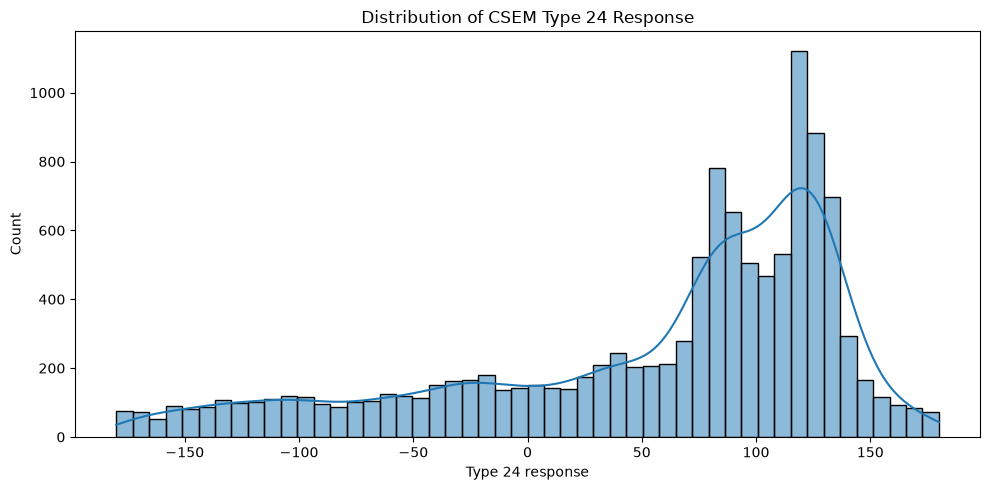

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_wide["data_24"],
    bins=50,
    kde=True
)

plt.xlabel("Type 24 response")
plt.ylabel("Count")
plt.title("Distribution of CSEM Type 24 Response")
plt.tight_layout()
plt.show()

In [11]:
plt.savefig(
    "../results/figures/type24_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

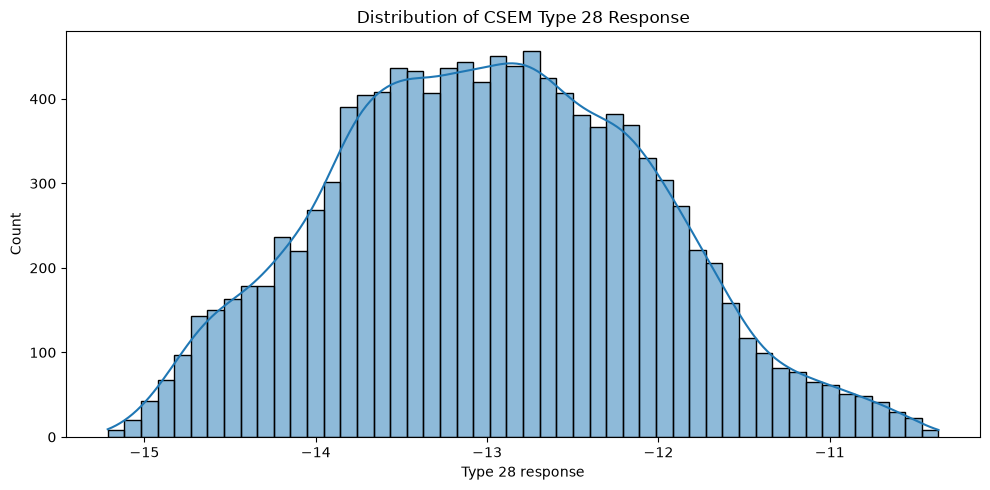

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_wide["data_28"],
    bins=50,
    kde=True
)

plt.xlabel("Type 28 response")
plt.ylabel("Count")
plt.title("Distribution of CSEM Type 28 Response")
plt.tight_layout()
plt.show()

In [13]:
plt.savefig(
    "../results/figures/type28_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

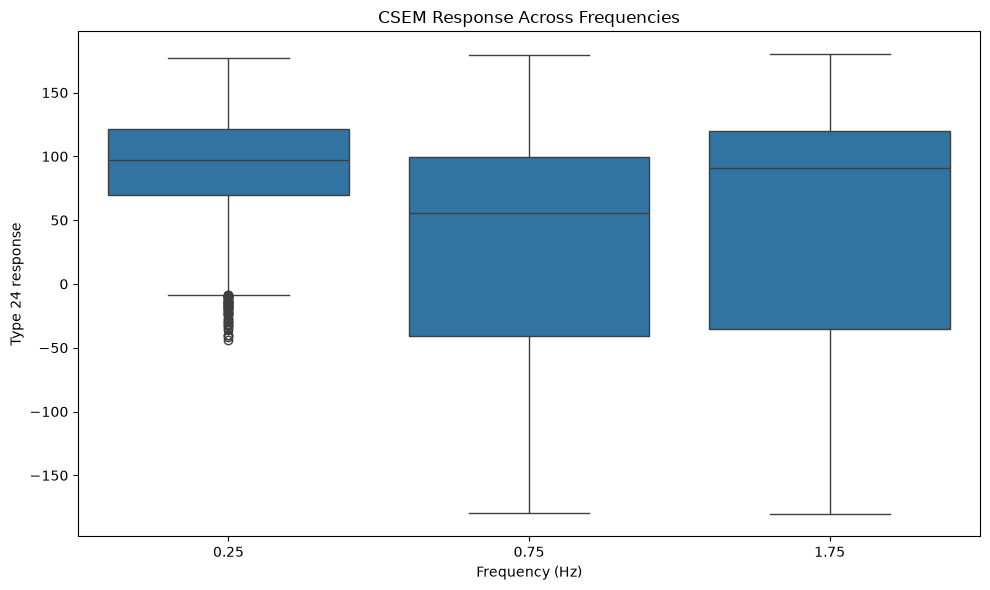

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_wide,
    x="frequency_hz",
    y="data_24"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Type 24 response")
plt.title("CSEM Response Across Frequencies")
plt.tight_layout()
plt.show()

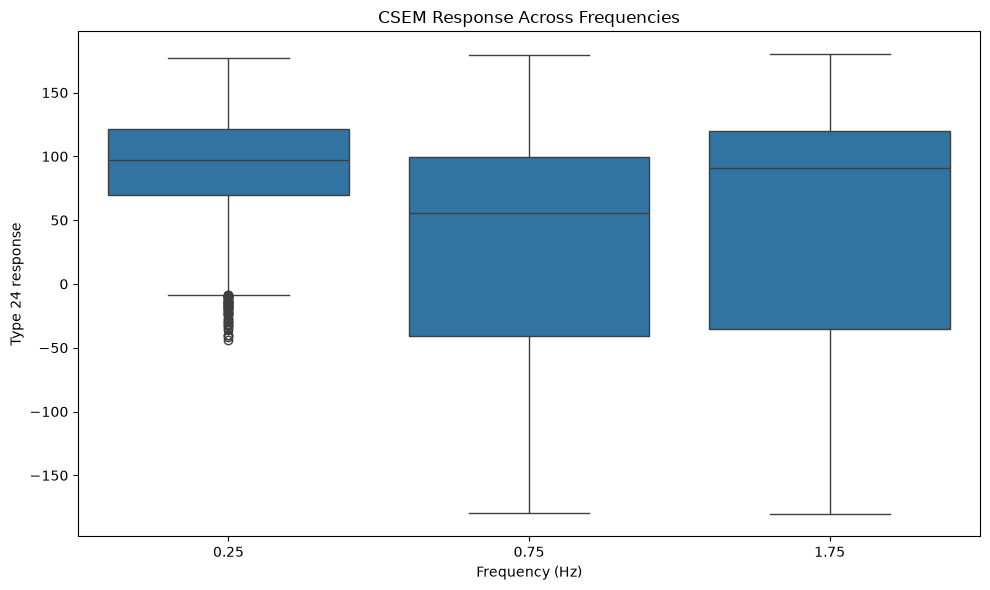

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_wide,
    x="frequency_hz",
    y="data_24"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Type 24 response")
plt.title("CSEM Response Across Frequencies")
plt.tight_layout()
plt.show()

In [16]:
receiver_start = 42
receiver_end = 1112

receiver_lines = []

for line in lines[receiver_start:receiver_end]:
    line = line.strip()

    if line and not line.startswith("!"):
        receiver_lines.append(line)

print("Receiver records:", len(receiver_lines))

Receiver records: 1070


In [17]:
df_rx = pd.read_csv(
    StringIO("\n".join(receiver_lines)),
    sep=r"\s+",
    header=None,
    names=[
        "x",
        "y",
        "z",
        "theta",
        "alpha",
        "beta",
        "length"
    ]
)

df_rx["rx_id"] = np.arange(1, len(df_rx) + 1)

print(df_rx.head())
print(df_rx.shape)

    x       y    z  theta  alpha  beta  length  rx_id
0  44 -119957  6.4  174.0    0.0  -1.0       0      1
1  45 -119871  5.8  175.0    0.0  -1.0       0      2
2  44 -119777  4.3  175.0    0.0  -1.0       0      3
3  42 -119681  3.7  175.0    0.0   0.0       0      4
4  42 -119584  3.8  175.0    0.0   0.0       0      5
(1070, 8)


In [18]:
tx_lines = []

for line in lines:
    stripped = line.strip()

    if (
        stripped
        and not stripped.startswith("!")
        and "edipole" in stripped
    ):
        tx_lines.append(stripped)

print("Transmitters found:", len(tx_lines))

Transmitters found: 30


In [19]:
df_tx = pd.read_csv(
    StringIO("\n".join(tx_lines)),
    sep=r"\s+",
    header=None,
    names=[
        "x",
        "y",
        "z",
        "azimuth",
        "dip",
        "length",
        "type",
        "name"
    ]
)

df_tx["tx_id"] = np.arange(1, len(df_tx) + 1)

print(df_tx.head())
print(df_tx.shape)

    x       y      z  azimuth  dip  length     type  name  tx_id
0  35 -126214  105.0     90.0  2.0       0  edipole  541c      1
1  32 -122222  103.7     90.0 -1.0       0  edipole  541b      2
2  41 -118214  118.3     90.0 -2.0       0  edipole  541a      3
3   9 -114195  130.7     90.0  7.0       0  edipole   541      4
4  13 -110225  142.2     90.0  1.0       0  edipole  540c      5
(30, 9)


In [20]:
df_ml = df_wide.merge(
    df_tx[
        ["tx_id", "x", "y", "z", "azimuth", "dip"]
    ],
    on="tx_id",
    how="left"
)

df_ml = df_ml.rename(columns={
    "x": "tx_x",
    "y": "tx_y",
    "z": "tx_z"
})

In [21]:
df_ml = df_ml.merge(
    df_rx[
        ["rx_id", "x", "y", "z", "theta", "alpha", "beta"]
    ],
    on="rx_id",
    how="left"
)

df_ml = df_ml.rename(columns={
    "x": "rx_x",
    "y": "rx_y",
    "z": "rx_z"
})

In [22]:
print(df_ml.head())
print("\nShape:", df_ml.shape)

   freq_id  tx_id  rx_id  data_24  data_28  stderr_24  stderr_28  \
0        1      1      1  113.104 -11.5320    1.71894   0.013029   
1        1      1      2  112.266 -11.5594    1.71894   0.013029   
2        1      1      3  112.170 -11.5761    1.71894   0.013029   
3        1      1      4  112.047 -11.6111    1.71894   0.013029   
4        1      1      5  110.307 -11.6323    1.71894   0.013029   

   frequency_hz  tx_x    tx_y   tx_z  azimuth  dip  rx_x    rx_y  rx_z  theta  \
0          0.25    35 -126214  105.0     90.0  2.0    44 -119957   6.4  174.0   
1          0.25    35 -126214  105.0     90.0  2.0    45 -119871   5.8  175.0   
2          0.25    35 -126214  105.0     90.0  2.0    44 -119777   4.3  175.0   
3          0.25    35 -126214  105.0     90.0  2.0    42 -119681   3.7  175.0   
4          0.25    35 -126214  105.0     90.0  2.0    42 -119584   3.8  175.0   

   alpha  beta  
0    0.0  -1.0  
1    0.0  -1.0  
2    0.0  -1.0  
3    0.0   0.0  
4    0.0   0.0  

S

In [23]:
df_ml["tx_rx_distance"] = np.sqrt(
    (df_ml["tx_x"] - df_ml["rx_x"])**2 +
    (df_ml["tx_y"] - df_ml["rx_y"])**2 +
    (df_ml["tx_z"] - df_ml["rx_z"])**2
)

In [24]:
df_ml["tx_rx_distance"] = np.sqrt(
    (df_ml["tx_x"] - df_ml["rx_x"])**2 +
    (df_ml["tx_y"] - df_ml["rx_y"])**2 +
    (df_ml["tx_z"] - df_ml["rx_z"])**2
)

In [25]:
df_ml["vertical_separation"] = (
    df_ml["tx_z"] - df_ml["rx_z"]
)

In [26]:
df_ml["response_24_abs"] = np.abs(df_ml["data_24"])
df_ml["response_28_abs"] = np.abs(df_ml["data_28"])

In [27]:
df_ml["response_ratio"] = (
    df_ml["response_24_abs"] /
    (df_ml["response_28_abs"] + 1e-10)
)

In [28]:
df_ml["response_ratio"] = (
    df_ml["response_24_abs"] /
    (df_ml["response_28_abs"] + 1e-10)
)

In [29]:
df_ml["response_magnitude"] = np.sqrt(
    df_ml["data_24"]**2 +
    df_ml["data_28"]**2
)

In [30]:
df_ml["log_response_magnitude"] = np.log10(
    df_ml["response_magnitude"] + 1e-10
)

In [32]:
df_ml["horizontal_distance"] = np.sqrt(
    (df_ml["tx_x"] - df_ml["rx_x"])**2 +
    (df_ml["tx_y"] - df_ml["rx_y"])**2
)

df_ml["response_difference"] = (
    df_ml["data_24"] - df_ml["data_28"]
)

In [33]:
feature_cols = [
    "frequency_hz",
    "data_24",
    "data_28",
    "stderr_24",
    "stderr_28",
    "tx_rx_distance",
    "horizontal_distance",
    "vertical_separation",
    "response_24_abs",
    "response_28_abs",
    "response_ratio",
    "response_difference",
    "response_magnitude"
]

missing = [col for col in feature_cols if col not in df_ml.columns]

print("Missing columns:", missing)

Missing columns: []


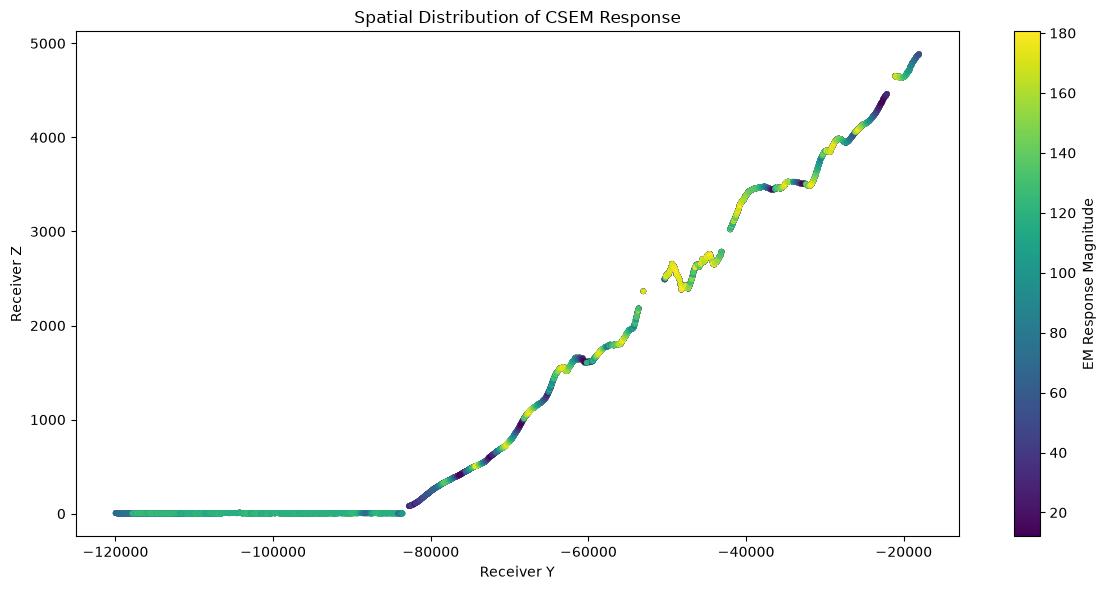

In [34]:
plt.figure(figsize=(12, 6))

scatter = plt.scatter(
    df_ml["rx_y"],
    df_ml["rx_z"],
    c=df_ml["response_magnitude"],
    s=10
)

plt.colorbar(scatter, label="EM Response Magnitude")

plt.xlabel("Receiver Y")
plt.ylabel("Receiver Z")
plt.title("Spatial Distribution of CSEM Response")

plt.tight_layout()
plt.show()

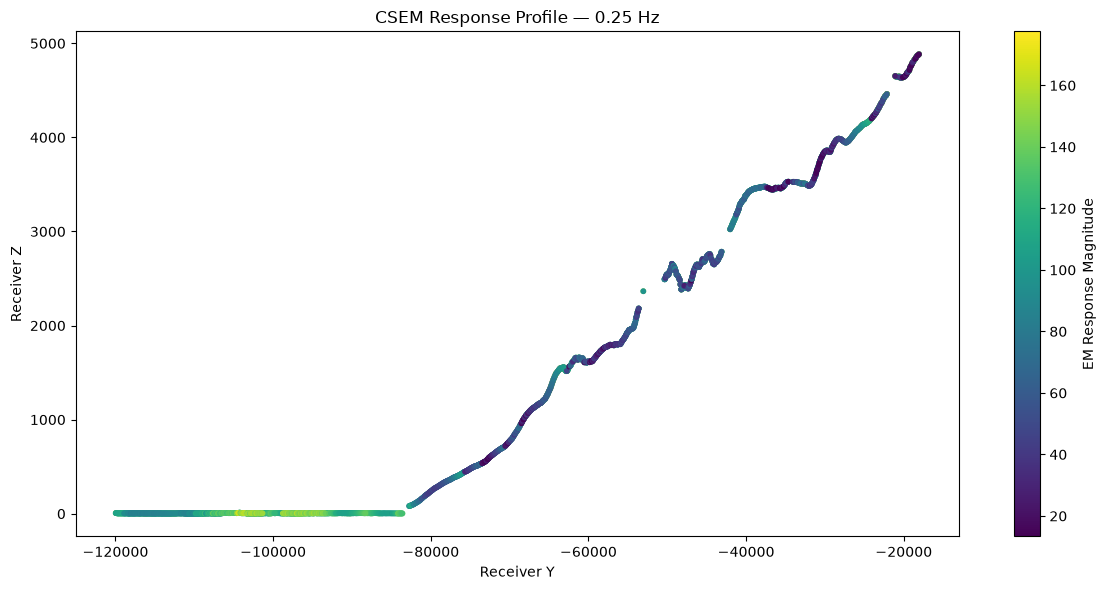

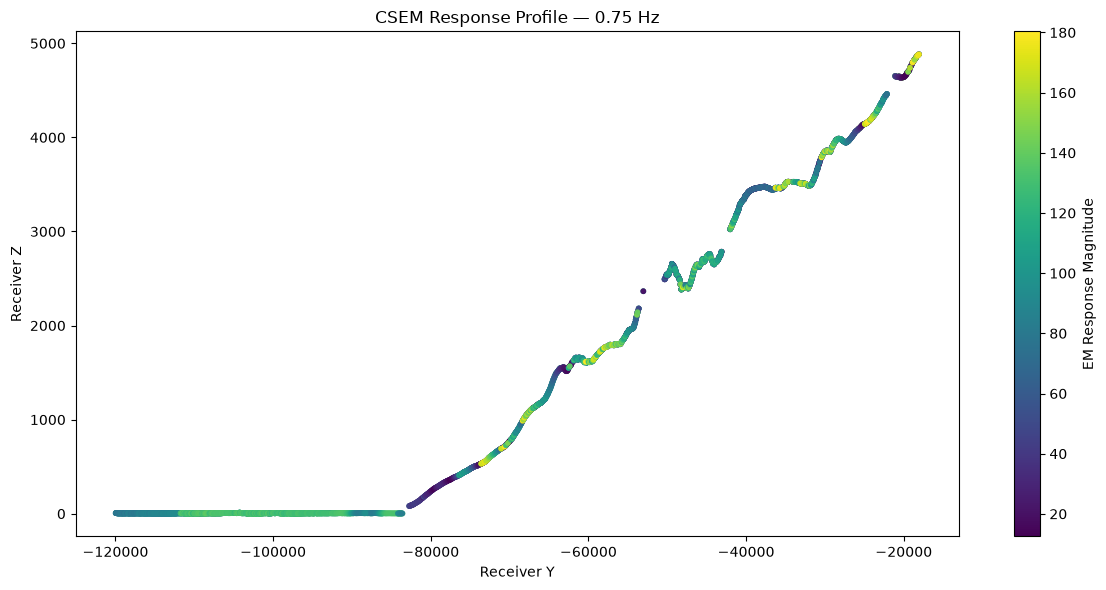

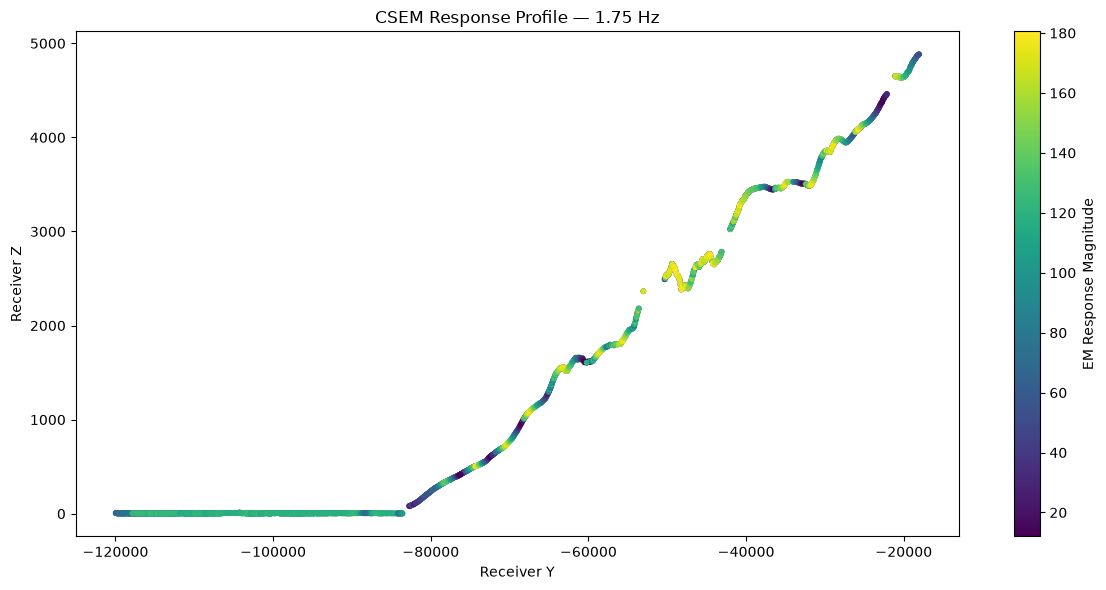

In [35]:
frequencies = sorted(df_ml["frequency_hz"].unique())

for freq in frequencies:

    df_freq = df_ml[df_ml["frequency_hz"] == freq]

    plt.figure(figsize=(12, 6))

    scatter = plt.scatter(
        df_freq["rx_y"],
        df_freq["rx_z"],
        c=df_freq["response_magnitude"],
        s=10
    )

    plt.colorbar(
        scatter,
        label="EM Response Magnitude"
    )

    plt.xlabel("Receiver Y")
    plt.ylabel("Receiver Z")

    plt.title(
        f"CSEM Response Profile — {freq} Hz"
    )

    plt.tight_layout()
    plt.show()

In [37]:
print([x for x in globals().keys() if not x.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'np', 'pd', 'plt', 'sns', 'Path', 'StringIO', 'BASE_DIR', 'EMAGE_DIR', 'CSEM_FILE', 'frequency_map', 'f', 'lines', 'data_start', 'data_lines', 'df_csem', 'df_wide', 'receiver_start', 'receiver_end', 'receiver_lines', 'line', 'df_rx', 'tx_lines', 'stripped', 'df_tx', 'df_ml', 'feature_cols', 'missing', 'scatter', 'frequencies', 'freq', 'df_freq']


In [38]:
df = df_ml

print(df[["data_24", "data_28"]].describe())

print("\nUnique values:")
print("data_24:", df["data_24"].nunique())
print("data_28:", df["data_28"].nunique())

print("\nSample values:")
print(df[["data_24", "data_28"]].head(20))

            data_24       data_28
count  11729.000000  11729.000000
mean      54.925078    -12.970327
std       84.739969      0.925397
min     -179.946000    -15.214100
25%        6.934480    -13.648100
50%       84.842200    -12.981800
75%      118.689000    -12.301500
max      179.998000    -10.365500

Unique values:
data_24: 11487
data_28: 9969

Sample values:
    data_24  data_28
0   113.104 -11.5320
1   112.266 -11.5594
2   112.170 -11.5761
3   112.047 -11.6111
4   110.307 -11.6323
5   107.280 -11.6540
6   109.104 -11.6604
7   106.602 -11.7015
8   106.181 -11.6939
9   106.484 -11.7367
10  107.916 -11.7371
11  105.496 -11.7544
12  105.680 -11.7880
13  106.159 -11.8063
14  105.892 -11.8139
15  104.129 -11.8281
16  104.618 -11.8523
17  103.971 -11.8665
18  104.511 -11.8952
19  102.599 -11.9136


In [39]:
print(df.columns.tolist())

['freq_id', 'tx_id', 'rx_id', 'data_24', 'data_28', 'stderr_24', 'stderr_28', 'frequency_hz', 'tx_x', 'tx_y', 'tx_z', 'azimuth', 'dip', 'rx_x', 'rx_y', 'rx_z', 'theta', 'alpha', 'beta', 'tx_rx_distance', 'vertical_separation', 'response_24_abs', 'response_28_abs', 'response_ratio', 'response_magnitude', 'log_response_magnitude', 'horizontal_distance', 'response_difference']


In [40]:
print(df.head(3).T)

                                    0              1              2
freq_id                      1.000000       1.000000       1.000000
tx_id                        1.000000       1.000000       1.000000
rx_id                        1.000000       2.000000       3.000000
data_24                    113.104000     112.266000     112.170000
data_28                    -11.532000     -11.559400     -11.576100
stderr_24                    1.718940       1.718940       1.718940
stderr_28                    0.013029       0.013029       0.013029
frequency_hz                 0.250000       0.250000       0.250000
tx_x                        35.000000      35.000000      35.000000
tx_y                   -126214.000000 -126214.000000 -126214.000000
tx_z                       105.000000     105.000000     105.000000
azimuth                     90.000000      90.000000      90.000000
dip                          2.000000       2.000000       2.000000
rx_x                        44.000000      45.00

In [41]:
print(df.dtypes)

freq_id                     int64
tx_id                       int64
rx_id                       int64
data_24                   float64
data_28                   float64
stderr_24                 float64
stderr_28                 float64
frequency_hz              float64
tx_x                        int64
tx_y                        int64
tx_z                      float64
azimuth                   float64
dip                       float64
rx_x                        int64
rx_y                        int64
rx_z                      float64
theta                     float64
alpha                     float64
beta                      float64
tx_rx_distance            float64
vertical_separation       float64
response_24_abs           float64
response_28_abs           float64
response_ratio            float64
response_magnitude        float64
log_response_magnitude    float64
horizontal_distance       float64
response_difference       float64
dtype: object


In [42]:
freq_map = (
    df[["freq_id", "frequency_hz"]]
    .drop_duplicates()
    .sort_values("freq_id")
)

print(freq_map.to_string(index=False))

 freq_id  frequency_hz
       1          0.25
       2          0.75
       3          1.75


In [43]:
print("\nNumber of frequencies:", df["frequency_hz"].nunique())
print("Frequency values:", sorted(df["frequency_hz"].unique()))


Number of frequencies: 3
Frequency values: [np.float64(0.25), np.float64(0.75), np.float64(1.75)]


In [45]:
print(
    df.groupby("frequency_hz")[["data_24", "data_28"]]
      .agg(["count", "mean", "std"])
)

             data_24                        data_28                     
               count       mean         std   count       mean       std
frequency_hz                                                            
0.25            4026  92.513918   39.003446    4026 -12.625892  0.863152
0.75            4399  28.615041   89.326605    4399 -13.120647  0.945413
1.75            3304  44.151827  101.285083    3304 -13.189893  0.848385


In [47]:
pair_freq = (
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .nunique()
)

print(pair_freq.value_counts().sort_index())

frequency_hz
1     448
2    1217
3    2949
Name: count, dtype: int64


In [48]:
print(
    "Pairs with all 3 frequencies:",
    (pair_freq == 3).sum()
)

print(
    "Total TX-RX pairs:",
    len(pair_freq)
)

Pairs with all 3 frequencies: 2949
Total TX-RX pairs: 4614


In [49]:
print(
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .unique()
      .head(10)
)

tx_id  rx_id
1      1        [0.25, 0.75, 1.75]
       2        [0.25, 0.75, 1.75]
       3        [0.25, 0.75, 1.75]
       4        [0.25, 0.75, 1.75]
       5        [0.25, 0.75, 1.75]
       6        [0.25, 0.75, 1.75]
       7        [0.25, 0.75, 1.75]
       8        [0.25, 0.75, 1.75]
       9        [0.25, 0.75, 1.75]
       10       [0.25, 0.75, 1.75]
Name: frequency_hz, dtype: object


In [50]:
# Count frequencies available for each TX-RX pair
pair_freq = (
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .nunique()
)

# Keep only TX-RX pairs measured at all 3 frequencies
complete_pairs = pair_freq[pair_freq == 3].index

df_fp = df.set_index(["tx_id", "rx_id"]).loc[complete_pairs].reset_index()

print("Original rows:", len(df))
print("Fingerprint rows:", len(df_fp))
print("Unique TX-RX pairs:", df_fp[["tx_id", "rx_id"]].drop_duplicates().shape[0])

Original rows: 11729
Fingerprint rows: 8847
Unique TX-RX pairs: 2949


In [51]:
fingerprint = df_fp.pivot(
    index=["tx_id", "rx_id"],
    columns="frequency_hz",
    values=["data_24", "data_28"]
)

fingerprint.columns = [
    f"{channel}_{freq:.2f}Hz"
    for channel, freq in fingerprint.columns
]

fingerprint = fingerprint.reset_index()

print(fingerprint.head())
print("\nShape:", fingerprint.shape)

   tx_id  rx_id  data_24_0.25Hz  data_24_0.75Hz  data_24_1.75Hz  \
0      1      1         113.104         86.2519         75.3569   
1      1      2         112.266         86.5195         75.4078   
2      1      3         112.170         86.1665         74.8849   
3      1      4         112.047         86.0404         75.7134   
4      1      5         110.307         86.1789         74.9912   

   data_28_0.25Hz  data_28_0.75Hz  data_28_1.75Hz  
0        -11.5320        -12.0648        -12.4547  
1        -11.5594        -12.0882        -12.4816  
2        -11.5761        -12.1107        -12.5027  
3        -11.6111        -12.1376        -12.5269  
4        -11.6323        -12.1624        -12.5497  

Shape: (2949, 8)


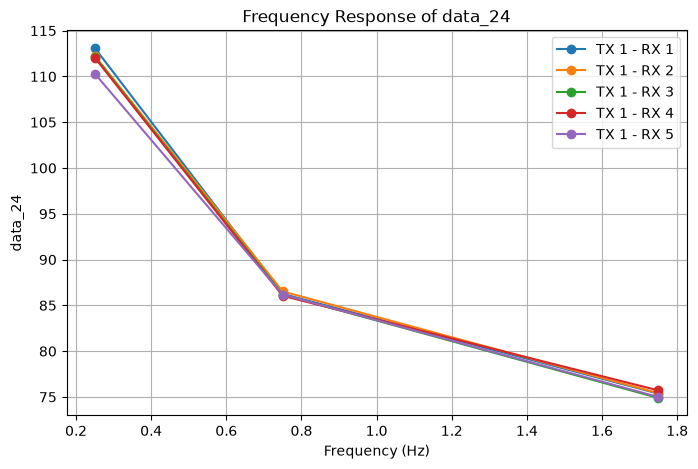

In [52]:
import matplotlib.pyplot as plt

# Select first 5 complete TX-RX pairs
sample_fp = fingerprint.head(5)

frequencies = [0.25, 0.75, 1.75]

# -----------------------------
# data_24 frequency response
# -----------------------------
plt.figure(figsize=(8, 5))

for _, row in sample_fp.iterrows():
    values = [
        row["data_24_0.25Hz"],
        row["data_24_0.75Hz"],
        row["data_24_1.75Hz"]
    ]

    plt.plot(
        frequencies,
        values,
        marker="o",
        label=f"TX {int(row['tx_id'])} - RX {int(row['rx_id'])}"
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("data_24")
plt.title("Frequency Response of data_24")
plt.legend()
plt.grid(True)
plt.show()

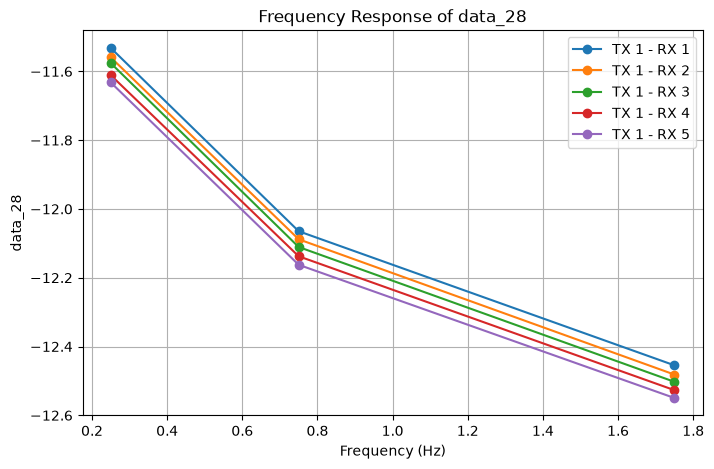

In [53]:
# -----------------------------
# data_28 frequency response
# -----------------------------
plt.figure(figsize=(8, 5))

for _, row in sample_fp.iterrows():
    values = [
        row["data_28_0.25Hz"],
        row["data_28_0.75Hz"],
        row["data_28_1.75Hz"]
    ]

    plt.plot(
        frequencies,
        values,
        marker="o",
        label=f"TX {int(row['tx_id'])} - RX {int(row['rx_id'])}"
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("data_28")
plt.title("Frequency Response of data_28")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
geometry_cols = [
    "tx_rx_distance",
    "horizontal_distance",
    "vertical_separation"
]

print(df[geometry_cols].describe())

       tx_rx_distance  horizontal_distance  vertical_separation
count    11729.000000         11729.000000         11729.000000
mean      6343.342371          6329.233355           158.934189
std       3036.081769          3033.782732           409.274275
min       2002.501685          2000.761105          -969.500000
25%       3877.162397          3861.798804            30.500000
50%       5846.614242          5831.340326           135.600000
75%       8267.244395          8250.056060           333.000000
max      17615.467170         17615.001391          1473.300000


In [55]:
print(
    df[
        [
            "tx_rx_distance",
            "horizontal_distance",
            "vertical_separation",
            "data_24",
            "data_28"
        ]
    ].corr()
)

                     tx_rx_distance  horizontal_distance  vertical_separation  \
tx_rx_distance             1.000000             0.999981             0.065122   
horizontal_distance        0.999981             1.000000             0.061717   
vertical_separation        0.065122             0.061717             1.000000   
data_24                   -0.074783            -0.072597            -0.060435   
data_28                   -0.681093            -0.679225            -0.081313   

                      data_24   data_28  
tx_rx_distance      -0.074783 -0.681093  
horizontal_distance -0.072597 -0.679225  
vertical_separation -0.060435 -0.081313  
data_24              1.000000  0.497622  
data_28              0.497622  1.000000  


In [56]:
import numpy as np

df_geom = df.copy()

df_geom["log_distance"] = np.log10(
    df_geom["tx_rx_distance"].clip(lower=1)
)

print(
    df_geom[
        ["log_distance", "data_28", "data_24"]
    ].corr()
)

              log_distance   data_28   data_24
log_distance      1.000000 -0.734506 -0.101405
data_28          -0.734506  1.000000  0.497622
data_24          -0.101405  0.497622  1.000000


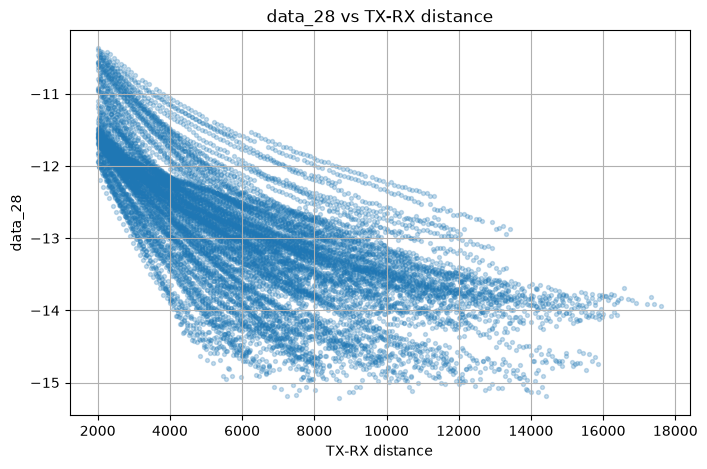

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df_geom["tx_rx_distance"],
    df_geom["data_28"],
    s=8,
    alpha=0.25
)

plt.xlabel("TX-RX distance")
plt.ylabel("data_28")
plt.title("data_28 vs TX-RX distance")
plt.grid(True)
plt.show()

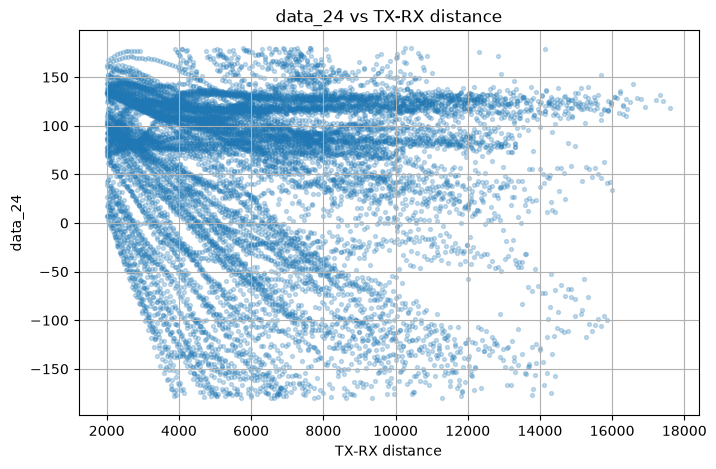

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_geom["tx_rx_distance"],
    df_geom["data_24"],
    s=8,
    alpha=0.25
)

plt.xlabel("TX-RX distance")
plt.ylabel("data_24")
plt.title("data_24 vs TX-RX distance")
plt.grid(True)
plt.show()

In [59]:
import numpy as np
from sklearn.linear_model import LinearRegression

df_geom = df.copy()

# Log-distance
df_geom["log_distance"] = np.log10(
    df_geom["tx_rx_distance"].clip(lower=1)
)

# Create empty column
df_geom["data_28_geometry_residual"] = np.nan

# Fit separately for each frequency
for freq in sorted(df_geom["frequency_hz"].unique()):

    mask = df_geom["frequency_hz"] == freq

    X = df_geom.loc[mask, ["log_distance"]]
    y = df_geom.loc[mask, "data_28"]

    model = LinearRegression()
    model.fit(X, y)

    predicted = model.predict(X)

    df_geom.loc[mask, "data_28_geometry_residual"] = (
        y.values - predicted
    )

    print(
        f"Frequency: {freq} Hz | "
        f"Slope: {model.coef_[0]:.4f} | "
        f"Intercept: {model.intercept_:.4f} | "
        f"R²: {model.score(X, y):.4f}"
    )

Frequency: 0.25 Hz | Slope: -3.3745 | Intercept: 0.0391 | R²: 0.6807
Frequency: 0.75 Hz | Slope: -3.4727 | Intercept: -0.0040 | R²: 0.6563
Frequency: 1.75 Hz | Slope: -2.6458 | Intercept: -3.3651 | R²: 0.4307


In [60]:
print(
    df_geom[
        [
            "log_distance",
            "data_28",
            "data_28_geometry_residual"
        ]
    ].corr()
)

                           log_distance   data_28  data_28_geometry_residual
log_distance               1.000000e+00 -0.734506              -3.982796e-15
data_28                   -7.345059e-01  1.000000               6.038648e-01
data_28_geometry_residual -3.982796e-15  0.603865               1.000000e+00


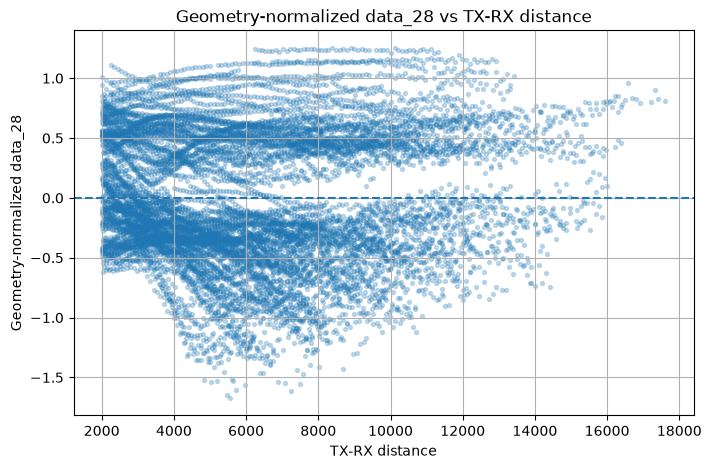

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df_geom["tx_rx_distance"],
    df_geom["data_28_geometry_residual"],
    s=8,
    alpha=0.25
)

plt.axhline(0, linestyle="--")

plt.xlabel("TX-RX distance")
plt.ylabel("Geometry-normalized data_28")
plt.title("Geometry-normalized data_28 vs TX-RX distance")
plt.grid(True)
plt.show()

In [63]:
[c for c in df_ml.columns if "28" in c.lower() or "residual" in c.lower()]

['data_28', 'stderr_28', 'response_28_abs']

In [64]:
df_ml.columns.tolist()

['freq_id',
 'tx_id',
 'rx_id',
 'data_24',
 'data_28',
 'stderr_24',
 'stderr_28',
 'frequency_hz',
 'tx_x',
 'tx_y',
 'tx_z',
 'azimuth',
 'dip',
 'rx_x',
 'rx_y',
 'rx_z',
 'theta',
 'alpha',
 'beta',
 'tx_rx_distance',
 'vertical_separation',
 'response_24_abs',
 'response_28_abs',
 'response_ratio',
 'response_magnitude',
 'log_response_magnitude',
 'horizontal_distance',
 'response_difference']

In [65]:
import numpy as np
import pandas as pd

print("Rows:", len(df_ml))
print("Frequencies:")
print(df_ml["frequency_hz"].value_counts().sort_index())

print("\nColumns:")
print(df_ml.columns.tolist())

print("\nData_28 statistics:")
print(df_ml["data_28"].describe())

Rows: 11729
Frequencies:
frequency_hz
0.25    4026
0.75    4399
1.75    3304
Name: count, dtype: int64

Columns:
['freq_id', 'tx_id', 'rx_id', 'data_24', 'data_28', 'stderr_24', 'stderr_28', 'frequency_hz', 'tx_x', 'tx_y', 'tx_z', 'azimuth', 'dip', 'rx_x', 'rx_y', 'rx_z', 'theta', 'alpha', 'beta', 'tx_rx_distance', 'vertical_separation', 'response_24_abs', 'response_28_abs', 'response_ratio', 'response_magnitude', 'log_response_magnitude', 'horizontal_distance', 'response_difference']

Data_28 statistics:
count    11729.000000
mean       -12.970327
std          0.925397
min        -15.214100
25%        -13.648100
50%        -12.981800
75%        -12.301500
max        -10.365500
Name: data_28, dtype: float64


In [66]:
for f in sorted(df_ml["frequency_hz"].unique()):
    temp = df_ml[df_ml["frequency_hz"] == f]

    print(f"\nFrequency: {f} Hz")
    print("data_28 mean:", temp["data_28"].mean())
    print("data_28 median:", temp["data_28"].median())
    print("data_28 std:", temp["data_28"].std())


Frequency: 0.25 Hz
data_28 mean: -12.625891604570294
data_28 median: -12.6907
data_28 std: 0.8631519450206049

Frequency: 0.75 Hz
data_28 mean: -13.120646692430096
data_28 median: -13.1474
data_28 std: 0.9454130628999708

Frequency: 1.75 Hz
data_28 mean: -13.189892584745763
data_28 median: -13.185749999999999
data_28 std: 0.8483846968186319


In [67]:
%history -n 45-65

  45:
print(
    df.groupby("frequency_hz")[["data_24", "data_28"]]
      .agg(["count", "mean", "std"])
)
  46: mean(data_24)
  47:
pair_freq = (
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .nunique()
)

print(pair_freq.value_counts().sort_index())
  48:
print(
    "Pairs with all 3 frequencies:",
    (pair_freq == 3).sum()
)

print(
    "Total TX-RX pairs:",
    len(pair_freq)
)
  49:
print(
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .unique()
      .head(10)
)
  50:
# Count frequencies available for each TX-RX pair
pair_freq = (
    df.groupby(["tx_id", "rx_id"])["frequency_hz"]
      .nunique()
)

# Keep only TX-RX pairs measured at all 3 frequencies
complete_pairs = pair_freq[pair_freq == 3].index

df_fp = df.set_index(["tx_id", "rx_id"]).loc[complete_pairs].reset_index()

print("Original rows:", len(df))
print("Fingerprint rows:", len(df_fp))
print("Unique TX-RX pairs:", df_fp[["tx_id", "rx_id"]].drop_duplicates().shape[0])
  51:
fingerprint = df_fp.piv

In [68]:
df_ml["data_28_geometry_residual"] = df_geom[
    "data_28_geometry_residual"
].values

print(
    df_ml[
        [
            "frequency_hz",
            "data_28",
            "data_28_geometry_residual"
        ]
    ].head()
)

   frequency_hz  data_28  data_28_geometry_residual
0          0.25 -11.5320                   1.239979
1          0.25 -11.5594                   1.232582
2          0.25 -11.5761                   1.237441
3          0.25 -11.6111                   1.224133
4          0.25 -11.6323                   1.224527


In [69]:
print(df_ml["data_28_geometry_residual"].describe())

count    1.172900e+04
mean     2.520128e-16
std      5.588144e-01
min     -1.671916e+00
25%     -3.988386e-01
50%     -1.188324e-01
75%      4.953620e-01
max      1.252352e+00
Name: data_28_geometry_residual, dtype: float64


In [70]:
freq_summary = (
    df_ml
    .groupby("frequency_hz")[
        [
            "data_24",
            "data_28",
            "data_28_geometry_residual"
        ]
    ]
    .agg(["count", "mean", "median", "std"])
)

freq_summary

data_24                                  data_28             \
               count       mean    median         std   count       mean   
frequency_hz                                                               
0.25            4026  92.513918  97.03345   39.003446    4026 -12.625892   
0.75            4399  28.615041  55.47750   89.326605    4399 -13.120647   
1.75            3304  44.151827  91.19140  101.285083    3304 -13.189893   

                                 data_28_geometry_residual                \
                median       std                     count          mean   
frequency_hz                                                               
0.25         -12.69070  0.863152                      4026 -8.114059e-16   
0.75         -13.14740  0.945413                      4399  7.777366e-16   
1.75         -13.18575  0.848385                      3304  8.698987e-16   

                                  
                median       std  
frequency_hz                      
0.25         -0.202640  0.487756  
0.75         -0.141901  0.554293  
1.75          0.332898  0.640147

In [71]:
df_fp_corrected = df_ml.pivot_table(
    index=["tx_id", "rx_id"],
    columns="frequency_hz",
    values=[
        "data_24",
        "data_28",
        "data_28_geometry_residual"
    ],
    aggfunc="mean"
)

df_fp_corrected.columns = [
    f"{channel}_{freq:.2f}Hz"
    for channel, freq in df_fp_corrected.columns
]

df_fp_corrected = df_fp_corrected.reset_index()

print(df_fp_corrected.shape)
print(df_fp_corrected.head())

(4614, 11)
   tx_id  rx_id  data_24_0.25Hz  data_24_0.75Hz  data_24_1.75Hz  \
0      1      1         113.104         86.2519         75.3569   
1      1      2         112.266         86.5195         75.4078   
2      1      3         112.170         86.1665         74.8849   
3      1      4         112.047         86.0404         75.7134   
4      1      5         110.307         86.1789         74.9912   

   data_28_0.25Hz  data_28_0.75Hz  data_28_1.75Hz  \
0        -11.5320        -12.0648        -12.4547   
1        -11.5594        -12.0882        -12.4816   
2        -11.5761        -12.1107        -12.5027   
3        -11.6111        -12.1376        -12.5269   
4        -11.6323        -12.1624        -12.5497   

   data_28_geometry_residual_0.25Hz  data_28_geometry_residual_0.75Hz  \
0                          1.239979                          1.123078   
1                          1.232582                          1.120263   
2                          1.237441             

In [72]:
df_fp_corrected["data28_freq_change"] = (
    df_fp_corrected["data_28_geometry_residual_1.75Hz"]
    - df_fp_corrected["data_28_geometry_residual_0.25Hz"]
)

df_fp_corrected["data28_freq_slope"] = (
    df_fp_corrected["data28_freq_change"] / (1.75 - 0.25)
)

df_fp_corrected["data28_freq_curvature"] = (
    df_fp_corrected["data_28_geometry_residual_1.75Hz"]
    - 2 * df_fp_corrected["data_28_geometry_residual_0.75Hz"]
    + df_fp_corrected["data_28_geometry_residual_0.25Hz"]
)

In [74]:
df_fp_corrected["data24_freq_change"] = (
    df_fp_corrected["data_24_1.75Hz"]
    - df_fp_corrected["data_24_0.25Hz"]
)

df_fp_corrected["data24_freq_slope"] = (
    df_fp_corrected["data24_freq_change"] / (1.75 - 0.25)
)

df_fp_corrected["data24_freq_curvature"] = (
    df_fp_corrected["data_24_1.75Hz"]
    - 2 * df_fp_corrected["data_24_0.75Hz"]
    + df_fp_corrected["data_24_0.25Hz"]
)

In [75]:
df_fp_corrected[
    [
        "data28_freq_change",
        "data28_freq_slope",
        "data28_freq_curvature",
        "data24_freq_change",
        "data24_freq_slope",
        "data24_freq_curvature"
    ]
].describe()

,data28_freq_change,data28_freq_slope,data28_freq_curvature,data24_freq_change,data24_freq_slope,data24_freq_curvature
count,2953.000000,2953.000000,2949.000000,2953.000000,2953.000000,2949.000000
mean,-0.143878,-0.095919,-0.175684,-73.046197,-48.697465,33.639397
std,0.425055,0.283370,0.312974,106.860956,71.240637,117.092399
min,-1.331168,-0.887446,-1.037152,-281.622000,-187.748000,-109.769970
25%,-0.454363,-0.302909,-0.413517,-170.636200,-113.757467,-32.963300
50%,-0.119012,-0.079341,-0.212368,-34.931900,-23.287933,-15.632600
75%,0.185244,0.123496,-0.004896,12.308000,8.205333,32.519300
max,0.980677,0.653785,0.772351,121.073900,80.715933,378.651100


In [76]:
freq_features = [
    "data28_freq_change",
    "data28_freq_curvature",
    "data24_freq_change",
    "data24_freq_curvature"
]

print(
    df_fp_corrected[freq_features]
    .corr()
)

                       data28_freq_change  data28_freq_curvature  \
data28_freq_change               1.000000               0.432912   
data28_freq_curvature            0.432912               1.000000   
data24_freq_change              -0.142910               0.188037   
data24_freq_curvature           -0.606272              -0.365198   

                       data24_freq_change  data24_freq_curvature  
data28_freq_change              -0.142910              -0.606272  
data28_freq_curvature            0.188037              -0.365198  
data24_freq_change               1.000000               0.602982  
data24_freq_curvature            0.602982               1.000000  


In [77]:
print(
    df_fp_corrected[freq_features]
    .describe()
)

       data28_freq_change  data28_freq_curvature  data24_freq_change  \
count         2953.000000            2949.000000         2953.000000   
mean            -0.143878              -0.175684          -73.046197   
std              0.425055               0.312974          106.860956   
min             -1.331168              -1.037152         -281.622000   
25%             -0.454363              -0.413517         -170.636200   
50%             -0.119012              -0.212368          -34.931900   
75%              0.185244              -0.004896           12.308000   
max              0.980677               0.772351          121.073900   

       data24_freq_curvature  
count            2949.000000  
mean               33.639397  
std               117.092399  
min              -109.769970  
25%               -32.963300  
50%               -15.632600  
75%                32.519300  
max               378.651100  


In [78]:
pair_geometry = (
    df_ml[
        [
            "tx_id",
            "rx_id",
            "tx_rx_distance",
            "horizontal_distance",
            "vertical_separation"
        ]
    ]
    .drop_duplicates(["tx_id", "rx_id"])
)

df_freq = df_fp_corrected.merge(
    pair_geometry,
    on=["tx_id", "rx_id"],
    how="left"
)

print(
    df_freq[
        freq_features +
        [
            "tx_rx_distance",
            "horizontal_distance",
            "vertical_separation"
        ]
    ].corr()
)

                       data28_freq_change  data28_freq_curvature  \
data28_freq_change               1.000000               0.432912   
data28_freq_curvature            0.432912               1.000000   
data24_freq_change              -0.142910               0.188037   
data24_freq_curvature           -0.606272              -0.365198   
tx_rx_distance                  -0.413679              -0.430238   
horizontal_distance             -0.411599              -0.427232   
vertical_separation             -0.036505              -0.034574   

                       data24_freq_change  data24_freq_curvature  \
data28_freq_change              -0.142910              -0.606272   
data28_freq_curvature            0.188037              -0.365198   
data24_freq_change               1.000000               0.602982   
data24_freq_curvature            0.602982               1.000000   
tx_rx_distance                   0.349866               0.209536   
horizontal_distance              0.351871      

In [79]:
receiver_positions = (
    df_ml[
        ["rx_id", "rx_x", "rx_y", "rx_z"]
    ]
    .drop_duplicates("rx_id")
    .sort_values("rx_id")
)

print("Unique receivers:", len(receiver_positions))
print(receiver_positions.head(10))
print(receiver_positions.tail(10))

Unique receivers: 1070
   rx_id  rx_x    rx_y  rx_z
0      1    44 -119957   6.4
1      2    45 -119871   5.8
2      3    44 -119777   4.3
3      4    42 -119681   3.7
4      5    42 -119584   3.8
5      6    41 -119486   4.0
6      7    40 -119389   4.2
7      8    39 -119291   3.6
8      9    38 -119193   4.0
9     10    37 -119095   3.3
      rx_id  rx_x   rx_y    rx_z
3551   1061    21 -18802  4803.7
3552   1062    23 -18720  4815.6
3553   1063    26 -18640  4825.6
3554   1064    28 -18558  4834.5
3555   1065    31 -18477  4842.8
3556   1066    32 -18395  4856.4
3557   1067    35 -18314  4866.5
3558   1068    38 -18232  4871.1
3559   1069    40 -18151  4876.8
3560   1070    42 -18069  4883.6


In [80]:
print(
    receiver_positions[
        ["rx_x", "rx_y", "rx_z"]
    ].describe()
)

              rx_x           rx_y         rx_z
count  1070.000000    1070.000000  1070.000000
mean     25.457009  -69242.586916  1479.216262
std      95.486473   29394.282090  1579.386826
min    -174.000000 -119957.000000     1.700000
25%     -39.000000  -95116.000000     4.700000
50%      16.000000  -69616.000000   808.250000
75%      62.000000  -43665.750000  2743.600000
max     757.000000  -18069.000000  4883.600000


In [81]:
import numpy as np

receiver_positions = receiver_positions.sort_values("rx_id").reset_index(drop=True)

receiver_positions["dx"] = receiver_positions["rx_x"].diff()
receiver_positions["dy"] = receiver_positions["rx_y"].diff()
receiver_positions["dz"] = receiver_positions["rx_z"].diff()

receiver_positions["receiver_spacing"] = np.sqrt(
    receiver_positions["dx"]**2 +
    receiver_positions["dy"]**2 +
    receiver_positions["dz"]**2
)

print(
    receiver_positions["receiver_spacing"].describe()
)

count    1069.000000
mean       98.438940
std        99.549006
min        32.147939
25%        84.051234
50%        91.531415
75%        99.247166
max      2694.305803
Name: receiver_spacing, dtype: float64


In [82]:
print(
    receiver_positions[
        ["rx_id", "rx_x", "rx_y", "rx_z", "receiver_spacing"]
    ].head(15)
)

    rx_id  rx_x    rx_y  rx_z  receiver_spacing
0       1    44 -119957   6.4               NaN
1       2    45 -119871   5.8         86.007907
2       3    44 -119777   4.3         94.017286
3       4    42 -119681   3.7         96.022706
4       5    42 -119584   3.8         97.000052
5       6    41 -119486   4.0         98.005306
6       7    40 -119389   4.2         97.005361
7       8    39 -119291   3.6         98.006939
8       9    38 -119193   4.0         98.005918
9      10    37 -119095   3.3         98.007602
10     11    35 -118997   3.7         98.021222
11     12    33 -118900   4.1         97.021441
12     13    32 -118805   3.5         95.007158
13     14    30 -118711   3.9         94.022125
14     15    28 -118615   4.3         96.021664


In [83]:
print(
    receiver_positions[
        ["rx_id", "rx_x", "rx_y", "rx_z", "receiver_spacing"]
    ]
    .sort_values("receiver_spacing", ascending=False)
    .head(15)
)

      rx_id  rx_x   rx_y    rx_z  receiver_spacing
724     725   -79 -50345  2492.6       2694.305803
380     381   757 -82731    81.4       1142.398985
810     811   232 -42020  3024.0       1117.773720
1032   1033   -51 -21081  4652.5       1079.465261
899     900   -51 -34051  3527.7        656.577490
723     724   -40 -53036  2365.0        612.387337
674     675    46 -57689  1774.2        170.344974
900     901    86 -33958  3527.7        165.583816
714     715  -166 -54200  1995.2        164.724649
806     807   247 -43323  2736.1        149.705578
638     639    59 -61091  1656.1        136.312472
856     857   261 -38397  3465.4        136.008970
857     858   369 -38322  3465.6        131.487794
675     676   -46 -57608  1778.6        122.655452
385     386   355 -82309    94.7        120.320406


In [84]:
spacing = receiver_positions["receiver_spacing"].dropna()

print("Median:", spacing.median())
print("Mean:", spacing.mean())

print("\nSpacing percentiles:")
print(
    spacing.quantile(
        [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Median: 91.53141537199127
Mean: 98.43893971920076

Spacing percentiles:
0.01     70.223097
0.05     76.921691
0.10     80.032293
0.25     84.051234
0.50     91.531415
0.75     99.247166
0.90    105.004952
0.95    110.937758
0.99    136.106091
Name: receiver_spacing, dtype: float64


In [85]:
print(
    "Receivers with spacing <= 120:",
    (spacing <= 120).sum(),
)

print(
    "Receivers with spacing > 120:",
    (spacing > 120).sum(),
)

Receivers with spacing <= 120: 1054
Receivers with spacing > 120: 15


In [86]:
spatial_features = [
    "data28_freq_change",
    "data28_freq_curvature",
    "data24_freq_change",
    "data24_freq_curvature"
]

# Receiver coordinates
rx_coords = (
    df_ml[
        ["rx_id", "rx_x", "rx_y", "rx_z"]
    ]
    .drop_duplicates("rx_id")
)

# Attach receiver ID to the frequency fingerprint
df_spatial = df_freq.copy()

print(df_spatial.shape)
print(df_spatial[["tx_id", "rx_id"] + spatial_features].head())

(4614, 20)
   tx_id  rx_id  data28_freq_change  data28_freq_curvature  \
0      1      1           -0.285217              -0.051414   
1      1      2           -0.289037              -0.064398   
2      1      3           -0.298093              -0.063109   
3      1      4           -0.291977              -0.074456   
4      1      5           -0.298241              -0.074776   

   data24_freq_change  data24_freq_curvature  
0            -37.7471                15.9571  
1            -36.8582                14.6348  
2            -37.2851                14.7219  
3            -36.3336                15.6796  
4            -35.3158                12.9404  


In [87]:
tx_rx_counts = (
    df_spatial
    .groupby("tx_id")["rx_id"]
    .nunique()
)

print(tx_rx_counts.describe())
print("\nTX count:", len(tx_rx_counts))

count     30.000000
mean     153.800000
std       56.950311
min       28.000000
25%      114.250000
50%      149.000000
75%      204.500000
max      261.000000
Name: rx_id, dtype: float64

TX count: 30


In [88]:
print(
    tx_rx_counts
    .value_counts()
    .sort_index()
    .head(20)
)

rx_id
28     1
68     1
71     1
91     1
105    1
109    1
112    2
121    1
122    1
126    1
138    1
141    1
143    1
148    1
150    1
153    1
154    1
157    1
167    1
179    1
Name: count, dtype: int64


In [89]:
from scipy.spatial import cKDTree
import numpy as np

neighbor_counts = []

for tx, group in df_spatial.groupby("tx_id"):

    coords = (
        rx_coords[
            rx_coords["rx_id"].isin(group["rx_id"])
        ][["rx_x", "rx_y", "rx_z"]]
        .drop_duplicates()
        .to_numpy()
    )

    if len(coords) < 2:
        continue

    tree = cKDTree(coords)

    counts = tree.query_ball_point(
        coords,
        r=120
    )

    # subtract itself
    counts = np.array([len(x) - 1 for x in counts])

    neighbor_counts.extend(counts)

neighbor_counts = np.array(neighbor_counts)

print("Total receiver measurements checked:", len(neighbor_counts))

print("\nNeighbor count statistics:")
print(pd.Series(neighbor_counts).describe())

print("\nReceivers with:")
print("0 neighbors :", np.sum(neighbor_counts == 0))
print("1 neighbor  :", np.sum(neighbor_counts == 1))
print("2 neighbors :", np.sum(neighbor_counts == 2))
print("3+ neighbors:", np.sum(neighbor_counts >= 3))

Total receiver measurements checked: 4614

Neighbor count statistics:
count    4614.000000
mean        1.917642
std         0.312575
min         0.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
dtype: float64

Receivers with:
0 neighbors : 48
1 neighbor  : 287
2 neighbors : 4276
3+ neighbors: 3


In [91]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

spatial_features = [
    "data28_freq_change",
    "data28_freq_curvature",
    "data24_freq_change",
    "data24_freq_curvature"
]

df_spatial_anomaly = df_spatial.copy()

# Add receiver coordinates
df_spatial_anomaly = df_spatial_anomaly.merge(
    rx_coords,
    on="rx_id",
    how="left"
)

for feature in spatial_features:

    local_contrast = np.full(
        len(df_spatial_anomaly),
        np.nan
    )

    for tx, idx in df_spatial_anomaly.groupby("tx_id").groups.items():

        idx = np.array(list(idx))

        coords = df_spatial_anomaly.loc[
            idx,
            ["rx_x", "rx_y", "rx_z"]
        ].to_numpy()

        values = df_spatial_anomaly.loc[
            idx,
            feature
        ].to_numpy()

        tree = cKDTree(coords)

        neighbors = tree.query_ball_point(
            coords,
            r=120
        )

        for j, receiver_neighbors in enumerate(neighbors):

            # Remove self
            receiver_neighbors = [
                n for n in receiver_neighbors
                if n != j
            ]

            if len(receiver_neighbors) == 0:
                continue

            neighbor_values = values[
                receiver_neighbors
            ]

            local_contrast[idx[j]] = (
                values[j]
                - np.median(neighbor_values)
            )

    df_spatial_anomaly[
        feature + "_local_contrast"
    ] = local_contrast

In [92]:
anomaly_cols = [
    c for c in df_spatial_anomaly.columns
    if "local_contrast" in c
]

print(anomaly_cols)

print(
    df_spatial_anomaly[anomaly_cols]
    .describe()
)

['data28_freq_change_local_contrast', 'data28_freq_curvature_local_contrast', 'data24_freq_change_local_contrast', 'data24_freq_curvature_local_contrast']
       data28_freq_change_local_contrast  \
count                        2793.000000   
mean                            0.000252   
std                             0.043432   
min                            -0.500835   
25%                            -0.008229   
50%                            -0.000171   
75%                             0.007717   
max                             0.465917   

       data28_freq_curvature_local_contrast  \
count                           2784.000000   
mean                              -0.000038   
std                                0.046959   
min                               -0.372238   
25%                               -0.008818   
50%                               -0.000286   
75%                                0.009459   
max                                0.370143   

       data24_freq_chang

In [93]:
for col in [
    "data28_freq_change_local_contrast",
    "data28_freq_curvature_local_contrast",
    "data24_freq_change_local_contrast",
    "data24_freq_curvature_local_contrast"
]:
    
    print("\n" + "="*70)
    print(col)
    
    print(
        df_spatial_anomaly[
            [
                "tx_id",
                "rx_id",
                "rx_x",
                "rx_y",
                "rx_z",
                col
            ]
        ]
        .dropna(subset=[col])
        .assign(abs_value=lambda x: x[col].abs())
        .sort_values("abs_value", ascending=False)
        .head(10)
        .drop(columns="abs_value")
    )


data28_freq_change_local_contrast
      tx_id  rx_id  rx_x   rx_y    rx_z  data28_freq_change_local_contrast
3597     23    931   -34 -31026  3647.6                          -0.500835
3596     23    930   -17 -31108  3620.5                           0.465917
3598     23    932   -57 -30947  3663.7                           0.319867
4301     27    943   -85 -29973  3852.1                          -0.318225
3238     21    867   216 -37560  3475.2                          -0.315741
1941     13    500     7 -72611   595.4                          -0.302086
1847     12    479   -51 -74059   513.6                          -0.282634
1829     12    461    49 -75482   452.0                           0.273407
3979     25    882   209 -36169  3458.4                           0.266042
1940     13    499    -7 -72676   589.7                           0.264758

data28_freq_curvature_local_contrast
      tx_id  rx_id  rx_x   rx_y    rx_z  data28_freq_curvature_local_contrast
1851     12    483    13

In [94]:
for col in [
    "data28_freq_change_local_contrast",
    "data28_freq_curvature_local_contrast",
    "data24_freq_change_local_contrast",
    "data24_freq_curvature_local_contrast"
]:

    s = df_spatial_anomaly[col].dropna()

    q01 = s.quantile(0.01)
    q99 = s.quantile(0.99)

    print("\n", col)
    print("1%:", q01)
    print("99%:", q99)
    print(
        "Outside 1%-99%:",
        ((s < q01) | (s > q99)).sum()
    )


 data28_freq_change_local_contrast
1%: -0.12589892148219645
99%: 0.13113018752918967
Outside 1%-99%: 56

 data28_freq_curvature_local_contrast
1%: -0.15276810283223094
99%: 0.14640811444093482
Outside 1%-99%: 56

 data24_freq_change_local_contrast
1%: -175.10104199999998
99%: 175.85159599999992
Outside 1%-99%: 56

 data24_freq_curvature_local_contrast
1%: -175.45860050000002
99%: 177.28400250000004
Outside 1%-99%: 56


In [95]:
df_sc = df_spatial_anomaly.copy()

df_sc = df_sc.sort_values(
    ["tx_id", "rx_y"]
).reset_index(drop=True)

feature = "data28_freq_change"

df_sc["left_value"] = (
    df_sc.groupby("tx_id")[feature]
    .shift(1)
)

df_sc["right_value"] = (
    df_sc.groupby("tx_id")[feature]
    .shift(-1)
)

df_sc["left_y"] = (
    df_sc.groupby("tx_id")["rx_y"]
    .shift(1)
)

df_sc["right_y"] = (
    df_sc.groupby("tx_id")["rx_y"]
    .shift(-1)
)

df_sc["left_spacing"] = (
    df_sc["rx_y"] - df_sc["left_y"]
).abs()

df_sc["right_spacing"] = (
    df_sc["right_y"] - df_sc["rx_y"]
).abs()

valid = (
    df_sc["left_value"].notna()
    & df_sc["right_value"].notna()
    & (df_sc["left_spacing"] <= 120)
    & (df_sc["right_spacing"] <= 120)
)

df_sc["data28_spatial_curvature"] = np.nan

df_sc.loc[valid, "data28_spatial_curvature"] = (
    df_sc.loc[valid, "left_value"]
    - 2 * df_sc.loc[valid, feature]
    + df_sc.loc[valid, "right_value"]
)

print(
    df_sc["data28_spatial_curvature"]
    .describe()
)

count    2709.000000
mean        0.000907
std         0.086048
min        -0.931833
25%        -0.013166
50%         0.000540
75%         0.016136
max         1.001669
Name: data28_spatial_curvature, dtype: float64


In [96]:
s = df_sc["data28_spatial_curvature"].dropna()

print("Percentiles:")
print(
    s.quantile([
        0.90,
        0.95,
        0.975,
        0.99,
        0.995,
        0.999
    ])
)

print("\nAbsolute thresholds:")

for threshold in [0.10, 0.15, 0.20, 0.30, 0.50]:
    print(
        f"|curvature| > {threshold}:",
        (s.abs() > threshold).sum()
    )

Percentiles:
0.900    0.064147
0.950    0.129801
0.975    0.180511
0.990    0.251554
0.995    0.326158
0.999    0.612146
Name: data28_spatial_curvature, dtype: float64

Absolute thresholds:
|curvature| > 0.1: 343
|curvature| > 0.15: 200
|curvature| > 0.2: 109
|curvature| > 0.3: 38
|curvature| > 0.5: 11


In [97]:
top_spatial = (
    df_sc[
        [
            "tx_id",
            "rx_id",
            "rx_x",
            "rx_y",
            "rx_z",
            "data28_freq_change",
            "data28_spatial_curvature"
        ]
    ]
    .dropna(subset=["data28_spatial_curvature"])
    .assign(
        abs_curvature=lambda x:
        x["data28_spatial_curvature"].abs()
    )
    .sort_values(
        "abs_curvature",
        ascending=False
    )
    .head(20)
    .drop(columns="abs_curvature")
)

print(top_spatial.to_string(index=False))

 tx_id  rx_id  rx_x   rx_y   rx_z  data28_freq_change  data28_spatial_curvature
    23    931   -34 -31026 3647.6           -1.331168                  1.001669
    23    930   -17 -31108 3620.5           -0.790954                 -0.931833
    23    932   -57 -30947 3663.7           -0.869714                 -0.639734
    27    943   -85 -29973 3852.1           -1.159617                  0.636451
    21    867   216 -37560 3475.2           -1.233527                  0.631482
    13    500     7 -72611  595.4           -1.133577                  0.604171
    12    479   -51 -74059  513.6           -0.430609                  0.565267
    12    461    49 -75482  452.0            0.044037                 -0.546813
    25    882   209 -36169 3458.4           -0.604373                 -0.532083
    13    499    -7 -72676  589.7           -0.799680                 -0.529516
    12    443    43 -77008  387.3           -0.046000                 -0.505951
    12    482    11 -73845  522.9       

In [98]:
import matplotlib.pyplot as plt

tx_target = 23
rx_target = 931

window = 5

plot_df = (
    df_sc[
        (df_sc["tx_id"] == tx_target) &
        (df_sc["rx_id"].between(
            rx_target - window,
            rx_target + window
        ))
    ]
    .sort_values("rx_id")
)

print(
    plot_df[
        [
            "tx_id",
            "rx_id",
            "rx_y",
            "rx_z",
            "data28_freq_change",
            "data28_spatial_curvature"
        ]
    ].to_string(index=False)
)

 tx_id  rx_id   rx_y   rx_z  data28_freq_change  data28_spatial_curvature
    23    926 -31453 3543.1                 NaN                       NaN
    23    927 -31364 3562.1           -0.827239                       NaN
    23    928 -31279 3579.4                 NaN                       NaN
    23    929 -31189 3598.6           -1.182573                       NaN
    23    930 -31108 3620.5           -0.790954                 -0.931833
    23    931 -31026 3647.6           -1.331168                  1.001669
    23    932 -30947 3663.7           -0.869714                 -0.639734
    23    933 -30864 3684.6           -1.047993                  0.019369
    23    934 -30777 3709.2           -1.206903                  0.214780
    23    935 -30691 3733.3           -1.151033                  0.144597
    23    936 -30604 3755.4           -0.950565                 -0.307960


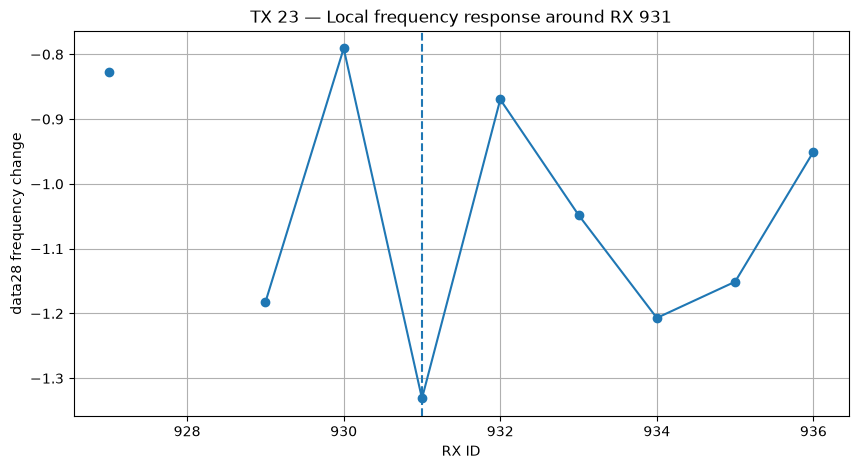

In [99]:
plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["rx_id"],
    plot_df["data28_freq_change"],
    marker="o"
)

plt.axvline(
    rx_target,
    linestyle="--"
)

plt.xlabel("RX ID")
plt.ylabel("data28 frequency change")
plt.title("TX 23 — Local frequency response around RX 931")
plt.grid(True)

plt.show()

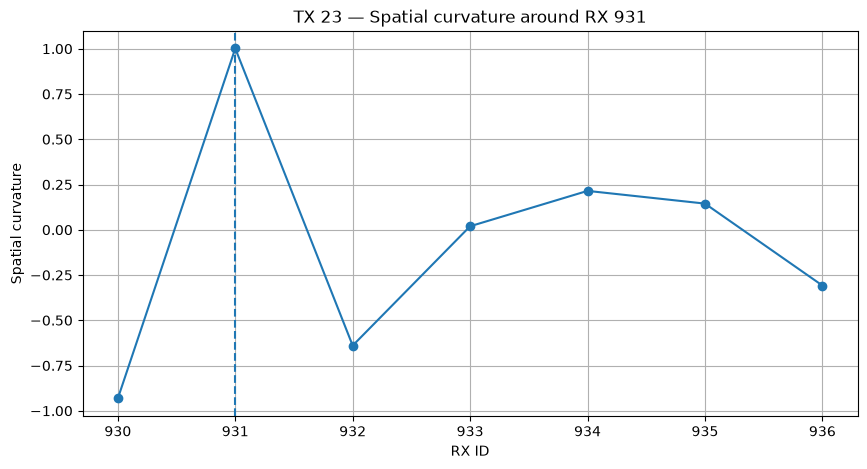

In [100]:
plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["rx_id"],
    plot_df["data28_spatial_curvature"],
    marker="o"
)

plt.axvline(
    rx_target,
    linestyle="--"
)

plt.xlabel("RX ID")
plt.ylabel("Spatial curvature")
plt.title("TX 23 — Spatial curvature around RX 931")
plt.grid(True)

plt.show()

In [101]:
tx_target = 23
rx_min = 927
rx_max = 936

region = (
    df_ml[
        (df_ml["tx_id"] == tx_target) &
        (df_ml["rx_id"].between(rx_min, rx_max))
    ]
    .sort_values(["rx_id", "frequency_hz"])
)

print(
    region[
        [
            "tx_id",
            "rx_id",
            "frequency_hz",
            "data_24",
            "data_28",
            "tx_rx_distance"
        ]
    ].to_string(index=False)
)

 tx_id  rx_id  frequency_hz  data_24  data_28  tx_rx_distance
    23    927          0.25  72.8668 -13.2700     6913.140477
    23    927          0.75 -59.9033 -13.8773     6913.140477
    23    927          1.75 160.9700 -14.7032     6913.140477
    23    928          0.25  72.4497 -13.3132     6998.375814
    23    928          0.75 -59.8232 -13.9116     6998.375814
    23    929          0.25  72.4872 -13.3153     7088.615450
    23    929          0.75 -59.4625 -13.9361     7088.615450
    23    929          1.75 165.5400 -15.0959     7088.615450
    23    930          0.25  69.7572 -13.3392     7169.272614
    23    930          0.75 -63.6439 -13.9612     7169.272614
    23    930          1.75 134.6390 -14.7246     7169.272614
    23    931          0.25  74.5987 -13.2695     7251.614648
    23    931          0.75 -61.2220 -13.9916     7251.614648
    23    931          1.75 154.0910 -15.1915     7251.614648
    23    932          0.25  71.4085 -13.3461     7330.985255
    23  

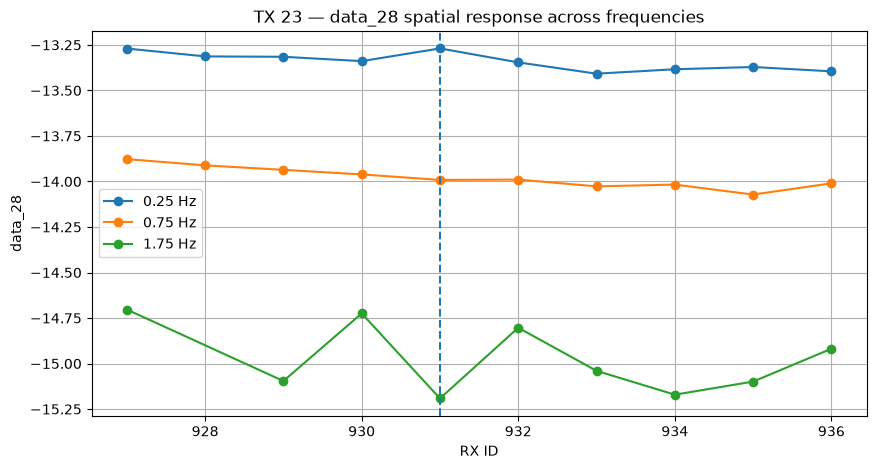

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for freq in [0.25, 0.75, 1.75]:

    temp = region[
        region["frequency_hz"] == freq
    ]

    plt.plot(
        temp["rx_id"],
        temp["data_28"],
        marker="o",
        label=f"{freq} Hz"
    )

plt.axvline(931, linestyle="--")

plt.xlabel("RX ID")
plt.ylabel("data_28")
plt.title("TX 23 — data_28 spatial response across frequencies")
plt.legend()
plt.grid(True)
plt.show()

In [104]:
geom_cols = (
    df_geom[
        [
            "tx_id",
            "rx_id",
            "frequency_hz",
            "data_28_geometry_residual"
        ]
    ]
)

region_geom = region.merge(
    geom_cols,
    on=["tx_id", "rx_id", "frequency_hz"],
    how="left"
)

In [106]:
# Select TX 23 and RX 927–936 directly from df_geom
region_geom = (
    df_geom[
        (df_geom["tx_id"] == 23) &
        (df_geom["rx_id"].between(927, 936))
    ]
    .sort_values(["rx_id", "frequency_hz"])
)

print(
    region_geom[
        [
            "tx_id",
            "rx_id",
            "frequency_hz",
            "data_28",
            "data_28_geometry_residual"
        ]
    ].to_string(index=False)
)

 tx_id  rx_id  frequency_hz  data_28  data_28_geometry_residual
    23    927          0.25 -13.2700                  -0.352057
    23    927          0.75 -13.8773                  -0.539211
    23    927          1.75 -14.7032                  -1.179296
    23    928          0.25 -13.3132                  -0.377298
    23    928          0.75 -13.9116                  -0.555029
    23    929          0.25 -13.3153                  -0.360621
    23    929          0.75 -13.9361                  -0.560206
    23    929          1.75 -15.0959                  -1.543194
    23    930          0.25 -13.3392                  -0.367940
    23    930          0.75 -13.9612                  -0.568243
    23    930          1.75 -14.7246                  -1.158894
    23    931          0.25 -13.2695                  -0.281504
    23    931          0.75 -13.9916                  -0.581419
    23    931          1.75 -15.1915                  -1.612672
    23    932          0.25 -13.3461    

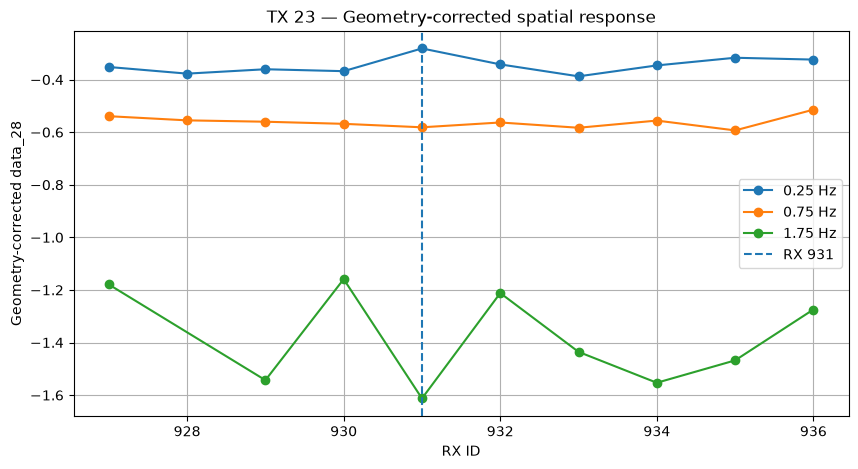

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for freq in [0.25, 0.75, 1.75]:

    temp = region_geom[
        region_geom["frequency_hz"] == freq
    ]

    plt.plot(
        temp["rx_id"],
        temp["data_28_geometry_residual"],
        marker="o",
        label=f"{freq} Hz"
    )

plt.axvline(
    931,
    linestyle="--",
    label="RX 931"
)

plt.xlabel("RX ID")
plt.ylabel("Geometry-corrected data_28")
plt.title("TX 23 — Geometry-corrected spatial response")
plt.legend()
plt.grid(True)
plt.show()

Target RX 931:
       rx_id  frequency_hz  data_28  data_28_geometry_residual
3055     931          0.25 -13.2695                  -0.281504
3266     931          0.25 -12.1607                  -0.349326
3611     931          0.25 -12.7062                  -0.325091
3717     931          0.25 -13.4828                  -0.195530
3826     931          0.25 -14.0575                  -0.224683
7481     931          0.75 -13.9916                  -0.581419
7684     931          0.75 -12.4142                  -0.214879
8021     931          0.75 -13.1078                  -0.322166
8135     931          0.75 -14.2827                  -0.564537
11188    931          1.75 -15.1915                  -1.612672
11282    931          1.75 -12.9424                  -0.286088
11440    931          1.75 -13.7828                  -0.679795

Nearest receivers to RX 931:
      rx_id  distance_to_931
3056    932        83.840384
3054    930        88.019373
3057    933       169.038457
3053    929       17

rx_id,928,929,930,931,932,933,934
frequency_hz,,,,,,,
0.25,-0.321872,-0.311131,-0.342665,-0.275227,-0.299575,-0.324196,-0.296209
0.75,-0.426086,-0.409553,-0.413981,-0.420750,-0.407848,-0.373190,-0.340565
1.75,-0.495014,-0.851756,-0.718986,-0.859518,-0.716348,-0.779041,-0.812591


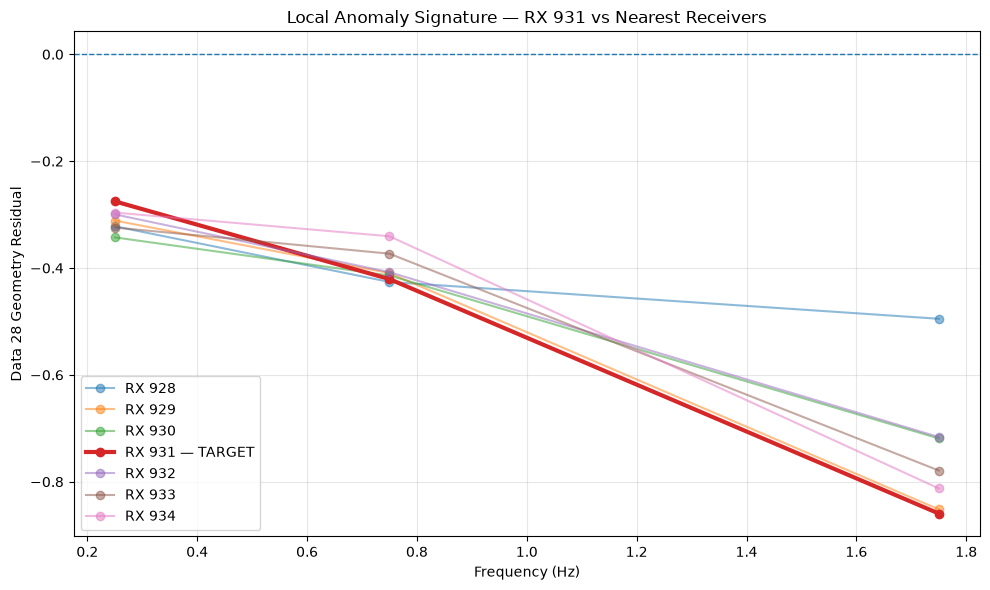

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Target receiver
target_rx = 931

# Work on geometry-corrected data
df_local = df_geom.copy()

# Make sure RX IDs are numeric
df_local["rx_id"] = pd.to_numeric(df_local["rx_id"], errors="coerce")

# Select target RX
target = df_local[df_local["rx_id"] == target_rx]

print("Target RX 931:")
print(target[[
    "rx_id",
    "frequency_hz",
    "data_28",
    "data_28_geometry_residual"
]])

# --------------------------------------------------
# Find nearest receivers using RX coordinates
# --------------------------------------------------

rx_locations = (
    df_local[["rx_id", "rx_x", "rx_y", "rx_z"]]
    .drop_duplicates("rx_id")
    .dropna()
)

target_loc = rx_locations[rx_locations["rx_id"] == target_rx].iloc[0]

rx_locations["distance_to_931"] = np.sqrt(
    (rx_locations["rx_x"] - target_loc["rx_x"])**2 +
    (rx_locations["rx_y"] - target_loc["rx_y"])**2 +
    (rx_locations["rx_z"] - target_loc["rx_z"])**2
)

neighbors = (
    rx_locations[rx_locations["rx_id"] != target_rx]
    .sort_values("distance_to_931")
    .head(6)
)

print("\nNearest receivers to RX 931:")
print(neighbors[["rx_id", "distance_to_931"]])

# --------------------------------------------------
# Compare geometry residual at each frequency
# --------------------------------------------------

comparison_ids = [target_rx] + neighbors["rx_id"].tolist()

comparison = df_local[
    df_local["rx_id"].isin(comparison_ids)
][[
    "rx_id",
    "frequency_hz",
    "data_28_geometry_residual"
]].copy()

# Pivot for easier comparison
comparison_pivot = comparison.pivot_table(
    index="frequency_hz",
    columns="rx_id",
    values="data_28_geometry_residual",
    aggfunc="mean"
)

print("\nGeometry-corrected local comparison:")
display(comparison_pivot)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

for rx in comparison_pivot.columns:
    if rx == target_rx:
        plt.plot(
            comparison_pivot.index,
            comparison_pivot[rx],
            marker="o",
            linewidth=3,
            label=f"RX {int(rx)} — TARGET"
        )
    else:
        plt.plot(
            comparison_pivot.index,
            comparison_pivot[rx],
            marker="o",
            alpha=0.5,
            label=f"RX {int(rx)}"
        )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Data 28 Geometry Residual")
plt.title("Local Anomaly Signature — RX 931 vs Nearest Receivers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [111]:
stats = (
    df_geom
    .groupby(["rx_id", "frequency_hz"])["data_28_geometry_residual"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        n="count"
    )
    .reset_index()
)

# Focus on RX 931 and its nearest receivers
local_rx = [928, 929, 930, 931, 932, 933, 934]

local_stats = stats[
    stats["rx_id"].isin(local_rx)
].sort_values(["frequency_hz", "rx_id"])

display(local_stats)

,rx_id,frequency_hz,mean,std,min,max,n
2781,928,0.25,-0.321872,0.080106,-0.377298,-0.204406,4
2784,929,0.25,-0.311131,0.071036,-0.364957,-0.193944,5
2787,930,0.25,-0.342665,0.035345,-0.367940,-0.283678,5
2790,931,0.25,-0.275227,0.065044,-0.349326,-0.195530,5
2793,932,0.25,-0.299575,0.062254,-0.342150,-0.190889,5
2796,933,0.25,-0.324196,0.049541,-0.387577,-0.258384,5
2799,934,0.25,-0.296209,0.058359,-0.346096,-0.220806,4
2782,928,0.75,-0.426086,0.181405,-0.587287,-0.197293,4
2785,929,0.75,-0.409553,0.156799,-0.560206,-0.209798,4
2788,930,0.75,-0.413981,0.167804,-0.568243,-0.214237,4


In [112]:
rx931_stats = local_stats[
    local_stats["rx_id"] == 931
]

print("RX 931 measurement variability:")
display(rx931_stats)

RX 931 measurement variability:


,rx_id,frequency_hz,mean,std,min,max,n
2790,931,0.25,-0.275227,0.065044,-0.349326,-0.195530,5
2791,931,0.75,-0.420750,0.181283,-0.581419,-0.214879,4
2792,931,1.75,-0.859518,0.681309,-1.612672,-0.286088,3


Local 1.75 Hz spatial response:


,rx_id,residual,rx_x,rx_y,rx_z
927,928,-0.495014,-60.0,-31279.0,3579.4
928,929,-0.851756,-76.0,-31189.0,3598.6
929,930,-0.718986,-17.0,-31108.0,3620.5
930,931,-0.859518,-34.0,-31026.0,3647.6
931,932,-0.716348,-57.0,-30947.0,3663.7
932,933,-0.779041,-65.0,-30864.0,3684.6
933,934,-0.812591,-66.0,-30777.0,3709.2


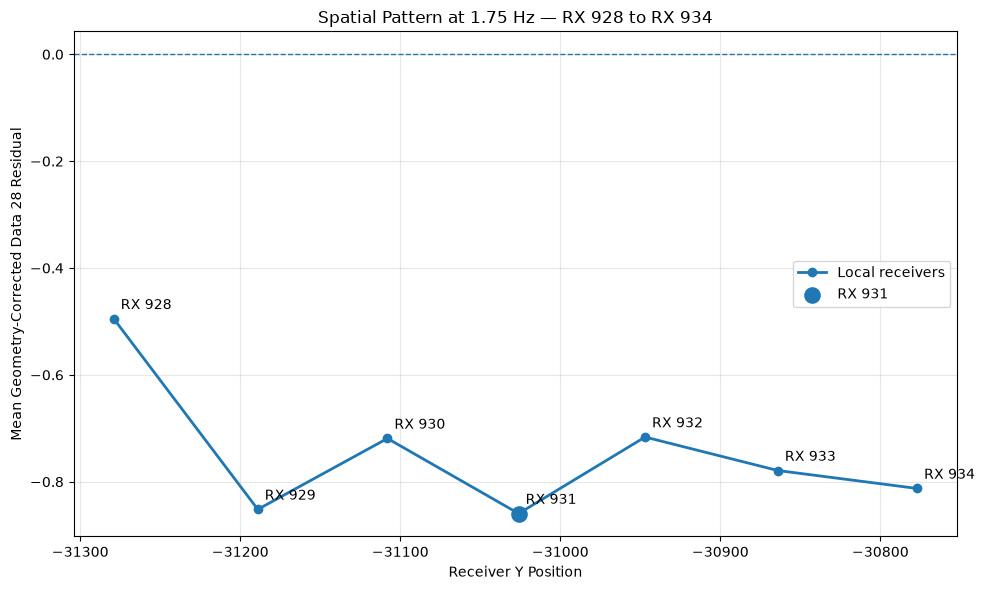

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Get 1.75 Hz geometry-corrected residuals
# --------------------------------------------------

df_175 = df_geom[
    df_geom["frequency_hz"] == 1.75
].copy()

# Average repeated measurements for each receiver
rx_175 = (
    df_175
    .groupby("rx_id")
    .agg(
        residual=("data_28_geometry_residual", "mean"),
        rx_x=("rx_x", "mean"),
        rx_y=("rx_y", "mean"),
        rx_z=("rx_z", "mean")
    )
    .reset_index()
)

# --------------------------------------------------
# 2. Focus on local receivers 928–934
# --------------------------------------------------

local_rx = [928, 929, 930, 931, 932, 933, 934]

local_175 = (
    rx_175[rx_175["rx_id"].isin(local_rx)]
    .sort_values("rx_y")
)

print("Local 1.75 Hz spatial response:")
display(local_175)

# --------------------------------------------------
# 3. Plot residual against receiver position
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    local_175["rx_y"],
    local_175["residual"],
    marker="o",
    linewidth=2,
    label="Local receivers"
)

# Highlight RX 931
target = local_175[local_175["rx_id"] == 931]

plt.scatter(
    target["rx_y"],
    target["residual"],
    s=120,
    zorder=5,
    label="RX 931"
)

# Label each receiver
for _, row in local_175.iterrows():
    plt.annotate(
        f"RX {int(row['rx_id'])}",
        (row["rx_y"], row["residual"]),
        xytext=(5, 7),
        textcoords="offset points"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Receiver Y Position")
plt.ylabel("Mean Geometry-Corrected Data 28 Residual")
plt.title("Spatial Pattern at 1.75 Hz — RX 928 to RX 934")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

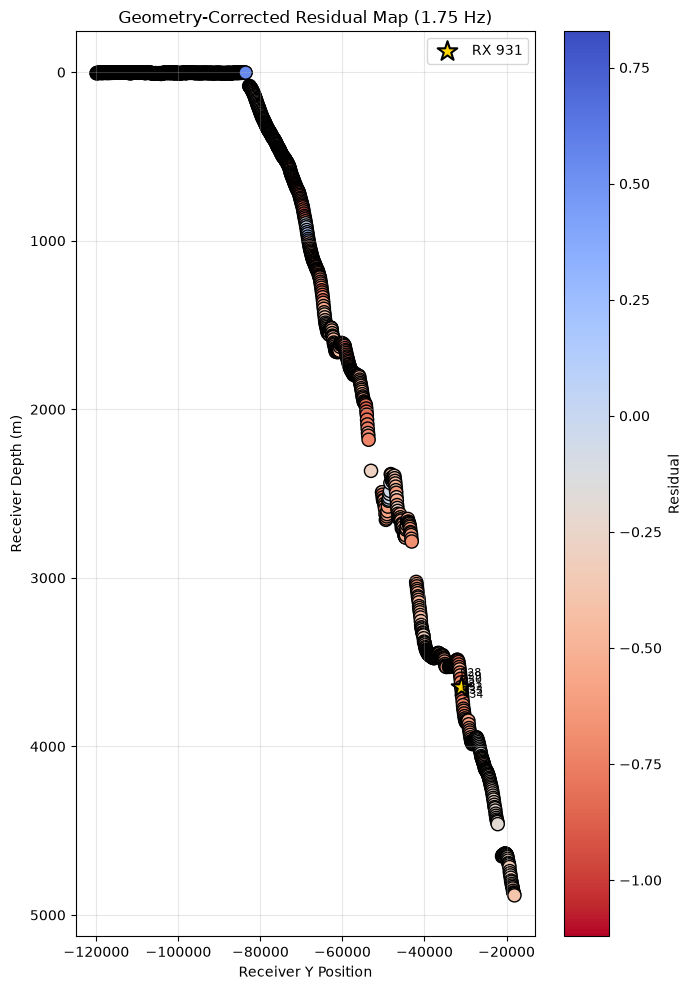

In [114]:
import matplotlib.pyplot as plt

# Average residual at each receiver for 1.75 Hz
df_map = (
    df_geom[df_geom["frequency_hz"] == 1.75]
    .groupby("rx_id")
    .agg(
        residual=("data_28_geometry_residual", "mean"),
        rx_y=("rx_y", "mean"),
        rx_z=("rx_z", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(7,10))

sc = plt.scatter(
    df_map["rx_y"],
    df_map["rx_z"],
    c=df_map["residual"],
    cmap="coolwarm_r",
    s=90,
    edgecolors="black"
)

# Highlight RX931
target = df_map[df_map["rx_id"] == 931]
plt.scatter(
    target["rx_y"],
    target["rx_z"],
    s=220,
    marker="*",
    color="gold",
    edgecolors="black",
    linewidth=1.5,
    label="RX 931"
)

for _, row in df_map.iterrows():
    if row["rx_id"] in [928,929,930,931,932,933,934]:
        plt.text(
            row["rx_y"]+8,
            row["rx_z"]+3,
            int(row["rx_id"]),
            fontsize=8
        )

plt.gca().invert_yaxis()     # Seafloor convention

plt.xlabel("Receiver Y Position")
plt.ylabel("Receiver Depth (m)")
plt.title("Geometry-Corrected Residual Map (1.75 Hz)")
plt.colorbar(sc, label="Residual")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [115]:
import numpy as np

# Local neighborhood around RX931
local_rx = [928,929,930,931,932,933,934]

local = df_map[df_map["rx_id"].isin(local_rx)].copy()

mean_local = local["residual"].mean()
std_local = local["residual"].std()

local["local_zscore"] = (
    local["residual"] - mean_local
) / std_local

display(local.sort_values("local_zscore"))

print(f"Neighborhood mean : {mean_local:.3f}")
print(f"Neighborhood std  : {std_local:.3f}")

,rx_id,residual,rx_y,rx_z,local_zscore
930,931,-0.859518,-31026.0,3647.6,-0.893231
928,929,-0.851756,-31189.0,3598.6,-0.831275
933,934,-0.812591,-30777.0,3709.2,-0.518672
932,933,-0.779041,-30864.0,3684.6,-0.250888
929,930,-0.718986,-31108.0,3620.5,0.228450
931,932,-0.716348,-30947.0,3663.7,0.249504
927,928,-0.495014,-31279.0,3579.4,2.016113


Neighborhood mean : -0.748
Neighborhood std  : 0.125


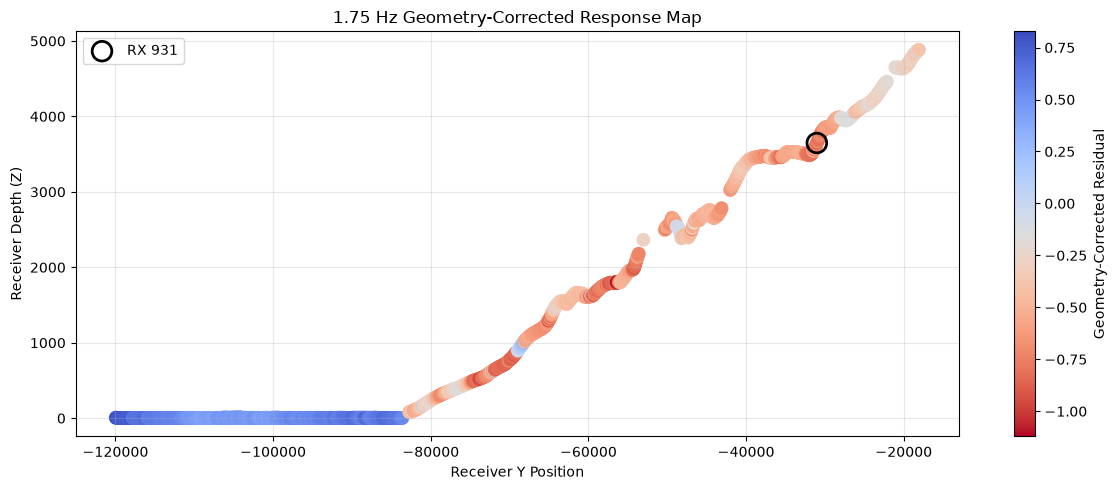

In [116]:
import matplotlib.pyplot as plt

# Mean residual for every receiver at 1.75 Hz
rx_map = (
    df_geom[df_geom["frequency_hz"] == 1.75]
    .groupby("rx_id")
    .agg(
        residual=("data_28_geometry_residual", "mean"),
        rx_y=("rx_y", "mean"),
        rx_z=("rx_z", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12,5))

sc = plt.scatter(
    rx_map["rx_y"],
    rx_map["rx_z"],
    c=rx_map["residual"],
    cmap="coolwarm_r",
    s=80
)

# Highlight RX 931
target = rx_map[rx_map["rx_id"] == 931]
plt.scatter(
    target["rx_y"],
    target["rx_z"],
    s=200,
    edgecolors="black",
    facecolors="none",
    linewidth=2,
    label="RX 931"
)

plt.colorbar(sc, label="Geometry-Corrected Residual")

plt.xlabel("Receiver Y Position")
plt.ylabel("Receiver Depth (Z)")
plt.title("1.75 Hz Geometry-Corrected Response Map")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [117]:
df_ml.shape
df_ml.columns
df_ml[feature_cols].isna().sum()

frequency_hz           0
data_24                0
data_28                0
stderr_24              0
stderr_28              0
tx_rx_distance         0
horizontal_distance    0
vertical_separation    0
response_24_abs        0
response_28_abs        0
response_ratio         0
response_difference    0
response_magnitude     0
dtype: int64

In [118]:
# ============================================
# ML STEP 1 — Clean feature set
# ============================================

ml_features = [
    "frequency_hz",
    "data_24",
    "data_28_geometry_residual",
    "stderr_24",
    "stderr_28",
    "response_ratio",
    "response_difference",
    "response_magnitude"
]

# Create ML dataframe
df_ml_clean = df_geom[["rx_id", "rx_x", "rx_y", "rx_z"] + ml_features].copy()

# Check missing values
print("Missing values:")
print(df_ml_clean[ml_features].isna().sum())

# Check dimensions
print("\nML dataset shape:")
print(df_ml_clean.shape)

# Preview
display(df_ml_clean.head())

Missing values:
frequency_hz                 0
data_24                      0
data_28_geometry_residual    0
stderr_24                    0
stderr_28                    0
response_ratio               0
response_difference          0
response_magnitude           0
dtype: int64

ML dataset shape:
(11729, 12)


,rx_id,rx_x,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,stderr_24,stderr_28,response_ratio,response_difference,response_magnitude
0,1,44,-119957,6.4,0.25,113.104,1.239979,1.71894,0.013029,9.807839,124.6360,113.690377
1,2,45,-119871,5.8,0.25,112.266,1.232582,1.71894,0.013029,9.712096,123.8254,112.859534
2,3,44,-119777,4.3,0.25,112.170,1.237441,1.71894,0.013029,9.689792,123.7461,112.765753
3,4,42,-119681,3.7,0.25,112.047,1.224133,1.71894,0.013029,9.649990,123.6581,112.647006
4,5,42,-119584,3.8,0.25,110.307,1.224527,1.71894,0.013029,9.482819,121.9393,110.918640


In [119]:
from sklearn.preprocessing import StandardScaler

# Features for the corrected ML model
X = df_ml_clean[ml_features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature means:")
display(X.mean())

print("\nScaled feature means:")
print(X_scaled.mean(axis=0))

print("\nScaled feature standard deviations:")
print(X_scaled.std(axis=0))

Original feature means:


frequency_hz                 8.600691e-01
data_24                      5.492508e+01
data_28_geometry_residual    2.520128e-16
stderr_24                    4.956146e+00
stderr_28                    3.748128e-02
response_ratio               7.132521e+00
response_difference          6.789540e+01
response_magnitude           9.338925e+01
dtype: float64


Scaled feature means:
[ 1.55084782e-16  0.00000000e+00  1.93855977e-17 -3.39247960e-17
  2.42319971e-17 -2.13241575e-16 -7.75423908e-17  2.61705569e-16]

Scaled feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [120]:
from sklearn.ensemble import IsolationForest

# ============================================
# ML STEP 3 — Isolation Forest
# ============================================

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

# Train
iso.fit(X_scaled)

# Predictions
df_ml_clean["if_prediction"] = iso.predict(X_scaled)

# Raw anomaly score
df_ml_clean["if_score"] = iso.decision_function(X_scaled)

# Convert so HIGHER = MORE ANOMALOUS
df_ml_clean["if_anomaly_score"] = -df_ml_clean["if_score"]

# Binary anomaly label
df_ml_clean["if_anomaly"] = (
    df_ml_clean["if_prediction"] == -1
)

print("Isolation Forest complete!")

print("\nNumber of anomalies:")
print(df_ml_clean["if_anomaly"].sum())

print("\nPercentage flagged:")
print(
    df_ml_clean["if_anomaly"].mean() * 100,
    "%"
)

Isolation Forest complete!

Number of anomalies:
587

Percentage flagged:
5.00468923181857 %


In [121]:
top_if = (
    df_ml_clean
    .sort_values("if_anomaly_score", ascending=False)
    .head(20)
)

display(
    top_if[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "stderr_24",
            "stderr_28",
            "response_ratio",
            "response_difference",
            "response_magnitude",
            "if_anomaly_score",
            "if_anomaly"
        ]
    ]
)

,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,stderr_24,stderr_28,response_ratio,response_difference,response_magnitude,if_anomaly_score,if_anomaly
11076,770,-46446,2619.6,1.75,-179.0370,-1.123041,25.9595,0.195091,12.059287,-164.1906,179.651504,0.126664,True
10719,742,-48914,2577.3,1.75,-176.0550,-1.286965,25.9495,0.195017,12.088701,-161.4914,176.656337,0.123215,True
8418,1062,-18720,4815.6,0.75,-179.7730,-1.159968,26.6060,0.199863,12.118412,-164.9383,180.384034,0.123124,True
7541,751,-48023,2406.7,0.75,-171.0930,-0.538488,28.3515,0.212715,11.467820,-156.1736,171.742258,0.110393,True
7182,921,-31933,3486.5,0.75,-174.7840,-0.628222,27.4551,0.206121,11.603609,-159.7211,175.431860,0.110313,True
7757,1004,-24515,4167.5,0.75,-175.9700,-1.121295,26.2266,0.197063,11.745585,-160.9882,176.606612,0.109800,True
8417,1060,-18882,4796.1,0.75,-176.2970,-1.044751,25.3436,0.190539,11.954203,-161.5493,176.912766,0.104720,True
10391,509,-71904,641.4,1.75,22.0601,-1.604113,28.1587,0.211298,1.479263,36.9730,26.627854,0.097729,True
7180,919,-32136,3488.8,0.75,-166.9300,-0.561336,26.5545,0.199483,11.147618,-151.9555,167.600300,0.097036,True
6488,553,-68097,1022.0,0.75,-176.1870,-0.953904,23.9513,0.180229,11.871159,-161.3454,176.811007,0.095874,True


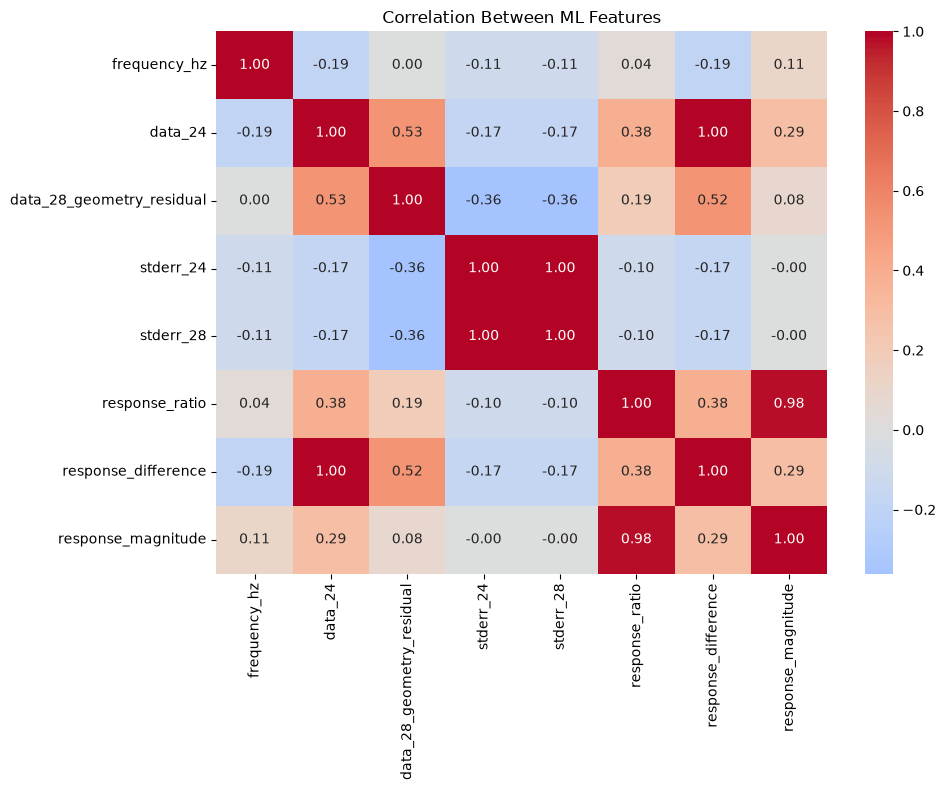

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_ml = df_ml_clean[ml_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_ml,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between ML Features")
plt.tight_layout()
plt.show()

In [123]:
print(
    corr_ml["data_24"]
    .sort_values(ascending=False)
)

data_24                      1.000000
response_difference          0.999955
data_28_geometry_residual    0.527862
response_ratio               0.384516
response_magnitude           0.290388
stderr_24                   -0.172812
stderr_28                   -0.172914
frequency_hz                -0.187784
Name: data_24, dtype: float64


In [124]:
ml_features_v2 = [
    "frequency_hz",
    "data_24",
    "data_28_geometry_residual",
    "stderr_24",
    "stderr_28",
    "response_ratio",
    "response_magnitude"
]

X_v2 = df_ml_clean[ml_features_v2].copy()

print("Final ML features:")
print(ml_features_v2)

print("\nFeature count:", len(ml_features_v2))

print("\nCorrelation with data_24:")
display(
    X_v2.corr()["data_24"]
    .sort_values(ascending=False)
)

Final ML features:
['frequency_hz', 'data_24', 'data_28_geometry_residual', 'stderr_24', 'stderr_28', 'response_ratio', 'response_magnitude']

Feature count: 7

Correlation with data_24:


data_24                      1.000000
data_28_geometry_residual    0.527862
response_ratio               0.384516
response_magnitude           0.290388
stderr_24                   -0.172812
stderr_28                   -0.172914
frequency_hz                -0.187784
Name: data_24, dtype: float64

In [125]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# ============================================
# ML STEP 5 — Clean Isolation Forest
# ============================================

scaler_v2 = StandardScaler()

X_v2_scaled = scaler_v2.fit_transform(X_v2)

iso_v2 = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_v2.fit(X_v2_scaled)

df_ml_clean["if_score_v2"] = -iso_v2.decision_function(X_v2_scaled)

df_ml_clean["if_anomaly_v2"] = (
    iso_v2.predict(X_v2_scaled) == -1
)

print("Clean Isolation Forest complete!")

print(
    "Anomalies:",
    df_ml_clean["if_anomaly_v2"].sum()
)

print(
    "Percentage:",
    df_ml_clean["if_anomaly_v2"].mean() * 100
)

Clean Isolation Forest complete!
Anomalies: 587
Percentage: 5.00468923181857


In [126]:
top_if_v2 = (
    df_ml_clean
    .sort_values("if_score_v2", ascending=False)
    .head(20)
)

display(
    top_if_v2[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "stderr_24",
            "stderr_28",
            "response_ratio",
            "response_magnitude",
            "if_score_v2",
            "if_anomaly_v2"
        ]
    ]
)

,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,stderr_24,stderr_28,response_ratio,response_magnitude,if_score_v2,if_anomaly_v2
10391,509,-71904,641.4,1.75,22.0601,-1.604113,28.1587,0.211298,1.479263,26.627854,0.110154,True
10719,742,-48914,2577.3,1.75,-176.0550,-1.286965,25.9495,0.195017,12.088701,176.656337,0.109934,True
10390,506,-72149,627.1,1.75,27.0625,-1.566352,27.9835,0.210009,1.813427,30.904478,0.108816,True
11076,770,-46446,2619.6,1.75,-179.0370,-1.123041,25.9595,0.195091,12.059287,179.651504,0.106565,True
8418,1062,-18720,4815.6,0.75,-179.7730,-1.159968,26.6060,0.199863,12.118412,180.384034,0.100308,True
10206,502,-72469,605.8,1.75,-62.2934,-1.301658,27.9100,0.209469,4.262234,63.984934,0.099525,True
10313,542,-69030,884.5,1.75,55.5100,-1.533863,28.2326,0.211841,3.768116,57.431500,0.099094,True
10393,511,-71738,653.4,1.75,72.1357,-1.671916,28.1703,0.211383,4.826228,73.667904,0.098945,True
10394,512,-71653,657.9,1.75,70.3695,-1.646411,27.6855,0.207817,4.721676,71.930389,0.097656,True
8347,1001,-24770,4149.7,0.75,170.1340,-1.116350,28.8115,0.216094,11.257982,170.803863,0.097459,True


In [127]:
from sklearn.neighbors import LocalOutlierFactor

# ============================================
# ML STEP 6 — Local Outlier Factor
# ============================================

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False
)

# Fit + predict
lof_labels = lof.fit_predict(X_v2_scaled)

# LOF score:
# sklearn's negative_outlier_factor_ is MORE NEGATIVE for anomalies
df_ml_clean["lof_score"] = -lof.negative_outlier_factor_

df_ml_clean["lof_anomaly"] = (
    lof_labels == -1
)

print("LOF complete!")

print("\nNumber of anomalies:")
print(df_ml_clean["lof_anomaly"].sum())

print("\nPercentage flagged:")
print(
    df_ml_clean["lof_anomaly"].mean() * 100,
    "%"
)

LOF complete!

Number of anomalies:
587

Percentage flagged:
5.00468923181857 %


In [128]:
top_lof = (
    df_ml_clean
    .sort_values("lof_score", ascending=False)
    .head(20)
)

display(
    top_lof[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "stderr_24",
            "stderr_28",
            "response_ratio",
            "response_magnitude",
            "if_score_v2",
            "lof_score",
            "lof_anomaly"
        ]
    ]
)

,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,stderr_24,stderr_28,response_ratio,response_magnitude,if_score_v2,lof_score,lof_anomaly
11687,1041,-20430,4635.8,1.75,106.2060,0.752994,1.71894,0.013029,9.237071,106.826560,-0.166593,5.561605,True
11688,1042,-20349,4635.8,1.75,109.4830,0.764504,1.71894,0.013029,9.565593,110.079638,-0.168841,4.670702,True
2403,724,-53036,2365.0,0.25,146.3260,-0.400245,3.91731,0.029687,12.480894,146.794927,-0.074393,4.177831,True
11689,1043,-20267,4635.2,1.75,113.1470,0.776593,1.71894,0.013029,9.933279,113.718915,-0.165812,3.870972,True
11690,1044,-20186,4638.8,1.75,116.8310,0.786185,1.71894,0.013029,10.305374,117.379759,-0.159410,3.718907,True
2421,761,-47105,2440.0,0.25,142.5030,-0.326814,3.11828,0.023633,11.573754,143.033930,-0.110312,3.450710,True
11686,1040,-20511,4638.8,1.75,103.1860,0.743063,1.71894,0.013029,8.936251,103.830061,-0.166953,3.439020,True
5380,228,-99045,4.2,0.75,139.9830,0.470925,2.57279,0.019500,11.356726,140.524626,-0.125400,3.371035,True
1849,612,-63393,1541.0,0.25,150.0680,-0.295639,5.69177,0.043125,12.602602,150.539689,-0.058040,2.974029,True
5379,227,-99136,4.4,0.75,135.6560,0.477169,2.48797,0.018857,10.986160,136.216816,-0.139094,2.853303,True


In [129]:
# ============================================
# ML STEP 7 — IF + LOF AGREEMENT
# ============================================

df_ml_clean["ml_agreement"] = (
    df_ml_clean["if_anomaly_v2"].astype(int)
    +
    df_ml_clean["lof_anomaly"].astype(int)
)

print("Agreement counts:")
print(
    df_ml_clean["ml_agreement"]
    .value_counts()
    .sort_index()
)

Agreement counts:
ml_agreement
0    10584
1     1116
2       29
Name: count, dtype: int64


In [130]:
both_anomalies = (
    df_ml_clean[
        df_ml_clean["ml_agreement"] == 2
    ]
    .sort_values(
        ["frequency_hz", "lof_score"],
        ascending=[True, False]
    )
)

print(
    "Observations flagged by BOTH models:",
    len(both_anomalies)
)

display(
    both_anomalies[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "response_ratio",
            "response_magnitude",
            "if_score_v2",
            "lof_score",
            "ml_agreement"
        ]
    ].head(50)
)

Observations flagged by BOTH models: 29


,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,response_ratio,response_magnitude,if_score_v2,lof_score,ml_agreement
1416,489,-73348,543.3,0.25,112.159000,-0.432331,8.172829,112.995456,0.056238,1.775545,2
1842,605,-63978,1503.2,0.25,159.365000,-0.326161,13.740257,159.786502,0.017694,1.442363,2
1417,490,-73278,547.4,0.25,107.832000,-0.368952,7.887357,108.695217,0.021406,1.426247,2
3820,924,-31623,3514.1,0.25,-39.972400,-0.350378,2.804943,42.436720,0.033839,1.422123,2
1840,603,-64133,1485.9,0.25,161.180000,-0.328680,14.014799,161.589785,0.029514,1.404063,2
4522,244,-97606,2.8,0.75,142.504000,0.963870,10.406005,143.160492,0.011556,1.844668,2
5982,436,-77652,357.5,0.75,-8.362290,-0.243305,0.667547,15.061578,0.012971,1.778354,2
5900,502,-72469,605.8,0.75,0.278494,-0.939023,0.019891,14.003769,0.062305,1.736968,2
4513,234,-98499,4.2,0.75,151.780000,0.796121,11.015553,152.404137,0.016178,1.733385,2
5906,511,-71738,653.4,0.75,6.243290,-0.826581,0.443759,15.392149,0.048157,1.663667,2


In [131]:
receiver_ml_summary = (
    df_ml_clean
    .groupby("rx_id")
    .agg(
        total_observations=("rx_id", "size"),
        if_anomalies=("if_anomaly_v2", "sum"),
        lof_anomalies=("lof_anomaly", "sum"),
        both_anomalies=("ml_agreement", lambda x: (x == 2).sum()),
        mean_if_score=("if_score_v2", "mean"),
        max_if_score=("if_score_v2", "max"),
        mean_lof_score=("lof_score", "mean"),
        max_lof_score=("lof_score", "max"),
        mean_geometry_residual=(
            "data_28_geometry_residual",
            "mean"
        )
    )
    .reset_index()
)

receiver_ml_summary["anomaly_fraction"] = (
    receiver_ml_summary["both_anomalies"]
    / receiver_ml_summary["total_observations"]
)

receiver_ml_summary = receiver_ml_summary.sort_values(
    ["both_anomalies", "anomaly_fraction", "max_lof_score"],
    ascending=False
)

display(
    receiver_ml_summary.head(30)
)

,rx_id,total_observations,if_anomalies,lof_anomalies,both_anomalies,mean_if_score,max_if_score,mean_lof_score,max_lof_score,mean_geometry_residual,anomaly_fraction
435,436,4,1,2,1,-0.065134,0.012971,1.402944,1.778354,-0.181604,0.250000
510,511,7,2,1,1,-0.076186,0.098945,1.164725,1.663667,-0.604754,0.142857
508,509,7,2,2,1,-0.076187,0.110154,1.159513,1.605819,-0.535857,0.142857
503,504,8,1,2,1,-0.082179,0.070370,1.206416,1.803164,-0.537922,0.125000
501,502,8,3,1,1,-0.034890,0.099525,1.154453,1.736968,-0.576795,0.125000
505,506,8,1,2,1,-0.076776,0.108816,1.178010,1.661029,-0.569667,0.125000
506,507,8,1,2,1,-0.085723,0.035663,1.198325,1.641439,-0.520775,0.125000
499,500,8,1,1,1,-0.074581,0.091239,1.137037,1.636213,-0.577688,0.125000
498,499,8,4,1,1,-0.053919,0.072644,1.119849,1.621055,-0.541599,0.125000
502,503,8,1,2,1,-0.074035,0.050874,1.152216,1.550739,-0.529852,0.125000


In [134]:
import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        if "if_score_v2" in cols or "lof_score" in cols:
            print("\nDATAFRAME:", name)
            print("Shape:", obj.shape)
            print(
                "ML columns:",
                [
                    c for c in obj.columns
                    if "score" in c.lower()
                    or "anomaly" in c.lower()
                ]
            )


DATAFRAME: df_ml_clean
Shape: (11729, 21)
ML columns: ['if_score', 'if_anomaly_score', 'if_anomaly', 'if_score_v2', 'if_anomaly_v2', 'lof_score', 'lof_anomaly']

DATAFRAME: top_if_v2
Shape: (20, 18)
ML columns: ['if_score', 'if_anomaly_score', 'if_anomaly', 'if_score_v2', 'if_anomaly_v2']

DATAFRAME: top_lof
Shape: (20, 20)
ML columns: ['if_score', 'if_anomaly_score', 'if_anomaly', 'if_score_v2', 'if_anomaly_v2', 'lof_score', 'lof_anomaly']

DATAFRAME: both_anomalies
Shape: (29, 21)
ML columns: ['if_score', 'if_anomaly_score', 'if_anomaly', 'if_score_v2', 'if_anomaly_v2', 'lof_score', 'lof_anomaly']


In [135]:
import numpy as np
import pandas as pd

# Use the complete ML dataframe
df_val = df_ml_clean.copy()

print("Shape:", df_val.shape)

print("\nRequired columns:")
required_cols = [
    "rx_id",
    "rx_y",
    "rx_z",
    "frequency_hz",
    "data_24",
    "data_28_geometry_residual",
    "response_ratio",
    "response_magnitude",
    "if_score_v2",
    "if_anomaly_v2",
    "lof_score",
    "lof_anomaly"
]

for col in required_cols:
    print(col, "→", col in df_val.columns)

Shape: (11729, 21)

Required columns:
rx_id → True
rx_y → True
rx_z → True
frequency_hz → True
data_24 → True
data_28_geometry_residual → True
response_ratio → True
response_magnitude → True
if_score_v2 → True
if_anomaly_v2 → True
lof_score → True
lof_anomaly → True


In [136]:
# Convert anomaly flags to integers
df_val["if_flag"] = df_val["if_anomaly_v2"].astype(int)
df_val["lof_flag"] = df_val["lof_anomaly"].astype(int)

# 0 = neither
# 1 = one method
# 2 = both methods
df_val["ml_agreement"] = (
    df_val["if_flag"] +
    df_val["lof_flag"]
)

print(df_val["ml_agreement"].value_counts().sort_index())

ml_agreement
0    10584
1     1116
2       29
Name: count, dtype: int64


In [137]:
freq_summary = (
    df_val.groupby("rx_id")
    .agg(
        total_frequencies=("frequency_hz", "nunique"),
        anomalous_frequencies=(
            "ml_agreement",
            lambda x: (x >= 1).sum()
        ),
        strong_anomalies=(
            "ml_agreement",
            lambda x: (x == 2).sum()
        )
    )
)

freq_summary["frequency_consistency"] = (
    freq_summary["anomalous_frequencies"]
    / freq_summary["total_frequencies"]
)

print(freq_summary.sort_values(
    "frequency_consistency",
    ascending=False
).head(30))

       total_frequencies  anomalous_frequencies  strong_anomalies  \
rx_id                                                               
1002                   3                      5                 0   
489                    3                      5                 1   
490                    3                      5                 1   
527                    3                      5                 0   
675                    3                      5                 0   
485                    3                      5                 0   
487                    3                      5                 0   
742                    3                      4                 1   
741                    3                      4                 0   
1004                   3                      4                 0   
925                    3                      4                 0   
1001                   3                      4                 0   
1043                   3          

In [138]:
receiver_summary = (
    df_val.groupby("rx_id")
    .agg(
        rx_y=("rx_y", "first"),
        rx_z=("rx_z", "first"),
        anomaly_count=(
            "ml_agreement",
            lambda x: (x >= 1).sum()
        ),
        strong_anomaly_count=(
            "ml_agreement",
            lambda x: (x == 2).sum()
        )
    )
    .reset_index()
)

# Sort spatially along the survey
receiver_summary = receiver_summary.sort_values(
    "rx_y"
).reset_index(drop=True)

# Binary receiver-level anomaly
receiver_summary["receiver_anomaly"] = (
    receiver_summary["anomaly_count"] > 0
).astype(int)

print(receiver_summary.head())

   rx_id    rx_y  rx_z  anomaly_count  strong_anomaly_count  receiver_anomaly
0      1 -119957   6.4              3                     0                 1
1      2 -119871   5.8              3                     0                 1
2      3 -119777   4.3              2                     0                 1
3      4 -119681   3.7              1                     0                 1
4      5 -119584   3.8              0                     0                 0


In [139]:
window = 3

spatial_scores = []

for i in range(len(receiver_summary)):

    start = max(0, i - window)
    end = min(
        len(receiver_summary),
        i + window + 1
    )

    neighbors = receiver_summary.iloc[start:end]

    # Exclude current receiver
    neighbors = neighbors.drop(
        receiver_summary.index[i]
    )

    if len(neighbors) == 0:
        score = 0
    else:
        score = neighbors["receiver_anomaly"].mean()

    spatial_scores.append(score)

receiver_summary["spatial_consistency"] = spatial_scores

print(
    receiver_summary
    .sort_values(
        "spatial_consistency",
        ascending=False
    )
    .head(30)
)

      rx_id    rx_y    rx_z  anomaly_count  strong_anomaly_count  \
1050   1051  -19615  4678.0              3                     0   
1069   1070  -18069  4883.6              2                     0   
419     420  -79041   293.0              2                     0   
420     421  -78952   297.1              1                     0   
421     422  -78863   302.0              1                     0   
422     423  -78774   306.8              2                     0   
423     424  -78682   311.8              2                     0   
394     395  -81435   139.4              0                     0   
398     399  -81063   165.9              1                     0   
399     400  -80965   172.0              1                     0   
400     401  -80866   179.4              2                     0   
50       51 -115006     2.4              1                     0   
51       52 -114908     2.9              1                     0   
52       53 -114811     3.1              2      

In [140]:
df_val = df_val.merge(
    freq_summary[
        [
            "total_frequencies",
            "anomalous_frequencies",
            "strong_anomalies",
            "frequency_consistency"
        ]
    ],
    left_on="rx_id",
    right_index=True,
    how="left"
)

df_val = df_val.merge(
    receiver_summary[
        [
            "rx_id",
            "spatial_consistency"
        ]
    ],
    on="rx_id",
    how="left"
)

print(df_val.shape)

(11729, 28)


In [141]:
df_val["ml_component"] = (
    df_val["ml_agreement"] / 2
)

df_val["anomaly_confidence"] = (
    0.4 * df_val["ml_component"]
    + 0.3 * df_val["spatial_consistency"]
    + 0.3 * df_val["frequency_consistency"]
)

In [142]:
df_val["confidence_level"] = pd.cut(
    df_val["anomaly_confidence"],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [143]:
validated = (
    df_val[
        df_val["ml_agreement"] >= 1
    ]
    .sort_values(
        "anomaly_confidence",
        ascending=False
    )
)

cols = [
    "rx_id",
    "rx_y",
    "rx_z",
    "frequency_hz",
    "data_24",
    "data_28_geometry_residual",
    "response_ratio",
    "response_magnitude",
    "if_score_v2",
    "lof_score",
    "ml_agreement",
    "spatial_consistency",
    "frequency_consistency",
    "anomaly_confidence",
    "confidence_level"
]

validated[cols].head(30)

,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,response_ratio,response_magnitude,if_score_v2,lof_score,ml_agreement,spatial_consistency,frequency_consistency,anomaly_confidence,confidence_level
1417,490,-73278,547.4,0.25,107.83200,-0.368952,7.887357,108.695217,0.021406,1.426247,2,1.0,1.666667,1.2,High
1416,489,-73348,543.3,0.25,112.15900,-0.432331,8.172829,112.995456,0.056238,1.775545,2,1.0,1.666667,1.2,High
10719,742,-48914,2577.3,1.75,-176.05500,-1.286965,12.088701,176.656337,0.109934,1.589920,2,1.0,1.333333,1.1,High
5897,499,-72676,589.7,0.75,-7.74999,-0.771375,0.562490,15.808087,0.024266,1.621055,2,1.0,1.333333,1.1,High
11394,1002,-24686,4154.3,1.75,-172.86800,-0.714274,12.349920,173.433778,0.001063,0.994234,1,1.0,1.666667,1.0,High
6983,675,-57689,1774.2,0.75,-167.29000,-0.899598,11.147465,167.961764,0.074470,1.117447,1,1.0,1.666667,1.0,High
10194,490,-73278,547.4,1.75,-106.14300,-1.368584,7.316271,107.129887,0.003382,1.061159,1,1.0,1.666667,1.0,High
10129,490,-73278,547.4,1.75,-18.95580,-0.663352,1.308307,23.858912,0.029464,1.034002,1,1.0,1.666667,1.0,High
5814,489,-73348,543.3,0.75,29.93940,-0.234928,2.145117,33.032795,-0.056881,1.755268,1,1.0,1.666667,1.0,High
5883,485,-73620,531.0,0.75,-36.19420,-0.610591,2.714104,38.572767,-0.140942,1.409720,1,1.0,1.666667,1.0,High


In [144]:
# ============================================================
# STEP 1: STRONG ML ANOMALIES
# ============================================================

df_anomaly = df_ml_clean.copy()

# Both Isolation Forest + LOF agree
df_anomaly = df_anomaly[
    (df_anomaly["if_anomaly_v2"] == 1) &
    (df_anomaly["lof_anomaly"] == 1)
].copy()

print("Strong anomaly observations:", len(df_anomaly))

display(
    df_anomaly[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "response_ratio",
            "response_magnitude",
            "if_score_v2",
            "lof_score"
        ]
    ].sort_values("lof_score", ascending=False).head(30)
)

Strong anomaly observations: 29


,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,response_ratio,response_magnitude,if_score_v2,lof_score
4522,244,-97606,2.8,0.75,142.504000,0.963870,10.406005,143.160492,0.011556,1.844668
10208,504,-72312,615.3,1.75,-114.997000,-1.320833,7.841382,115.928357,0.070370,1.803164
5982,436,-77652,357.5,0.75,-8.362290,-0.243305,0.667547,15.061578,0.012971,1.778354
1416,489,-73348,543.3,0.25,112.159000,-0.432331,8.172829,112.995456,0.056238,1.775545
5900,502,-72469,605.8,0.75,0.278494,-0.939023,0.019891,14.003769,0.062305,1.736968
4513,234,-98499,4.2,0.75,151.780000,0.796121,11.015553,152.404137,0.016178,1.733385
5906,511,-71738,653.4,0.75,6.243290,-0.826581,0.443759,15.392149,0.048157,1.663667
10204,500,-72611,595.4,1.75,-120.168000,-1.512707,8.120831,121.075655,0.091239,1.636213
5897,499,-72676,589.7,0.75,-7.749990,-0.771375,0.562490,15.808087,0.024266,1.621055
10209,505,-72230,620.7,1.75,-105.465000,-1.275671,7.205813,106.475733,0.057568,1.612085


In [145]:
# ============================================================
# STEP 2: RECEIVER-LEVEL ANOMALY SUMMARY
# ============================================================

rx_summary = (
    df_anomaly
    .groupby("rx_id")
    .agg(
        anomaly_observations=("rx_id", "size"),
        frequencies=("frequency_hz", "nunique"),
        max_lof=("lof_score", "max"),
        max_if=("if_score_v2", "max"),
        mean_geometry_residual=("data_28_geometry_residual", "mean"),
        mean_response_magnitude=("response_magnitude", "mean"),
        rx_y=("rx_y", "first"),
        rx_z=("rx_z", "first")
    )
    .reset_index()
)

rx_summary["frequency_persistence"] = (
    rx_summary["frequencies"] /
    df_ml_clean["frequency_hz"].nunique()
)

rx_summary = rx_summary.sort_values(
    ["frequencies", "max_lof"],
    ascending=[False, False]
)

display(rx_summary)

,rx_id,anomaly_observations,frequencies,max_lof,max_if,mean_geometry_residual,mean_response_magnitude,rx_y,rx_z,frequency_persistence
1,244,1,1,1.844668,0.011556,0.963870,143.160492,-97606,2.8,0.333333
10,504,1,1,1.803164,0.070370,-1.320833,115.928357,-72312,615.3,0.333333
2,436,1,1,1.778354,0.012971,-0.243305,15.061578,-77652,357.5,0.333333
4,489,1,1,1.775545,0.056238,-0.432331,112.995456,-73348,543.3,0.333333
8,502,1,1,1.736968,0.062305,-0.939023,14.003769,-72469,605.8,0.333333
0,234,1,1,1.733385,0.016178,0.796121,152.404137,-98499,4.2,0.333333
15,511,1,1,1.663667,0.048157,-0.826581,15.392149,-71738,653.4,0.333333
7,500,1,1,1.636213,0.091239,-1.512707,121.075655,-72611,595.4,0.333333
6,499,1,1,1.621055,0.024266,-0.771375,15.808087,-72676,589.7,0.333333
11,505,1,1,1.612085,0.057568,-1.275671,106.475733,-72230,620.7,0.333333


In [146]:
# ============================================================
# STEP 4: SORT ANOMALOUS RECEIVERS SPATIALLY
# ============================================================

rx_summary_sorted = rx_summary.sort_values("rx_y")

display(
    rx_summary_sorted[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "anomaly_observations",
            "frequencies",
            "frequency_persistence",
            "max_lof",
            "max_if"
        ]
    ]
)

,rx_id,rx_y,rx_z,anomaly_observations,frequencies,frequency_persistence,max_lof,max_if
0,234,-98499,4.2,1,1,0.333333,1.733385,0.016178
1,244,-97606,2.8,1,1,0.333333,1.844668,0.011556
2,436,-77652,357.5,1,1,0.333333,1.778354,0.012971
3,481,-73916,519.7,1,1,0.333333,1.479425,0.043135
4,489,-73348,543.3,1,1,0.333333,1.775545,0.056238
5,490,-73278,547.4,1,1,0.333333,1.426247,0.021406
6,499,-72676,589.7,1,1,0.333333,1.621055,0.024266
7,500,-72611,595.4,1,1,0.333333,1.636213,0.091239
8,502,-72469,605.8,1,1,0.333333,1.736968,0.062305
9,503,-72392,610.5,1,1,0.333333,1.550739,0.050874


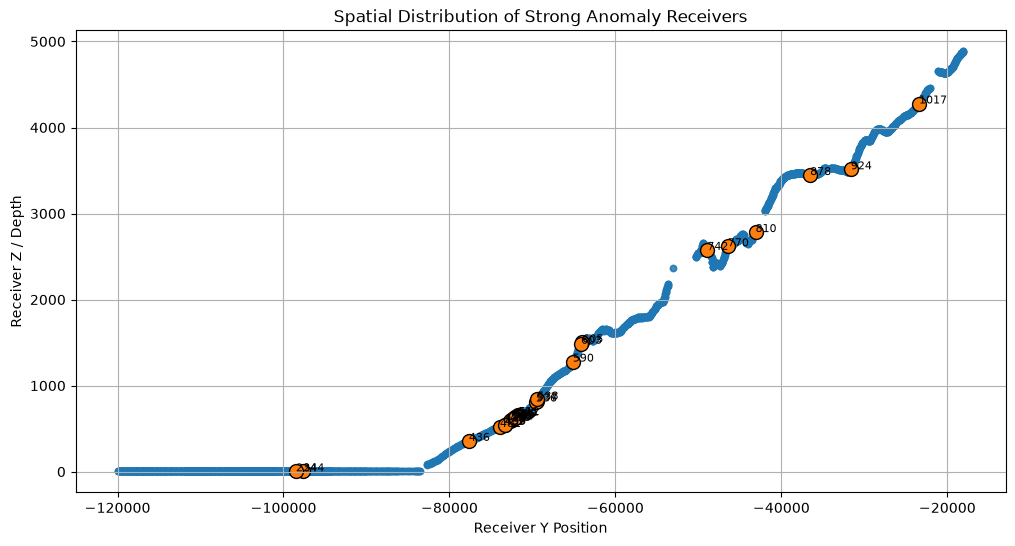

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    df_ml_clean["rx_y"],
    df_ml_clean["rx_z"],
    s=20,
    alpha=0.25
)

plt.scatter(
    rx_summary["rx_y"],
    rx_summary["rx_z"],
    s=100,
    edgecolor="black"
)

for _, row in rx_summary.iterrows():
    plt.text(
        row["rx_y"],
        row["rx_z"],
        str(int(row["rx_id"])),
        fontsize=8
    )

plt.xlabel("Receiver Y Position")
plt.ylabel("Receiver Z / Depth")
plt.title("Spatial Distribution of Strong Anomaly Receivers")
plt.grid(True)

plt.show()

In [148]:
display(rx_summary)

,rx_id,anomaly_observations,frequencies,max_lof,max_if,mean_geometry_residual,mean_response_magnitude,rx_y,rx_z,frequency_persistence
1,244,1,1,1.844668,0.011556,0.963870,143.160492,-97606,2.8,0.333333
10,504,1,1,1.803164,0.070370,-1.320833,115.928357,-72312,615.3,0.333333
2,436,1,1,1.778354,0.012971,-0.243305,15.061578,-77652,357.5,0.333333
4,489,1,1,1.775545,0.056238,-0.432331,112.995456,-73348,543.3,0.333333
8,502,1,1,1.736968,0.062305,-0.939023,14.003769,-72469,605.8,0.333333
0,234,1,1,1.733385,0.016178,0.796121,152.404137,-98499,4.2,0.333333
15,511,1,1,1.663667,0.048157,-0.826581,15.392149,-71738,653.4,0.333333
7,500,1,1,1.636213,0.091239,-1.512707,121.075655,-72611,595.4,0.333333
6,499,1,1,1.621055,0.024266,-0.771375,15.808087,-72676,589.7,0.333333
11,505,1,1,1.612085,0.057568,-1.275671,106.475733,-72230,620.7,0.333333


In [150]:
# Find the dataframe containing max_lof and max_if

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "max_lof" in obj.columns and "max_if" in obj.columns:
            print(name, obj.shape)

rx_summary (29, 10)
rx_summary_sorted (29, 10)


In [154]:
# ============================================================
# STEP 1: Inspect receiver-level anomaly candidates
# ============================================================

candidate_summary = rx_summary_sorted.copy()

display(candidate_summary)

,rx_id,anomaly_observations,frequencies,max_lof,max_if,mean_geometry_residual,mean_response_magnitude,rx_y,rx_z,frequency_persistence
0,234,1,1,1.733385,0.016178,0.796121,152.404137,-98499,4.2,0.333333
1,244,1,1,1.844668,0.011556,0.963870,143.160492,-97606,2.8,0.333333
2,436,1,1,1.778354,0.012971,-0.243305,15.061578,-77652,357.5,0.333333
3,481,1,1,1.479425,0.043135,-0.828558,147.676116,-73916,519.7,0.333333
4,489,1,1,1.775545,0.056238,-0.432331,112.995456,-73348,543.3,0.333333
5,490,1,1,1.426247,0.021406,-0.368952,108.695217,-73278,547.4,0.333333
6,499,1,1,1.621055,0.024266,-0.771375,15.808087,-72676,589.7,0.333333
7,500,1,1,1.636213,0.091239,-1.512707,121.075655,-72611,595.4,0.333333
8,502,1,1,1.736968,0.062305,-0.939023,14.003769,-72469,605.8,0.333333
9,503,1,1,1.550739,0.050874,-1.281222,108.562589,-72392,610.5,0.333333


In [155]:
print("Number of candidate receivers:", len(candidate_summary))

print("\nFrequency persistence:")
print(candidate_summary["frequency_persistence"].value_counts().sort_index())

print("\nLOF range:")
print(candidate_summary["max_lof"].min(), "→", candidate_summary["max_lof"].max())

print("\nIF range:")
print(candidate_summary["max_if"].min(), "→", candidate_summary["max_if"].max())

Number of candidate receivers: 29

Frequency persistence:
frequency_persistence
0.333333    29
Name: count, dtype: int64

LOF range:
1.381168452860773 → 1.8446682359979636

IF range:
0.011556417320875312 → 0.11015407036318092


In [156]:
# ============================================================
# STEP 2: Spatial proximity of anomaly candidates
# ============================================================

from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = candidate_summary[["rx_y", "rx_z"]].values

k = min(4, len(candidate_summary))

nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

candidate_summary["mean_neighbor_distance"] = (
    distances[:, 1:].mean(axis=1)
)

display(
    candidate_summary[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "max_lof",
            "max_if",
            "frequency_persistence",
            "mean_geometry_residual",
            "mean_response_magnitude",
            "mean_neighbor_distance"
        ]
    ]
    .sort_values("mean_neighbor_distance")
    .head(20)
)

,rx_id,rx_y,rx_z,max_lof,max_if,frequency_persistence,mean_geometry_residual,mean_response_magnitude,mean_neighbor_distance
9,503,-72392,610.5,1.550739,0.050874,0.333333,-1.281222,108.562589,106.535991
10,504,-72312,615.3,1.803164,0.070370,0.333333,-1.320833,115.928357,106.536214
11,505,-72230,620.7,1.612085,0.057568,0.333333,-1.275671,106.475733,108.583617
12,506,-72149,627.1,1.403597,0.108816,0.333333,-1.566352,30.904478,108.916487
8,502,-72469,605.8,1.736968,0.062305,0.333333,-0.939023,14.003769,125.603601
13,507,-72067,630.5,1.463638,0.035663,0.333333,-1.190221,119.499961,136.242945
7,500,-72611,595.4,1.636213,0.091239,0.333333,-1.512707,121.075655,142.383245
6,499,-72676,589.7,1.621055,0.024266,0.333333,-0.771375,15.808087,185.878428
14,509,-71904,641.4,1.454600,0.110154,0.333333,-1.604113,26.627854,191.738061
15,511,-71738,653.4,1.663667,0.048157,0.333333,-0.826581,15.392149,193.782739


In [157]:
# ============================================================
# STEP 3: Frequency-wise analysis of spatial anomaly cluster
# ============================================================

focus_rx = [502, 503, 504, 505, 506, 507]

focus_region = (
    df_ml_clean[
        df_ml_clean["rx_id"].isin(focus_rx)
    ]
    .sort_values(["rx_id", "frequency_hz"])
)

display(
    focus_region[
        [
            "rx_id",
            "rx_y",
            "rx_z",
            "frequency_hz",
            "data_24",
            "data_28_geometry_residual",
            "response_ratio",
            "response_magnitude",
            "if_score_v2",
            "lof_score",
            "if_anomaly_v2",
            "lof_anomaly"
        ]
    ]
)

,rx_id,rx_y,rx_z,frequency_hz,data_24,data_28_geometry_residual,response_ratio,response_magnitude,if_score_v2,lof_score,if_anomaly_v2,lof_anomaly
1495,502,-72469,605.8,0.25,5.640080,-0.542562,0.427531,14.347287,0.054672,0.972771,True,False
1704,502,-72469,605.8,0.25,107.349000,-0.368473,9.211028,107.979780,-0.184775,1.263055,False,False
1791,502,-72469,605.8,0.25,0.652126,-0.533317,0.048979,13.330461,-0.000873,1.005540,False,False
5900,502,-72469,605.8,0.75,0.278494,-0.939023,0.019891,14.003769,0.062305,1.736968,True,True
6119,502,-72469,605.8,0.75,83.012800,-0.178115,7.013171,83.852444,-0.197047,1.011090,False,False
6212,502,-72469,605.8,0.75,-143.323000,-0.837351,10.212046,144.008525,-0.047633,1.007088,False,False
10206,502,-72469,605.8,1.75,-62.293400,-1.301658,4.262234,63.984934,0.099525,1.227200,True,False
10343,502,-72469,605.8,1.75,-6.928040,0.086142,0.569824,13.993554,-0.065295,1.011913,False,False
1496,503,-72392,610.5,0.25,17.181600,-0.365103,1.318184,21.566185,-0.073762,1.092127,False,False
1705,503,-72392,610.5,0.25,109.553000,-0.365261,9.441945,110.165715,-0.184252,1.441544,False,True


In [158]:
# ============================================================
# STEP 1 — Identify the spatial anomaly cluster
# ============================================================

cluster_rx = [502, 503, 504, 505, 506, 507]

cluster = df_ml_clean[
    df_ml_clean["rx_id"].isin(cluster_rx)
].copy()

print("Cluster shape:", cluster.shape)

print("\nReceivers:")
print(
    cluster[
        ["rx_id", "rx_y", "rx_z"]
    ].drop_duplicates().sort_values("rx_id")
)

print("\nFrequency distribution:")
print(
    cluster.groupby("frequency_hz").agg(
        rows=("rx_id", "size"),
        mean_if=("if_score_v2", "mean"),
        max_if=("if_score_v2", "max"),
        mean_lof=("lof_score", "mean"),
        max_lof=("lof_score", "max")
    )
)

Cluster shape: (51, 21)

Receivers:
      rx_id   rx_y   rx_z
1495    502 -72469  605.8
1496    503 -72392  610.5
1497    504 -72312  615.3
1498    505 -72230  620.7
1499    506 -72149  627.1
1500    507 -72067  630.5

Frequency distribution:
              rows   mean_if    max_if  mean_lof   max_lof
frequency_hz                                              
0.25            19 -0.107447  0.054672  1.244429  1.714969
0.75            19 -0.100834  0.062305  1.100359  1.736968
1.75            13  0.000037  0.108816  1.234375  1.803164


In [159]:
# ============================================================
# STEP 2 — Candidate anomaly score
# ============================================================

candidate = cluster.copy()

# IF contribution
candidate["if_strength"] = candidate["if_score_v2"].clip(lower=0)

# LOF contribution
candidate["lof_strength"] = (
    candidate["lof_score"] - 1
).clip(lower=0)

# ML agreement
candidate["ml_agreement_score"] = (
    candidate["if_anomaly_v2"].astype(int)
    +
    candidate["lof_anomaly"].astype(int)
)

# Geometry contribution
candidate["geometry_strength"] = (
    candidate["data_28_geometry_residual"].abs()
)

# Combined score
candidate["candidate_score"] = (
    0.35 * candidate["if_strength"]
    +
    0.35 * candidate["lof_strength"]
    +
    0.20 * candidate["ml_agreement_score"]
    +
    0.10 * candidate["geometry_strength"]
)

candidate_sorted = candidate.sort_values(
    "candidate_score",
    ascending=False
)

candidate_sorted[
    [
        "rx_id",
        "frequency_hz",
        "if_score_v2",
        "lof_score",
        "if_anomaly_v2",
        "lof_anomaly",
        "data_28_geometry_residual",
        "candidate_score"
    ]
].head(20)

,rx_id,frequency_hz,if_score_v2,lof_score,if_anomaly_v2,lof_anomaly,data_28_geometry_residual,candidate_score
10208,504,1.75,0.070370,1.803164,True,True,-1.320833,0.837820
5900,502,0.75,0.062305,1.736968,True,True,-0.939023,0.773648
10209,505,1.75,0.057568,1.612085,True,True,-1.275671,0.761945
10207,503,1.75,0.050874,1.550739,True,True,-1.281222,0.738687
10390,506,1.75,0.108816,1.403597,True,True,-1.566352,0.735980
10210,507,1.75,0.035663,1.463638,True,True,-1.190221,0.693777
1707,505,0.25,-0.183191,1.714969,False,True,-0.352182,0.485457
1580,505,0.25,-0.189706,1.662269,False,True,-0.255298,0.457324
1581,506,0.25,-0.190820,1.661029,False,True,-0.257907,0.457151
1582,507,0.25,-0.188360,1.641439,False,True,-0.254785,0.449982


In [160]:
# ============================================================
# STEP 3 — Receiver-level candidate ranking
# ============================================================

receiver_candidates = (
    candidate
    .groupby("rx_id")
    .agg(
        max_candidate_score=("candidate_score", "max"),
        mean_candidate_score=("candidate_score", "mean"),
        max_lof=("lof_score", "max"),
        max_if=("if_score_v2", "max"),
        ml_agreement=("ml_agreement_score", "max"),
        mean_geometry_residual=(
            "data_28_geometry_residual",
            "mean"
        ),
        mean_response_magnitude=(
            "response_magnitude",
            "mean"
        )
    )
    .sort_values(
        "max_candidate_score",
        ascending=False
    )
)

receiver_candidates

,max_candidate_score,mean_candidate_score,max_lof,max_if,ml_agreement,mean_geometry_residual,mean_response_magnitude
rx_id,,,,,,,
504,0.837820,0.210936,1.803164,0.070370,2,-0.537922,70.459850
502,0.773648,0.224555,1.736968,0.099525,2,-0.576795,56.937594
505,0.761945,0.203030,1.714969,0.057568,2,-0.408689,69.900395
503,0.738687,0.187672,1.550739,0.050874,2,-0.529852,68.091033
506,0.735980,0.202825,1.661029,0.108816,2,-0.569667,55.159950
507,0.693777,0.200030,1.641439,0.035663,2,-0.520775,64.473133


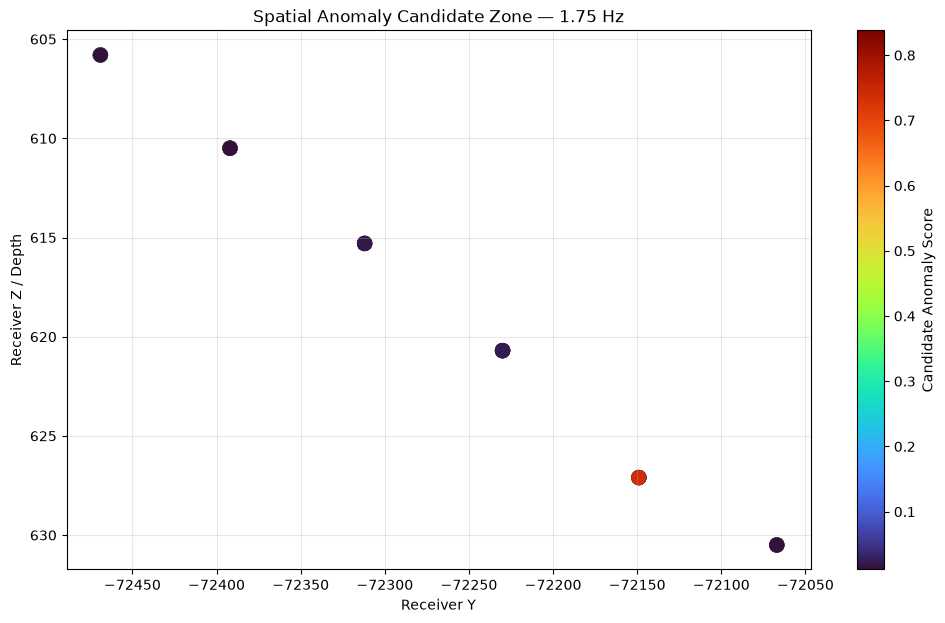

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    candidate["rx_y"],
    candidate["rx_z"],
    c=candidate["candidate_score"],
    s=100,
    cmap="turbo"
)

plt.colorbar(scatter, label="Candidate Anomaly Score")

plt.xlabel("Receiver Y")
plt.ylabel("Receiver Z / Depth")
plt.title("Spatial Anomaly Candidate Zone — 1.75 Hz")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

In [162]:
print(rx_summary_sorted.columns.tolist())
print(rx_summary_sorted.head(10))

['rx_id', 'anomaly_observations', 'frequencies', 'max_lof', 'max_if', 'mean_geometry_residual', 'mean_response_magnitude', 'rx_y', 'rx_z', 'frequency_persistence']
   rx_id  anomaly_observations  frequencies   max_lof    max_if  \
0    234                     1            1  1.733385  0.016178   
1    244                     1            1  1.844668  0.011556   
2    436                     1            1  1.778354  0.012971   
3    481                     1            1  1.479425  0.043135   
4    489                     1            1  1.775545  0.056238   
5    490                     1            1  1.426247  0.021406   
6    499                     1            1  1.621055  0.024266   
7    500                     1            1  1.636213  0.091239   
8    502                     1            1  1.736968  0.062305   
9    503                     1            1  1.550739  0.050874   

   mean_geometry_residual  mean_response_magnitude   rx_y   rx_z  \
0                0.796121     

In [163]:
import numpy as np
import pandas as pd

# Work from the dataframe you already have
candidate_summary = rx_summary_sorted.copy()

# ------------------------------------------------------------
# 1. Normalize LOF
# Higher LOF = more anomalous
# ------------------------------------------------------------
lof_min = candidate_summary["max_lof"].min()
lof_max = candidate_summary["max_lof"].max()

candidate_summary["lof_norm"] = (
    (candidate_summary["max_lof"] - lof_min) /
    (lof_max - lof_min)
)

# ------------------------------------------------------------
# 2. Normalize Isolation Forest
# Higher IF score here = more anomalous
# ------------------------------------------------------------
if_min = candidate_summary["max_if"].min()
if_max = candidate_summary["max_if"].max()

candidate_summary["if_norm"] = (
    (candidate_summary["max_if"] - if_min) /
    (if_max - if_min)
)

# ------------------------------------------------------------
# 3. Geometry anomaly strength
# We care about magnitude, because both strong positive
# and strong negative residuals can indicate deviation.
# ------------------------------------------------------------
candidate_summary["geometry_strength"] = (
    candidate_summary["mean_geometry_residual"].abs()
)

geom_min = candidate_summary["geometry_strength"].min()
geom_max = candidate_summary["geometry_strength"].max()

candidate_summary["geometry_norm"] = (
    (candidate_summary["geometry_strength"] - geom_min) /
    (geom_max - geom_min)
)

# ------------------------------------------------------------
# 4. Response magnitude
# Normalize relative response strength
# ------------------------------------------------------------
resp_min = candidate_summary["mean_response_magnitude"].min()
resp_max = candidate_summary["mean_response_magnitude"].max()

candidate_summary["response_norm"] = (
    (candidate_summary["mean_response_magnitude"] - resp_min) /
    (resp_max - resp_min)
)

# ------------------------------------------------------------
# 5. Composite anomaly score
#
# LOF          = 35%
# IF           = 30%
# Geometry     = 20%
# Response     = 15%
#
# Persistence is NOT included because it is identical
# (0.333333) for all receivers.
# ------------------------------------------------------------
candidate_summary["anomaly_score"] = (
    0.35 * candidate_summary["lof_norm"] +
    0.30 * candidate_summary["if_norm"] +
    0.20 * candidate_summary["geometry_norm"] +
    0.15 * candidate_summary["response_norm"]
)

# Convert to 0–100
candidate_summary["anomaly_score_100"] = (
    candidate_summary["anomaly_score"] * 100
)

# ------------------------------------------------------------
# 6. Rank receivers
# ------------------------------------------------------------
candidate_summary = (
    candidate_summary
    .sort_values("anomaly_score_100", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Display the important columns
# ------------------------------------------------------------
final_anomaly_ranking = candidate_summary[
    [
        "rx_id",
        "anomaly_score_100",
        "max_lof",
        "max_if",
        "mean_geometry_residual",
        "mean_response_magnitude",
        "frequency_persistence",
        "rx_y",
        "rx_z"
    ]
]

final_anomaly_ranking

,rx_id,anomaly_score_100,max_lof,max_if,mean_geometry_residual,mean_response_magnitude,frequency_persistence,rx_y,rx_z
0,742,76.200173,1.589920,0.109934,-1.286965,176.656337,0.333333,-48914,2577.3
1,504,75.232127,1.803164,0.070370,-1.320833,115.928357,0.333333,-72312,615.3
2,770,73.495057,1.592619,0.106565,-1.123041,179.651504,0.333333,-46446,2619.6
3,500,71.960191,1.636213,0.091239,-1.512707,121.075655,0.333333,-72611,595.4
4,244,58.237227,1.844668,0.011556,0.963870,143.160492,0.333333,-97606,2.8
5,810,57.020182,1.419675,0.092872,-1.175686,180.307611,0.333333,-43111,2784.3
6,489,56.907876,1.775545,0.056238,-0.432331,112.995456,0.333333,-73348,543.3
7,509,56.683630,1.454600,0.110154,-1.604113,26.627854,0.333333,-71904,641.4
8,505,55.462057,1.612085,0.057568,-1.275671,106.475733,0.333333,-72230,620.7
9,502,53.569767,1.736968,0.062305,-0.939023,14.003769,0.333333,-72469,605.8


In [165]:
import pandas as pd
import numpy as np

# ============================================================
# FINAL METAL DETECTION DECISION LAYER
# ============================================================

df_final = rx_summary_sorted.copy()

# ============================================================
# 1. ANOMALY SCORE
# ============================================================

# Normalize LOF
lof_component = (
    (df_final["max_lof"] - df_final["max_lof"].min()) /
    (df_final["max_lof"].max() - df_final["max_lof"].min())
) * 100

# Normalize Isolation Forest
if_component = (
    (df_final["max_if"] - df_final["max_if"].min()) /
    (df_final["max_if"].max() - df_final["max_if"].min())
) * 100

# Combined ML anomaly score
df_final["anomaly_score_100"] = (
    0.60 * lof_component +
    0.40 * if_component
).clip(0, 100)


# ============================================================
# 2. GEOMETRY-CORRECTED RESPONSE
# ============================================================

geometry_component = (
    df_final["mean_geometry_residual"].abs() /
    df_final["mean_geometry_residual"].abs().max()
) * 100

geometry_component = geometry_component.clip(0, 100)


# ============================================================
# 3. RESPONSE STRENGTH
# ============================================================

response_component = (
    df_final["mean_response_magnitude"] /
    df_final["mean_response_magnitude"].max()
) * 100

response_component = response_component.clip(0, 100)


# ============================================================
# 4. FREQUENCY PERSISTENCE
# ============================================================

persistence_component = (
    df_final["frequency_persistence"] * 100
).clip(0, 100)


# ============================================================
# 5. METAL EVIDENCE SCORE
# ============================================================

df_final["metal_evidence_score"] = (
    0.50 * df_final["anomaly_score_100"] +
    0.20 * geometry_component +
    0.20 * response_component +
    0.10 * persistence_component
).clip(0, 100)


# ============================================================
# 6. EVIDENCE LEVEL
# ============================================================

def evidence_level(score):

    if score >= 75:
        return "VERY HIGH"

    elif score >= 60:
        return "HIGH"

    elif score >= 45:
        return "MODERATE"

    elif score >= 30:
        return "LOW"

    else:
        return "VERY LOW"


df_final["metal_evidence"] = (
    df_final["metal_evidence_score"]
    .apply(evidence_level)
)


# ============================================================
# 7. METAL CANDIDATE
# ============================================================

df_final["metal_candidate"] = np.where(
    df_final["metal_evidence_score"] >= 50,
    "YES",
    "NO"
)


# ============================================================
# 8. TYPE & CONCENTRATION
# ============================================================

df_final["metal_type"] = "NOT DETERMINABLE"

df_final["concentration"] = "REQUIRES CALIBRATION"


# ============================================================
# 9. FINAL SORT
# ============================================================

df_final = df_final.sort_values(
    "metal_evidence_score",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 10. FINAL TABLE
# ============================================================

final_columns = [
    "rx_id",
    "anomaly_score_100",
    "metal_evidence_score",
    "metal_evidence",
    "metal_candidate",
    "max_lof",
    "max_if",
    "mean_geometry_residual",
    "mean_response_magnitude",
    "frequency_persistence",
    "rx_y",
    "rx_z",
    "metal_type",
    "concentration"
]

df_final[final_columns].head(20)

,rx_id,anomaly_score_100,metal_evidence_score,metal_evidence,metal_candidate,max_lof,max_if,mean_geometry_residual,mean_response_magnitude,frequency_persistence,rx_y,rx_z,metal_type,concentration
0,742,66.933827,72.441060,HIGH,YES,1.589920,0.109934,-1.286965,176.656337,0.333333,-48914,2577.3,NOT DETERMINABLE,REQUIRES CALIBRATION
1,504,78.487332,71.904026,HIGH,YES,1.803164,0.070370,-1.320833,115.928357,0.333333,-72312,615.3,NOT DETERMINABLE,REQUIRES CALIBRATION
2,770,65.916203,70.220679,HIGH,YES,1.592619,0.106565,-1.123041,179.651504,0.333333,-46446,2619.6,NOT DETERMINABLE,REQUIRES CALIBRATION
3,500,65.341690,68.294432,HIGH,YES,1.636213,0.091239,-1.512707,121.075655,0.333333,-72611,595.4,NOT DETERMINABLE,REQUIRES CALIBRATION
4,244,60.000000,61.230401,HIGH,YES,1.844668,0.011556,0.963870,143.160492,0.333333,-97606,2.8,NOT DETERMINABLE,REQUIRES CALIBRATION
5,810,37.973497,56.978471,MODERATE,YES,1.419675,0.092872,-1.175686,180.307611,0.333333,-43111,2784.3,NOT DETERMINABLE,REQUIRES CALIBRATION
6,489,69.178738,55.846609,MODERATE,YES,1.775545,0.056238,-0.432331,112.995456,0.333333,-73348,543.3,NOT DETERMINABLE,REQUIRES CALIBRATION
7,505,48.558512,55.328038,MODERATE,YES,1.612085,0.057568,-1.275671,106.475733,0.333333,-72230,620.7,NOT DETERMINABLE,REQUIRES CALIBRATION
8,234,47.469493,53.898974,MODERATE,YES,1.733385,0.016178,0.796121,152.404137,0.333333,-98499,4.2,NOT DETERMINABLE,REQUIRES CALIBRATION
9,509,49.505686,51.039779,MODERATE,YES,1.454600,0.110154,-1.604113,26.627854,0.333333,-71904,641.4,NOT DETERMINABLE,REQUIRES CALIBRATION


In [167]:
from IPython.display import display, HTML

def show_target(rx_id, df=df_final):

    row = df[df["rx_id"] == rx_id]

    if row.empty:
        print(f"RX {rx_id} not found.")
        return

    r = row.iloc[0]

    score = float(r["anomaly_score_100"])
    evidence = float(r["metal_evidence_score"])

    evidence_level = str(r["metal_evidence"])
    candidate = str(r["metal_candidate"])

    if candidate == "YES":
        candidate_display = "🟢 YES"
        interpretation = (
            "This receiver shows a strong anomalous response "
            "with evidence consistent with a potential "
            "metal-related target."
        )
    else:
        candidate_display = "⚪ NO"
        interpretation = (
            "This receiver shows an anomalous response, "
            "but the available evidence is insufficient "
            "to classify it as a metal target."
        )

    html = f"""
    <div style="
        border:2px solid #777;
        border-radius:15px;
        padding:20px;
        margin:15px 0;
        max-width:650px;
        font-family:Arial;
    ">

        <h2>🔬 Metal Anomaly Detection — RX {int(r["rx_id"])}</h2>

        <hr>

        <h3>Anomaly Score</h3>
        <div style="font-size:30px;font-weight:bold;">
            {score:.2f} / 100
        </div>

        <h3>Metal Evidence</h3>
        <div style="font-size:24px;font-weight:bold;">
            {evidence:.2f} / 100 — {evidence_level}
        </div>

        <h3>Metal Candidate</h3>
        <div style="font-size:25px;font-weight:bold;">
            {candidate_display}
        </div>

        <hr>

        <h3>📍 Location</h3>
        <b>Y:</b> {r["rx_y"]}<br>
        <b>Z:</b> {r["rx_z"]}

        <h3>🧲 Interpretation</h3>
        <p>{interpretation}</p>

        <h3>Metal Type</h3>
        <b>{r["metal_type"]}</b>

        <h3>Concentration</h3>
        <b>{r["concentration"]}</b>

    </div>
    """

    display(HTML(html))

In [168]:
show_target(504)

In [169]:
show_target(742)

In [170]:
show_target(770)

In [171]:
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. TOP METAL TARGETS
# ============================================================

def show_top_targets(n=10, df=df_final):

    top = (
        df.sort_values(
            ["metal_candidate", "metal_evidence_score", "anomaly_score_100"],
            ascending=[False, False, False]
        )
        .drop_duplicates("rx_id")
        .head(n)
    )

    cards = ""

    for _, r in top.iterrows():

        candidate = str(r["metal_candidate"])
        evidence = str(r["metal_evidence"])

        if candidate == "YES":
            icon = "🟢"
        else:
            icon = "⚪"

        cards += f"""
        <div style="
            display:inline-block;
            vertical-align:top;
            width:280px;
            min-height:210px;
            margin:8px;
            padding:18px;
            border:2px solid #666;
            border-radius:15px;
            font-family:Arial;
        ">

            <h2>RX {int(r["rx_id"])}</h2>

            <hr>

            <b>Anomaly Score</b>
            <div style="font-size:25px;font-weight:bold;">
                {r["anomaly_score_100"]:.2f}/100
            </div>

            <b>Metal Evidence</b>
            <div style="font-size:20px;font-weight:bold;">
                {r["metal_evidence_score"]:.2f}
                — {evidence}
            </div>

            <b>Candidate</b>
            <div style="font-size:20px;font-weight:bold;">
                {icon} {candidate}
            </div>

            <br>

            <b>Location:</b><br>
            Y = {r["rx_y"]}<br>
            Z = {r["rx_z"]}

        </div>
        """

    html = f"""
    <div style="font-family:Arial;">

        <h1>🚨 Top Potential Metal Targets</h1>

        <p>
        Receivers are ranked using metal evidence and anomaly strength.
        </p>

        <div>
            {cards}
        </div>

    </div>
    """

    display(HTML(html))


# ============================================================
# 2. SPATIAL DETECTION MAP
# ============================================================

def show_detection_map(df=df_final):

    plot_df = df.drop_duplicates("rx_id").copy()

    plt.figure(figsize=(12, 7))

    # Plot all receivers
    plt.scatter(
        plot_df["rx_y"],
        plot_df["rx_z"],
        s=45,
        alpha=0.45,
        label="Receivers"
    )

    # Plot metal candidates
    candidates = plot_df[
        plot_df["metal_candidate"].astype(str).str.upper() == "YES"
    ]

    if not candidates.empty:

        plt.scatter(
            candidates["rx_y"],
            candidates["rx_z"],
            s=150,
            marker="*",
            label="Potential metal target"
        )

        # Label candidates
        for _, r in candidates.iterrows():

            plt.annotate(
                f'RX {int(r["rx_id"])}',
                (r["rx_y"], r["rx_z"]),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=9
            )

    plt.xlabel("Receiver Y Position")
    plt.ylabel("Receiver Z Position")
    plt.title("🧲 Spatial Metal Anomaly Detection Map")

    # Important for depth-like Z coordinate
    plt.gca().invert_yaxis()

    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. COMBINED FINAL DASHBOARD
# ============================================================

def show_dashboard(df=df_final, n=10):

    print("\n")
    print("=" * 65)
    print("        🔬 METAL ANOMALY DETECTION DASHBOARD")
    print("=" * 65)

    # Summary numbers
    unique_rx = df["rx_id"].nunique()

    candidates = (
        df[df["metal_candidate"].astype(str).str.upper() == "YES"]
        ["rx_id"]
        .nunique()
    )

    high_evidence = (
        df[df["metal_evidence"].astype(str).str.upper() == "HIGH"]
        ["rx_id"]
        .nunique()
    )

    print(f"\nReceivers analysed       : {unique_rx}")
    print(f"Potential metal targets  : {candidates}")
    print(f"High-evidence targets    : {high_evidence}")

    print("\n")

    # Top targets
    show_top_targets(n=n, df=df)

    print("\n")

    # Map
    show_detection_map(df=df)



        🔬 METAL ANOMALY DETECTION DASHBOARD

Receivers analysed       : 29
Potential metal targets  : 11
High-evidence targets    : 5




C:\Users\Shakthi\AppData\Local\Temp\ipykernel_10872\3016406527.py:148: UserWarning: Glyph 129522 (\N{MAGNET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Shakthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129522 (\N{MAGNET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


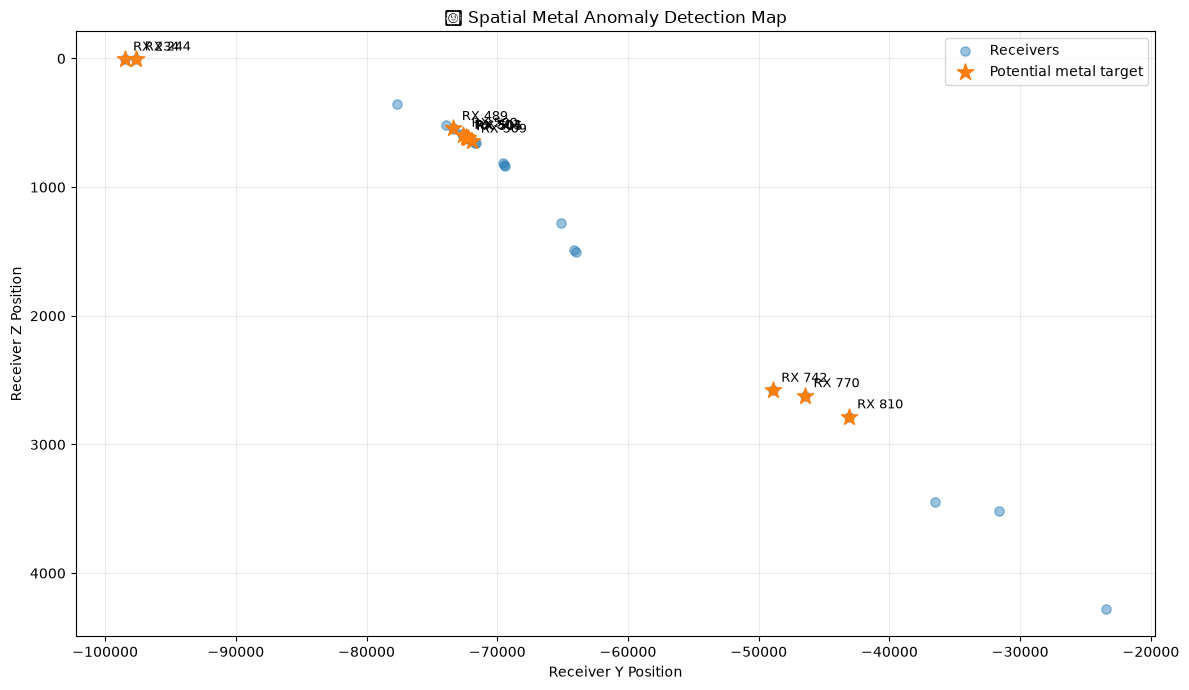

In [172]:
show_dashboard()

In [173]:
show_top_targets()

In [174]:
import pandas as pd
import webbrowser
import threading
from http.server import HTTPServer, BaseHTTPRequestHandler
from pathlib import Path

# ============================================================
# USE YOUR FINAL DATAFRAME
# ============================================================

# IMPORTANT:
# Change df_final only if your final dataframe has a different name.
df = df_final.copy()

# ============================================================
# PREPARE DATA
# ============================================================

records = df.to_dict(orient="records")

# Convert NaN / numpy values safely
import json
import numpy as np

def clean_value(v):
    if pd.isna(v):
        return None
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v

records = [
    {k: clean_value(v) for k, v in row.items()}
    for row in records
]

data_json = json.dumps(records)

# ============================================================
# HTML DASHBOARD
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>

<meta charset="UTF-8">

<title>Metal Detection Dashboard</title>

<style>

body {{
    margin: 0;
    font-family: Arial, sans-serif;
    background: #0b1220;
    color: #e8eefc;
}}

.header {{
    padding: 25px 40px;
    background: #111a2e;
    border-bottom: 1px solid #263451;
}}

.header h1 {{
    margin: 0;
    font-size: 28px;
}}

.header p {{
    margin-top: 8px;
    color: #94a3b8;
}}

.container {{
    padding: 30px 40px;
}}

.cards {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 18px;
    margin-bottom: 30px;
}}

.card {{
    background: #111a2e;
    border: 1px solid #263451;
    border-radius: 14px;
    padding: 22px;
}}

.card-title {{
    color: #94a3b8;
    font-size: 14px;
}}

.card-value {{
    font-size: 30px;
    font-weight: bold;
    margin-top: 8px;
}}

.dashboard {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 25px;
}}

.panel {{
    background: #111a2e;
    border: 1px solid #263451;
    border-radius: 14px;
    padding: 25px;
}}

.panel h2 {{
    margin-top: 0;
}}

.receiver-list {{
    max-height: 500px;
    overflow-y: auto;
}}

.receiver {{
    padding: 15px;
    margin-bottom: 10px;
    background: #18233a;
    border-radius: 10px;
    cursor: pointer;
    border-left: 4px solid #64748b;
}}

.receiver:hover {{
    background: #202e49;
}}

.receiver.yes {{
    border-left-color: #22c55e;
}}

.receiver.no {{
    border-left-color: #64748b;
}}

.rx-id {{
    font-size: 18px;
    font-weight: bold;
}}

.score {{
    font-size: 24px;
    font-weight: bold;
}}

.badge {{
    display: inline-block;
    padding: 5px 10px;
    border-radius: 20px;
    font-size: 12px;
    font-weight: bold;
}}

.badge-high {{
    background: #7f1d1d;
    color: #fecaca;
}}

.badge-moderate {{
    background: #78350f;
    color: #fed7aa;
}}

.badge-low {{
    background: #1e3a5f;
    color: #bfdbfe;
}}

.detail {{
    line-height: 1.8;
}}

.detail-row {{
    display: flex;
    justify-content: space-between;
    border-bottom: 1px solid #263451;
    padding: 8px 0;
}}

.label {{
    color: #94a3b8;
}}

.value {{
    font-weight: bold;
}}

.detected {{
    color: #22c55e;
}}

.not-detected {{
    color: #94a3b8;
}}

select {{
    width: 100%;
    padding: 12px;
    margin-bottom: 20px;
    background: #18233a;
    color: white;
    border: 1px solid #334155;
    border-radius: 8px;
}}

</style>

</head>

<body>

<div class="header">

<h1>🔬 Metal Detection & Anomaly Analysis</h1>

<p>
AI-assisted receiver analysis using anomaly detection,
geometry-corrected response and multi-frequency evidence.
</p>

</div>

<div class="container">

<div class="cards">

<div class="card">
<div class="card-title">Receivers Analysed</div>
<div class="card-value" id="total"></div>
</div>

<div class="card">
<div class="card-title">Metal Candidates</div>
<div class="card-value" id="candidates"></div>
</div>

<div class="card">
<div class="card-title">High Evidence</div>
<div class="card-value" id="high"></div>
</div>

<div class="card">
<div class="card-title">Highest Anomaly</div>
<div class="card-value" id="maxScore"></div>
</div>

</div>

<div class="dashboard">

<div class="panel">

<h2>📡 Receiver Ranking</h2>

<select id="receiverSelect" onchange="showReceiver(this.value)">
</select>

<div class="receiver-list" id="receiverList"></div>

</div>

<div class="panel">

<h2>🔎 Receiver Details</h2>

<div id="details">

<p>Select a receiver from the list.</p>

</div>

</div>

</div>

</div>

<script>

const data = {data_json};

data.sort((a,b) =>
    (b.anomaly_score_100 || 0) -
    (a.anomaly_score_100 || 0)
);

// ------------------------------------------------------------
// SUMMARY
// ------------------------------------------------------------

document.getElementById("total").innerText = data.length;

document.getElementById("candidates").innerText =
    data.filter(x => x.metal_candidate === "YES").length;

document.getElementById("high").innerText =
    data.filter(x => x.metal_evidence === "HIGH").length;

const maxScore = Math.max(
    ...data.map(x => x.anomaly_score_100 || 0)
);

document.getElementById("maxScore").innerText =
    maxScore.toFixed(1);

// ------------------------------------------------------------
// RECEIVER SELECT
// ------------------------------------------------------------

const select = document.getElementById("receiverSelect");

data.forEach((r, i) => {{

    const option = document.createElement("option");

    option.value = i;

    option.text =
        "RX " + r.rx_id +
        " — Score " +
        (r.anomaly_score_100 || 0).toFixed(1);

    select.appendChild(option);

}});

// ------------------------------------------------------------
// RECEIVER LIST
// ------------------------------------------------------------

const list = document.getElementById("receiverList");

data.forEach((r, i) => {{

    const div = document.createElement("div");

    const candidate =
        r.metal_candidate === "YES";

    div.className =
        "receiver " +
        (candidate ? "yes" : "no");

    div.innerHTML = `
        <div class="rx-id">
            RX ${{r.rx_id}}
        </div>

        <div style="margin-top:6px">

            <span class="score">
                ${{(r.anomaly_score_100 || 0).toFixed(1)}}/100
            </span>

            &nbsp;

            <span class="badge">
                ${{r.metal_evidence || "UNKNOWN"}}
            </span>

        </div>

        <div style="margin-top:6px;color:#94a3b8">
            Metal candidate:
            ${{r.metal_candidate}}
        </div>
    `;

    div.onclick = () => showReceiver(i);

    list.appendChild(div);

}});

// ------------------------------------------------------------
// DETAILS
// ------------------------------------------------------------

function showReceiver(index) {{

    const r = data[index];

    const candidate =
        r.metal_candidate === "YES";

    const evidence =
        r.metal_evidence || "UNKNOWN";

    let badgeClass = "badge-low";

    if (evidence === "HIGH")
        badgeClass = "badge-high";

    if (evidence === "MODERATE")
        badgeClass = "badge-moderate";

    document.getElementById("details").innerHTML = `

        <div style="text-align:center;margin-bottom:25px">

            <div style="font-size:36px;font-weight:bold">
                RX ${{r.rx_id}}
            </div>

            <div style="margin-top:10px">

                <span class="badge ${{badgeClass}}">
                    ${{evidence}} EVIDENCE
                </span>

            </div>

        </div>

        <div class="detail">

            <div class="detail-row">
                <span class="label">Anomaly Score</span>
                <span class="value">
                    ${{(r.anomaly_score_100 || 0).toFixed(2)}} / 100
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Metal Evidence</span>
                <span class="value">
                    ${{(r.metal_evidence_score || 0).toFixed(2)}} / 100
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Metal Detected</span>
                <span class="value ${{candidate ? "detected" : "not-detected"}}">
                    ${{candidate ? "YES" : "NO"}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">LOF Score</span>
                <span class="value">
                    ${{(r.max_lof || 0).toFixed(3)}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Isolation Forest</span>
                <span class="value">
                    ${{(r.max_if || 0).toFixed(3)}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Geometry Residual</span>
                <span class="value">
                    ${{(r.mean_geometry_residual || 0).toFixed(3)}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Response Magnitude</span>
                <span class="value">
                    ${{(r.mean_response_magnitude || 0).toFixed(2)}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Frequency Persistence</span>
                <span class="value">
                    ${{((r.frequency_persistence || 0) * 100).toFixed(1)}}%
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Position Y</span>
                <span class="value">
                    ${{r.rx_y}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Position Z</span>
                <span class="value">
                    ${{r.rx_z}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Metal Type</span>
                <span class="value">
                    ${{r.metal_type || "NOT DETERMINABLE"}}
                </span>
            </div>

            <div class="detail-row">
                <span class="label">Concentration</span>
                <span class="value">
                    ${{r.concentration || "REQUIRES CALIBRATION"}}
                </span>
            </div>

        </div>
    `;
}}

// Show highest-ranked receiver initially
showReceiver(0);

</script>

</body>
</html>
"""

# ============================================================
# SAVE HTML
# ============================================================

html_path = Path.cwd() / "metal_detection_dashboard.html"

html_path.write_text(
    html,
    encoding="utf-8"
)

# ============================================================
# OPEN IN BROWSER
# ============================================================

url = html_path.as_uri()

print("✅ Dashboard created!")
print(f"📂 File: {html_path}")
print("🌐 Opening dashboard in your browser...")

webbrowser.open(url)

✅ Dashboard created!
📂 File: c:\Users\Shakthi\Desktop\PS26064_ML\notebooks\metal_detection_dashboard.html
🌐 Opening dashboard in your browser...


True

In [175]:
from pathlib import Path
import webbrowser, json, math

# ============================================================
# ONE-CELL 3D METAL ANOMALY DASHBOARD
# Uses existing df_final from the notebook
# ============================================================

# Basic validation
required = [
    "rx_id", "anomaly_score_100", "metal_evidence_score",
    "metal_evidence", "metal_candidate", "max_lof", "max_if",
    "mean_geometry_residual", "mean_response_magnitude",
    "frequency_persistence", "rx_y", "rx_z", "metal_type",
    "concentration"
]

missing = [c for c in required if c not in df_final.columns]
if missing:
    raise KeyError(f"df_final is missing columns: {missing}")

d = df_final.copy()

# Clean values for JSON
def clean(v):
    if v is None:
        return None
    try:
        if hasattr(v, "item"):
            v = v.item()
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            return None
    except:
        pass
    return v

records = []
for _, r in d.iterrows():
    records.append({c: clean(r[c]) for c in required})

data_json = json.dumps(records, ensure_ascii=False, allow_nan=False)

html = r"""<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<title>MetalSense 3D — Anomaly Intelligence</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<script src="https://cdn.jsdelivr.net/npm/three@0.160.0/build/three.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/three@0.160.0/examples/js/controls/OrbitControls.js"></script>

<style>
*{box-sizing:border-box}
html,body{
    margin:0;width:100%;height:100%;overflow:hidden;
    font-family:Inter,Segoe UI,Arial,sans-serif;
    background:#020617;color:#e5f2ff
}
#app{width:100%;height:100%;position:relative}
canvas{display:block}

#topbar{
    position:absolute;top:18px;left:22px;right:22px;
    display:flex;align-items:center;justify-content:space-between;
    z-index:10;pointer-events:none
}
.brand{
    pointer-events:auto;
    display:flex;align-items:center;gap:12px
}
.logo{
    width:42px;height:42px;border-radius:13px;
    background:linear-gradient(135deg,#22d3ee,#2563eb);
    display:grid;place-items:center;
    box-shadow:0 0 28px rgba(34,211,238,.35);
    font-size:21px
}
.title{
    font-size:21px;font-weight:800;letter-spacing:.3px
}
.subtitle{
    font-size:11px;color:#7dd3fc;margin-top:3px;
    letter-spacing:1.7px;text-transform:uppercase
}

.badge{
    pointer-events:auto;
    padding:9px 14px;border:1px solid rgba(125,211,252,.2);
    border-radius:999px;background:rgba(2,6,23,.68);
    backdrop-filter:blur(12px);font-size:11px;color:#bae6fd
}

#stats{
    position:absolute;top:85px;left:22px;z-index:10;
    display:flex;gap:10px;flex-wrap:wrap;max-width:700px
}
.stat{
    min-width:125px;padding:11px 14px;
    border:1px solid rgba(148,163,184,.13);
    border-radius:14px;background:rgba(15,23,42,.67);
    backdrop-filter:blur(15px);
    box-shadow:0 10px 30px rgba(0,0,0,.2)
}
.stat .n{font-size:20px;font-weight:800}
.stat .l{font-size:9px;color:#94a3b8;text-transform:uppercase;letter-spacing:1.2px;margin-top:3px}

#panel{
    position:absolute;right:22px;top:85px;width:330px;
    z-index:12;padding:18px;
    border:1px solid rgba(125,211,252,.18);
    border-radius:20px;
    background:rgba(3,10,25,.78);
    backdrop-filter:blur(22px);
    box-shadow:0 25px 70px rgba(0,0,0,.38);
    transform:translateX(370px);
    transition:.35s ease;
}
#panel.show{transform:translateX(0)}

.panelHead{display:flex;justify-content:space-between;align-items:center}
.rx{
    font-size:25px;font-weight:850
}
.close{
    width:30px;height:30px;border-radius:9px;
    border:1px solid rgba(148,163,184,.2);
    background:rgba(30,41,59,.6);color:#cbd5e1;
    cursor:pointer
}
.status{
    margin:13px 0;padding:10px 12px;border-radius:11px;
    font-size:12px;font-weight:700;letter-spacing:.5px
}
.high{background:rgba(244,63,94,.13);color:#fb7185;border:1px solid rgba(244,63,94,.2)}
.mod{background:rgba(251,191,36,.12);color:#fbbf24;border:1px solid rgba(251,191,36,.2)}
.low{background:rgba(34,197,94,.10);color:#4ade80;border:1px solid rgba(34,197,94,.2)}

.score{
    display:flex;align-items:center;gap:15px;margin:15px 0
}
.circle{
    width:72px;height:72px;border-radius:50%;
    display:grid;place-items:center;
    font-size:20px;font-weight:850;
    border:3px solid #22d3ee;
    box-shadow:0 0 25px rgba(34,211,238,.15)
}
.scoreText small{display:block;color:#94a3b8;font-size:10px;text-transform:uppercase}
.scoreText strong{font-size:14px}

.grid{
    display:grid;grid-template-columns:1fr 1fr;gap:9px
}
.item{
    padding:10px;border-radius:11px;
    background:rgba(15,23,42,.65);
    border:1px solid rgba(148,163,184,.09)
}
.item span{display:block;color:#64748b;font-size:9px;text-transform:uppercase;letter-spacing:.8px}
.item b{display:block;margin-top:4px;font-size:12px;color:#dbeafe}

#bottom{
    position:absolute;left:22px;bottom:20px;z-index:10;
    padding:10px 14px;border-radius:12px;
    background:rgba(2,6,23,.68);
    border:1px solid rgba(148,163,184,.12);
    color:#64748b;font-size:10px;
    backdrop-filter:blur(12px)
}
#bottom b{color:#94a3b8}

#hint{
    position:absolute;bottom:20px;right:22px;z-index:10;
    padding:10px 14px;border-radius:12px;
    background:rgba(2,6,23,.68);
    border:1px solid rgba(148,163,184,.12);
    color:#64748b;font-size:10px;
    backdrop-filter:blur(12px)
}

#legend{
    position:absolute;left:22px;top:155px;z-index:10;
    font-size:10px;color:#94a3b8;
    display:flex;gap:13px
}
.dot{
    display:inline-block;width:8px;height:8px;border-radius:50%;
    margin-right:5px
}

#loading{
    position:absolute;inset:0;z-index:100;
    display:grid;place-items:center;
    background:#020617;
    transition:.5s
}
.loader{text-align:center}
.loader .orb{
    width:65px;height:65px;border-radius:50%;
    border:2px solid rgba(34,211,238,.25);
    border-top-color:#22d3ee;
    animation:spin 1s linear infinite;
    margin:auto auto 16px
}
@keyframes spin{to{transform:rotate(360deg)}}

@media(max-width:850px){
    #panel{width:290px}
    #stats{max-width:500px}
    .stat{min-width:105px}
}
</style>
</head>

<body>
<div id="app">

<div id="loading">
  <div class="loader">
    <div class="orb"></div>
    <div>Initializing 3D anomaly field...</div>
  </div>
</div>

<div id="topbar">
  <div class="brand">
    <div class="logo">◈</div>
    <div>
      <div class="title">MetalSense 3D</div>
      <div class="subtitle">Subsurface anomaly intelligence</div>
    </div>
  </div>
  <div class="badge">● LIVE MODEL VIEW</div>
</div>

<div id="stats"></div>
<div id="legend"></div>

<div id="panel">
  <div class="panelHead">
    <div class="rx" id="pRx">RX —</div>
    <button class="close" onclick="closePanel()">×</button>
  </div>
  <div id="pStatus" class="status">—</div>
  <div class="score">
    <div class="circle" id="pScore">—</div>
    <div class="scoreText">
      <small>Anomaly score</small>
      <strong id="pMetal">—</strong>
    </div>
  </div>
  <div class="grid" id="pGrid"></div>
</div>

<div id="bottom">
  <b>Click</b> a receiver to inspect · <b>Drag</b> to rotate · <b>Scroll</b> to zoom
</div>
<div id="hint">Geometry-corrected anomaly field</div>

</div>

<script>
const DATA = __DATA__;

const app = document.getElementById("app");

function esc(v){
  return String(v ?? "—")
    .replaceAll("&","&amp;").replaceAll("<","&lt;")
    .replaceAll(">","&gt;").replaceAll('"',"&quot;");
}

const high = DATA.filter(x => x.metal_evidence === "HIGH").length;
const moderate = DATA.filter(x => x.metal_evidence === "MODERATE").length;
const candidates = DATA.filter(x => x.metal_candidate === "YES").length;
const maxScore = Math.max(...DATA.map(x => Number(x.anomaly_score_100)||0));

document.getElementById("stats").innerHTML = `
<div class="stat"><div class="n">${DATA.length}</div><div class="l">Receivers</div></div>
<div class="stat"><div class="n">${candidates}</div><div class="l">Metal candidates</div></div>
<div class="stat"><div class="n">${high}</div><div class="l">High evidence</div></div>
<div class="stat"><div class="n">${moderate}</div><div class="l">Moderate evidence</div></div>
<div class="stat"><div class="n">${maxScore.toFixed(1)}</div><div class="l">Peak anomaly</div></div>
`;

document.getElementById("legend").innerHTML = `
<span><i class="dot" style="background:#fb7185"></i>HIGH</span>
<span><i class="dot" style="background:#fbbf24"></i>MODERATE</span>
<span><i class="dot" style="background:#4ade80"></i>LOW</span>
`;

let scene, camera, renderer, controls, raycaster, mouse;
let points = [];
let selected = null;

function init(){

  scene = new THREE.Scene();
  scene.background = new THREE.Color(0x020617);
  scene.fog = new THREE.FogExp2(0x020617, 0.000018);

  camera = new THREE.PerspectiveCamera(
    52, window.innerWidth/window.innerHeight, 1, 1000000
  );
  camera.position.set(0, -10000, 36000);

  renderer = new THREE.WebGLRenderer({
    antialias:true,
    powerPreference:"high-performance"
  });
  renderer.setPixelRatio(Math.min(window.devicePixelRatio,2));
  renderer.setSize(window.innerWidth,window.innerHeight);
  app.appendChild(renderer.domElement);

  controls = new THREE.OrbitControls(camera,renderer.domElement);
  controls.enableDamping = true;
  controls.dampingFactor = .045;
  controls.minDistance = 3000;
  controls.maxDistance = 180000;

  // Ambient stars
  const starGeo = new THREE.BufferGeometry();
  const starPos = [];
  for(let i=0;i<1300;i++){
    starPos.push(
      (Math.random()-.5)*220000,
      (Math.random()-.5)*120000,
      (Math.random()-.5)*150000
    );
  }
  starGeo.setAttribute("position",new THREE.Float32BufferAttribute(starPos,3));
  const starMat = new THREE.PointsMaterial({
    color:0x7dd3fc,size:45,transparent:true,opacity:.32
  });
  scene.add(new THREE.Points(starGeo,starMat));

  // Ground grid
  const grid = new THREE.GridHelper(150000,45,0x164e63,0x0f2d3a);
  grid.rotation.x = Math.PI/2;
  grid.position.z = 5000;
  scene.add(grid);

  // Center glow
  const glowGeo = new THREE.SphereGeometry(900,32,32);
  const glowMat = new THREE.MeshBasicMaterial({
    color:0x0891b2,transparent:true,opacity:.055,
    wireframe:true
  });
  scene.add(new THREE.Mesh(glowGeo,glowMat));

  const ys = DATA.map(x=>Number(x.rx_y));
  const zs = DATA.map(x=>Number(x.rx_z));
  const minY=Math.min(...ys), maxY=Math.max(...ys);
  const minZ=Math.min(...zs), maxZ=Math.max(...zs);

  function norm(v,min,max,size){
    return ((v-min)/(max-min||1)-.5)*size;
  }

  DATA.forEach((r,i)=>{
    const score = Number(r.anomaly_score_100)||0;

    let color = 0x4ade80;
    if(r.metal_evidence==="HIGH") color=0xfb7185;
    else if(r.metal_evidence==="MODERATE") color=0xfbbf24;

    const x = norm(Number(r.rx_y),minY,maxY,90000);
    const y = -norm(Number(r.rx_z),minZ,maxZ,28000);
    const z = Math.sin(i*.55)*850;

    const radius = 170 + score*4.0;

    const geo = new THREE.SphereGeometry(radius,18,18);
    const mat = new THREE.MeshStandardMaterial({
      color:color,
      emissive:color,
      emissiveIntensity:.8,
      metalness:.2,
      roughness:.25
    });

    const mesh = new THREE.Mesh(geo,mat);
    mesh.position.set(x,y,z);
    mesh.userData = {record:r, baseRadius:radius};
    scene.add(mesh);

    // anomaly halo
    if(score >= 45){
      const ring = new THREE.Mesh(
        new THREE.TorusGeometry(radius*1.35,10,8,40),
        new THREE.MeshBasicMaterial({
          color:color,transparent:true,opacity:.28
        })
      );
      ring.rotation.x=Math.PI/2;
      ring.position.copy(mesh.position);
      ring.userData={parent:mesh};
      scene.add(ring);
    }

    points.push(mesh);
  });

  // Connect nearby receivers with subtle lines
  const linePts=[];
  for(let i=0;i<points.length-1;i++){
    linePts.push(points[i].position,points[i+1].position);
  }
  const lineGeo=new THREE.BufferGeometry().setFromPoints(linePts);
  const lineMat=new THREE.LineBasicMaterial({
    color:0x164e63,transparent:true,opacity:.38
  });
  scene.add(new THREE.LineSegments(lineGeo,lineMat));

  raycaster = new THREE.Raycaster();
  mouse = new THREE.Vector2();

  renderer.domElement.addEventListener("pointerdown",onPointer,false);
  window.addEventListener("resize",onResize);

  animate();

  setTimeout(()=>{
    document.getElementById("loading").style.opacity="0";
    setTimeout(()=>document.getElementById("loading").remove(),550);
  },700);
}

function onPointer(e){
  const rect=renderer.domElement.getBoundingClientRect();
  mouse.x=((e.clientX-rect.left)/rect.width)*2-1;
  mouse.y=-((e.clientY-rect.top)/rect.height)*2+1;

  raycaster.setFromCamera(mouse,camera);
  const hits=raycaster.intersectObjects(points);

  if(hits.length){
    select(hits[0].object);
  }
}

function select(mesh){
  selected=mesh;
  const r=mesh.userData.record;
  const score=Number(r.anomaly_score_100)||0;

  document.getElementById("pRx").textContent="RX "+r.rx_id;

  const st=document.getElementById("pStatus");
  st.textContent=(r.metal_candidate==="YES"?"METAL CANDIDATE":"NO STRONG METAL EVIDENCE")
      +" · "+r.metal_evidence;
  st.className="status "+(
    r.metal_evidence==="HIGH"?"high":
    r.metal_evidence==="MODERATE"?"mod":"low"
  );

  document.getElementById("pScore").textContent=score.toFixed(1);
  document.getElementById("pMetal").textContent=
      r.metal_candidate==="YES" ? "Possible conductive anomaly" : "No strong candidate";

  const items=[
    ["Evidence",r.metal_evidence],
    ["Evidence score",Number(r.metal_evidence_score).toFixed(1)],
    ["LOF",Number(r.max_lof).toFixed(3)],
    ["Isolation Forest",Number(r.max_if).toFixed(3)],
    ["Geometry residual",Number(r.mean_geometry_residual).toFixed(3)],
    ["Response magnitude",Number(r.mean_response_magnitude).toFixed(2)],
    ["Persistence",Number(r.frequency_persistence).toFixed(3)],
    ["Position",`${r.rx_y}, ${r.rx_z}`],
    ["Metal type",r.metal_type],
    ["Concentration",r.concentration]
  ];

  document.getElementById("pGrid").innerHTML=items.map(a=>`
    <div class="item"><span>${esc(a[0])}</span><b>${esc(a[1])}</b></div>
  `).join("");

  document.getElementById("panel").classList.add("show");
}

function closePanel(){
  document.getElementById("panel").classList.remove("show");
  selected=null;
}

function animate(){
  requestAnimationFrame(animate);

  const t=performance.now()*.001;

  points.forEach((p,i)=>{
    const s=p.userData.record.anomaly_score_100||0;
    const pulse = 1 + Math.sin(t*2.2+i*.5)*(.025+(s/100)*.07);
    p.scale.setScalar(pulse);
  });

  controls.update();
  renderer.render(scene,camera);
}

function onResize(){
  camera.aspect=window.innerWidth/window.innerHeight;
  camera.updateProjectionMatrix();
  renderer.setSize(window.innerWidth,window.innerHeight);
}

init();
</script>
</body>
</html>
"""

html = html.replace("__DATA__", data_json)

out = Path.cwd() / "metalsense_3d_dashboard.html"
out.write_text(html, encoding="utf-8")

webbrowser.open(out.resolve().as_uri())

print("✅ 3D dashboard created!")
print(f"📍 {out}")
print("🌐 Opening it in your default browser...")


✅ 3D dashboard created!
📍 c:\Users\Shakthi\Desktop\PS26064_ML\notebooks\metalsense_3d_dashboard.html
🌐 Opening it in your default browser...


In [180]:
# ============================================================
# ⚡ ELECTROMAGNETIC METAL ANOMALY DASHBOARD
# SINGLE JUPYTER CELL → STANDALONE WEBPAGE
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import webbrowser
import os
import html

# ============================================================
# 1. LOAD FINAL DATA
# ============================================================

df = df_final.copy()

required = [
    "rx_id",
    "anomaly_score_100",
    "metal_evidence_score",
    "metal_evidence",
    "metal_candidate",
    "max_lof",
    "max_if",
    "mean_geometry_residual",
    "mean_response_magnitude",
    "frequency_persistence",
    "rx_y",
    "rx_z",
    "metal_type",
    "concentration"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        "Missing columns:\n" + "\n".join(missing)
    )

df = df[required].copy()

# ============================================================
# 2. CLEAN DATA
# ============================================================

numeric_cols = [
    "anomaly_score_100",
    "metal_evidence_score",
    "max_lof",
    "max_if",
    "mean_geometry_residual",
    "mean_response_magnitude",
    "frequency_persistence",
    "rx_y",
    "rx_z"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["rx_id", "rx_y", "rx_z"]
).reset_index(drop=True)

# ============================================================
# 3. STATUS
# ============================================================

df["metal_candidate_clean"] = (
    df["metal_candidate"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["status"] = np.where(
    df["metal_candidate_clean"] == "YES",
    "METAL CANDIDATE",
    "NO STRONG METAL EVIDENCE"
)

# ============================================================
# 4. SUMMARY
# ============================================================

total_rx = len(df)

metal_count = int(
    (df["metal_candidate_clean"] == "YES").sum()
)

high_count = int(
    (df["anomaly_score_100"] >= 60).sum()
)

moderate_count = int(
    (
        (df["anomaly_score_100"] >= 40)
        &
        (df["anomaly_score_100"] < 60)
    ).sum()
)

low_count = int(
    (df["anomaly_score_100"] < 40).sum()
)

top_idx = df["metal_evidence_score"].idxmax()

top_rx = df.loc[top_idx, "rx_id"]

top_score = df.loc[top_idx, "anomaly_score_100"]

top_evidence = df.loc[top_idx, "metal_evidence_score"]

# ============================================================
# 5. CREATE 3D PLOT
# ============================================================

fig = go.Figure()

# ------------------------------------------------------------
# ALL RECEIVERS
# ------------------------------------------------------------

hover_text = []

for _, row in df.iterrows():

    hover_text.append(
        f"""
        <b>RX {int(row['rx_id'])}</b><br>
        ━━━━━━━━━━━━━━━<br>
        Anomaly Score: <b>{row['anomaly_score_100']:.1f}/100</b><br>
        Metal Evidence: <b>{row['metal_evidence_score']:.1f}/100</b><br>
        Status: <b>{row['status']}</b><br>
        LOF: {row['max_lof']:.3f}<br>
        Isolation Forest: {row['max_if']:.3f}<br>
        Response: {row['mean_response_magnitude']:.2f}<br>
        Geometry Residual: {row['mean_geometry_residual']:.3f}<br>
        Position: ({row['rx_y']:.0f}, {row['rx_z']:.1f})
        """
    )

fig.add_trace(
    go.Scatter3d(

        x=df["rx_y"],
        y=df["rx_z"],
        z=df["anomaly_score_100"],

        mode="markers",

        marker=dict(
            size=7,
            color=df["anomaly_score_100"],
            colorscale="Turbo",
            showscale=True,
            colorbar=dict(
                title="Anomaly<br>Score"
            ),
            opacity=0.88
        ),

        text=hover_text,

        hovertemplate="%{text}<extra></extra>",

        name="Receivers"
    )
)

# ------------------------------------------------------------
# METAL CANDIDATES
# ------------------------------------------------------------

metal_df = df[
    df["metal_candidate_clean"] == "YES"
].copy()

if len(metal_df) > 0:

    metal_hover = []

    for _, row in metal_df.iterrows():

        metal_hover.append(
            f"""
            <b>⚠ METAL CANDIDATE</b><br>
            RX {int(row['rx_id'])}<br>
            ━━━━━━━━━━━━━━━<br>
            Anomaly: {row['anomaly_score_100']:.1f}/100<br>
            Metal Evidence: {row['metal_evidence_score']:.1f}/100<br>
            Type: {html.escape(str(row['metal_type']))}<br>
            Concentration: {html.escape(str(row['concentration']))}
            """
        )

    fig.add_trace(
        go.Scatter3d(

            x=metal_df["rx_y"],
            y=metal_df["rx_z"],
            z=metal_df["anomaly_score_100"] + 2,

            mode="markers",

            marker=dict(
                size=14,
                color="red",
                symbol="diamond",
                opacity=1,
                line=dict(
                    width=2,
                    color="white"
                )
            ),

            text=metal_hover,

            hovertemplate="%{text}<extra></extra>",

            name="Metal Candidates"
        )
    )

# ============================================================
# 6. ROTATION ANIMATION
# ============================================================

frames = []

for angle in np.linspace(0, 360, 72):

    rad = np.radians(angle)

    frames.append(
        go.Frame(
            layout=dict(
                scene_camera=dict(
                    eye=dict(
                        x=2.2 * np.cos(rad),
                        y=2.2 * np.sin(rad),
                        z=1.35
                    )
                )
            )
        )
    )

fig.frames = frames

# ============================================================
# 7. PLOT LAYOUT
# ============================================================

fig.update_layout(

    height=720,

    paper_bgcolor="#050816",

    plot_bgcolor="#050816",

    font=dict(
        color="white",
        family="Arial"
    ),

    margin=dict(
        l=0,
        r=0,
        t=30,
        b=0
    ),

    legend=dict(
        bgcolor="rgba(10,15,35,0.8)",
        font=dict(color="white")
    ),

    scene=dict(

        bgcolor="#050816",

        xaxis=dict(
            title="Receiver Y Position",
            backgroundcolor="#080d20",
            gridcolor="#26304f",
            zerolinecolor="#3b4668"
        ),

        yaxis=dict(
            title="Receiver Z / Depth",
            backgroundcolor="#080d20",
            gridcolor="#26304f",
            zerolinecolor="#3b4668"
        ),

        zaxis=dict(
            title="Anomaly Score / 100",
            backgroundcolor="#080d20",
            gridcolor="#26304f",
            zerolinecolor="#3b4668"
        ),

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.3
            )
        )
    )
)

# ============================================================
# 8. CONVERT PLOT TO HTML
# ============================================================

plot_html = fig.to_html(
    full_html=False,
    include_plotlyjs=True,
    config={
        "displayModeBar": True,
        "scrollZoom": True,
        "responsive": True
    }
)

# ============================================================
# 9. TOP RECEIVER CARDS
# ============================================================

top_display = (
    df.sort_values(
        "metal_evidence_score",
        ascending=False
    )
    .head(10)
)

cards_html = ""

for _, row in top_display.iterrows():

    is_metal = (
        row["metal_candidate_clean"] == "YES"
    )

    if is_metal:

        badge = """
        <span class="badge danger">
        🔴 METAL CANDIDATE
        </span>
        """

    else:

        badge = """
        <span class="badge neutral">
        ⚪ NO STRONG METAL EVIDENCE
        </span>
        """

    cards_html += f"""

    <div class="rx-card">

        <div class="rx-header">

            <div>

                <div class="rx-number">
                    RX {int(row['rx_id'])}
                </div>

                {badge}

            </div>

            <div class="score-circle">
                {row['anomaly_score_100']:.0f}
            </div>

        </div>

        <div class="metric">

            <span>Anomaly Score</span>

            <strong>
                {row['anomaly_score_100']:.1f}/100
            </strong>

        </div>

        <div class="metric">

            <span>Metal Evidence</span>

            <strong>
                {row['metal_evidence_score']:.1f}/100
            </strong>

        </div>

        <div class="metric">

            <span>Response</span>

            <strong>
                {row['mean_response_magnitude']:.2f}
            </strong>

        </div>

        <div class="metric">

            <span>LOF</span>

            <strong>
                {row['max_lof']:.3f}
            </strong>

        </div>

        <div class="metric">

            <span>Location</span>

            <strong>
                {row['rx_y']:.0f}, {row['rx_z']:.1f}
            </strong>

        </div>

    </div>
    """

# ============================================================
# 10. FULL WEBPAGE
# ============================================================

dashboard = f"""

<!DOCTYPE html>

<html>

<head>

<meta charset="UTF-8">

<meta name="viewport"
content="width=device-width, initial-scale=1.0">

<title>
Electromagnetic Metal Detection
</title>

<style>

* {{
    box-sizing:border-box;
}}

body {{

    margin:0;

    background:
    radial-gradient(
        circle at 20% 10%,
        #111b3b 0%,
        #050816 40%,
        #02040c 100%
    );

    color:white;

    font-family:
    Arial,
    Helvetica,
    sans-serif;
}}

.container {{

    width:94%;

    max-width:1500px;

    margin:auto;

    padding:35px 0 60px;
}}

.hero {{

    text-align:center;

    padding:30px 20px 25px;

}}

.hero h1 {{

    font-size:42px;

    margin:0;

    letter-spacing:2px;

}}

.hero p {{

    color:#8e9abc;

    font-size:15px;

    margin-top:12px;

}}

.subtitle {{

    color:#5eead4;

    font-size:13px;

    letter-spacing:2px;

    margin-top:8px;

}}

.cards {{

    display:grid;

    grid-template-columns:
    repeat(auto-fit,minmax(190px,1fr));

    gap:16px;

    margin:25px 0;
}}

.summary-card {{

    background:
    linear-gradient(
        145deg,
        rgba(17,27,57,.95),
        rgba(7,12,29,.95)
    );

    border:1px solid #202b50;

    border-radius:18px;

    padding:22px;

    text-align:center;

    box-shadow:
    0 10px 35px rgba(0,0,0,.25);
}}

.summary-title {{

    font-size:11px;

    color:#8491b4;

    letter-spacing:1.5px;

}}

.summary-value {{

    font-size:34px;

    font-weight:bold;

    margin-top:8px;
}}

.red {{
    color:#ff6476;
}}

.yellow {{
    color:#ffd166;
}}

.cyan {{
    color:#5eead4;
}}

.blue {{
    color:#7da2ff;
}}

.section {{

    background:
    rgba(7,12,30,.82);

    border:
    1px solid #182443;

    border-radius:22px;

    padding:22px;

    margin-top:22px;

    box-shadow:
    0 15px 50px rgba(0,0,0,.2);
}}

.section-title {{

    font-size:21px;

    font-weight:bold;

    margin-bottom:5px;
}}

.section-subtitle {{

    color:#7e8aa9;

    font-size:13px;

    margin-bottom:18px;
}}

.map-container {{

    border-radius:18px;

    overflow:hidden;

    background:#050816;
}}

.priority {{

    display:grid;

    grid-template-columns:
    repeat(auto-fit,minmax(280px,1fr));

    gap:15px;
}}

.rx-card {{

    background:
    linear-gradient(
        145deg,
        #0c1430,
        #070c20
    );

    border:
    1px solid #202b50;

    border-radius:18px;

    padding:20px;

    transition:
    transform .2s ease,
    border .2s ease;
}}

.rx-card:hover {{

    transform:
    translateY(-5px);

    border-color:#52679f;
}}

.rx-header {{

    display:flex;

    justify-content:
    space-between;

    align-items:flex-start;

    margin-bottom:18px;
}}

.rx-number {{

    font-size:23px;

    font-weight:bold;

    margin-bottom:8px;
}}

.badge {{

    display:inline-block;

    padding:5px 9px;

    border-radius:20px;

    font-size:9px;

    letter-spacing:.7px;
}}

.danger {{

    background:#35151e;

    color:#ff7585;

    border:
    1px solid #6b2634;
}}

.neutral {{

    background:#141a2b;

    color:#9ba7c7;

    border:
    1px solid #29324d;
}}

.score-circle {{

    width:54px;

    height:54px;

    border-radius:50%;

    display:flex;

    align-items:center;

    justify-content:center;

    background:
    radial-gradient(
        circle,
        #1c3264,
        #0b1532
    );

    border:
    2px solid #415b91;

    font-size:17px;

    font-weight:bold;
}}

.metric {{

    display:flex;

    justify-content:
    space-between;

    padding:9px 0;

    border-bottom:
    1px solid #17203a;

    font-size:12px;
}}

.metric span {{

    color:#7d8aaa;
}}

.metric strong {{

    color:#dce3f8;
}}

.notice {{

    padding:20px;

    border-radius:15px;

    background:
    linear-gradient(
        135deg,
        #101a35,
        #0a1126
    );

    border:
    1px solid #26375f;

    color:#aeb9d4;

    font-size:13px;

    line-height:1.7;
}}

.notice strong {{

    color:white;
}}

.footer {{

    text-align:center;

    color:#596682;

    font-size:11px;

    margin-top:40px;

    padding-top:20px;

    border-top:
    1px solid #141d35;
}}

@media(max-width:700px) {{

    .hero h1 {{
        font-size:27px;
    }}

    .container {{
        width:96%;
    }}

}}

</style>

</head>

<body>

<div class="container">

<!-- HERO -->

<div class="hero">

    <div class="subtitle">
        AI-ASSISTED ELECTROMAGNETIC ANALYSIS
    </div>

    <h1>
        ⚡ METAL ANOMALY DETECTION
    </h1>

    <p>
        Geometry-corrected • Multi-frequency •
        Unsupervised anomaly analysis
    </p>

</div>

<!-- SUMMARY -->

<div class="cards">

    <div class="summary-card">

        <div class="summary-title">
            RECEIVERS ANALYSED
        </div>

        <div class="summary-value blue">
            {total_rx}
        </div>

    </div>


    <div class="summary-card">

        <div class="summary-title">
            METAL CANDIDATES
        </div>

        <div class="summary-value red">
            {metal_count}
        </div>

    </div>


    <div class="summary-card">

        <div class="summary-title">
            HIGH ANOMALIES
        </div>

        <div class="summary-value yellow">
            {high_count}
        </div>

    </div>


    <div class="summary-card">

        <div class="summary-title">
            MODERATE
        </div>

        <div class="summary-value">
            {moderate_count}
        </div>

    </div>


    <div class="summary-card">

        <div class="summary-title">
            TOP ANOMALY
        </div>

        <div class="summary-value cyan">
            {df['anomaly_score_100'].max():.1f}
        </div>

    </div>

</div>

<!-- PRIORITY -->

<div class="section">

    <div class="section-title">
        🎯 Highest Priority Detection
    </div>

    <div class="section-subtitle">
        Receiver with strongest combined metal evidence
    </div>

    <div class="notice">

        <strong>
        RX {int(top_rx)}
        </strong>

        is currently the highest-priority
        anomaly location.

        <br><br>

        Anomaly Score:
        <strong>
        {top_score:.1f}/100
        </strong>

        &nbsp;&nbsp; • &nbsp;&nbsp;

        Metal Evidence:
        <strong>
        {top_evidence:.1f}/100
        </strong>

        <br><br>

        This indicates a strong anomalous response
        relative to the learned background.

        It should be interpreted as a
        <strong>
        metal candidate
        </strong>,
        not as experimentally confirmed metal.

    </div>

</div>

<!-- 3D MAP -->

<div class="section">

    <div class="section-title">
        🌐 3D Anomaly Field
    </div>

    <div class="section-subtitle">

        Receiver position × depth × anomaly intensity

        <br>

        🔴 Diamonds indicate model-identified
        metal candidates.

    </div>

    <div class="map-container">

        {plot_html}

    </div>

</div>

<!-- TOP RECEIVERS -->

<div class="section">

    <div class="section-title">
        🔎 Priority Receiver Analysis
    </div>

    <div class="section-subtitle">

        Ranked by metal evidence score

    </div>

    <div class="priority">

        {cards_html}

    </div>

</div>

<!-- INTERPRETATION -->

<div class="section">

    <div class="section-title">
        🧠 Interpretation
    </div>

    <div class="notice">

        <strong>
        What this system can determine:
        </strong>

        <br>

        • Relative electromagnetic anomaly strength

        <br>

        • Receiver locations showing unusual behaviour

        <br>

        • Metal-candidate regions based on combined
        anomaly evidence

        <br>

        • Spatially corrected response deviations

        <br><br>

        <strong>
        What cannot currently be determined:
        </strong>

        <br>

        • Exact metal species

        <br>

        • Absolute metal concentration

        <br>

        These require experimentally labelled data
        and calibration measurements.

    </div>

</div>

<div class="footer">

    AI-assisted electromagnetic anomaly detection
    <br>
    Research / Prototype Dashboard

</div>

</div>

</body>

</html>

"""

# ============================================================
# 11. SAVE WEBPAGE
# ============================================================

output_path = Path.cwd() / "metal_anomaly_dashboard.html"

output_path.write_text(
    dashboard,
    encoding="utf-8"
)

# ============================================================
# 12. OPEN IN DEFAULT BROWSER
# ============================================================

webbrowser.open(
    output_path.resolve().as_uri()
)

# ============================================================
# 13. JUPYTER CONFIRMATION
# ============================================================

print()
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("⚡ METAL ANOMALY DASHBOARD READY")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print()
print(f"Receivers analysed : {total_rx}")
print(f"Metal candidates   : {metal_count}")
print(f"High anomalies     : {high_count}")
print(f"Top receiver       : RX {int(top_rx)}")
print(f"Top anomaly score  : {top_score:.2f}/100")
print(f"Metal evidence     : {top_evidence:.2f}/100")
print()
print(f"🌐 Dashboard:")
print(output_path.resolve())
print()
print("The dashboard should now be open in your browser.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡ METAL ANOMALY DASHBOARD READY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Receivers analysed : 29
Metal candidates   : 11
High anomalies     : 7
Top receiver       : RX 742
Top anomaly score  : 66.93/100
Metal evidence     : 72.44/100

🌐 Dashboard:
C:\Users\Shakthi\Desktop\PS26064_ML\notebooks\metal_anomaly_dashboard.html

The dashboard should now be open in your browser.
